In [1]:
print('hello')

hello


In [ ]:
import pandas as pd 
import numpy as np
import pickle
import matplotlib.pyplot as plt
from pathlib import Path
from Funciones import remuestrear
from Funciones import escalar,estandarizar
from Funciones import crear_features, indexar_temp
from matplotlib.lines import Line2D
from scipy import stats

# Relativos a xgboost
from xgboost import XGBRegressor
from skforecast.direct import ForecasterDirect
from skforecast.model_selection import (
    backtesting_forecaster,
    bayesian_search_forecaster,
    TimeSeriesFold,
    OneStepAheadFold,
)

# Relativos a ARIMAX
import warnings
from skforecast.recursive import ForecasterStats
from skforecast.stats import Sarimax
from skforecast.model_selection import (
    backtesting_stats,
    grid_search_stats,
    TimeSeriesFold,
)

# Relativo a TIR
from Funciones import estadisticas_rango

# Realtivo a test de normalidad
from Funciones import normalidad

# Relativo a gráficas
from Funciones import (grafica_boxplot, grafica_clarke, grafica_degradacion, 
                        grafica_scatter_tir, grafica_scatter_tir_agregado, 
                        grafica_tabla_spearman, preparar_datos,
                        grafica_barras_mae,grafica_barras_rmse,
                        _sig,_pval_color, _estilizar_cabecera,
                        calcular_wilcoxon_intermodelo, calcular_wilcoxon_intersimulacion, 
                        tabla_wilcoxon_intermodelo, tabla_wilcoxon_intersimulacion
)


In [ ]:
HORIZONTES = {
    "15min": 3,         # 3 steps × 5 min = 15 min ahead
    "30min": 6,         # 6 steps × 5 min = 30 min ahead
}
 
TRAIN_RATIO = 0.80      # 80% train / 20% test
N_TRIALS    = 50        # Bayesian search iterations
RANDOM_STATE = 42
 
REFERENCE_PATIENT = 1   # paciente de referencia para hiperparámetros
REFERENCE_SIM     = 3   # escenario/simulacion de referencia para hiperparámetros
N_PATIENTS = 20
N_SIMS     = 6

# Nombre y rutas para archivos xgboost
RESULTS_DIR = Path("Resultados/Boost_resultados")
RESULTS_DIR.mkdir(parents=True,exist_ok=True)
BEST_PARAMS_PATH = RESULTS_DIR / "XG_mejores_parametros.pkl"

# Nombres y rutas para archivos ARIMAX
RESULTS_DIR_A = Path("Resultados/ARIMA_resultados")
RESULTS_DIR_A.mkdir(parents=True,exist_ok=True)
 
BEST_PARAMS_A_PATH = RESULTS_DIR_A / "best_params.pkl"


## Carga de los datasets

In [5]:
datos = dict()
for i in range(1,7):
    nombre_archivo = f"../Simulaciones/sim_{i}_data.pkl"

    with open(nombre_archivo, 'rb') as f:
        datos_recuperados = pickle.load(f)
    datos[i]=datos_recuperados
    print(type(datos_recuperados),len(datos_recuperados))

<class 'dict'> 20
<class 'dict'> 20
<class 'dict'> 20
<class 'dict'> 20
<class 'dict'> 20
<class 'dict'> 20


## Remuestreo

### Prueba con dataframe básico (Opcional)
Se comprueba el funcionamiento de la función con el dataset generado `datos_prueba`.
Se ejecuta también sobre los datos de un paciente para comprobar que el número de filas se reduce en un factor de 5 y que las marcas temporales son correctas.

In [6]:
datos_prueba = {'t_min': list(range(0,15)), 'valores1': list(range(1,16)),
    'valores2': [0, 10, 0, 0, 20, 0, 0, 30, 0, 0, 0, 40, 0,2,4]
}
df_prueba = pd.DataFrame(datos_prueba)

print("DataFrame Original:")
print(df_prueba)

salida = remuestrear(df_prueba, ['valores1', 'valores2'], 5)
print("\nDataFrame con los valores desplazados:")
print(salida)

DataFrame Original:
    t_min  valores1  valores2
0       0         1         0
1       1         2        10
2       2         3         0
3       3         4         0
4       4         5        20
5       5         6         0
6       6         7         0
7       7         8        30
8       8         9         0
9       9        10         0
10     10        11         0
11     11        12        40
12     12        13         0
13     13        14         2
14     14        15         4

DataFrame con los valores desplazados:
    t_min  valores1  valores2
0       0         6        10
5       5        30        50
10     10        55        40
15     15        29         6


In [7]:
remuestrear(datos[3]['p_0'],columnas = ['meal_carb', 'snack_carb',
                                                     'bolus_insulin', 'basal_insulin'],
                                         t_muestreo=5)

,t_min,glu_mmol,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
0,0.0,6.000000,108.0,0.0,0.0,0.0,30.013287,0.0
5,5.0,6.000000,108.0,0.0,0.0,0.0,0.000000,0.0
10,10.0,6.000000,108.0,0.0,0.0,0.0,0.000000,0.0
15,15.0,5.999987,108.0,0.0,0.0,0.0,0.000000,0.0
20,20.0,5.999729,108.0,0.0,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...
43180,43180.0,9.728406,175.0,0.0,0.0,0.0,0.000000,0.0
43185,43185.0,9.669671,174.0,0.0,0.0,0.0,0.000000,0.0
43190,43190.0,9.610650,173.0,0.0,0.0,0.0,0.000000,0.0
43195,43195.0,9.551680,172.0,0.0,0.0,0.0,0.000000,0.0


### Remuestro sobre todos los datos (Obligatorio)
Se modifica la varibale `datos`. A partir de este momento, ya están remuestrados los dataframes.

In [8]:
for s in range(1,7):
    for p in range(20):
        print(f'p{p}', end=' ')
        datos[s][f'p_{p}'] = remuestrear(datos[s][f'p_{p}'],
                                         columnas = ['meal_carb', 'snack_carb','bolus_insulin', 'basal_insulin'],
                                         t_muestreo=5)
    print('')

p0 p1 p2 p3 p4 p5 p6 p7 p8 p9 p10 p11 p12 p13 p14 p15 p16 p17 p18 p19 
p0 p1 p2 p3 p4 p5 p6 p7 p8 p9 p10 p11 p12 p13 p14 p15 p16 p17 p18 p19 
p0 p1 p2 p3 p4 p5 p6 p7 p8 p9 p10 p11 p12 p13 p14 p15 p16 p17 p18 p19 
p0 p1 p2 p3 p4 p5 p6 p7 p8 p9 p10 p11 p12 p13 p14 p15 p16 p17 p18 p19 
p0 p1 p2 p3 p4 p5 p6 p7 p8 p9 p10 p11 p12 p13 p14 p15 p16 p17 p18 p19 
p0 p1 p2 p3 p4 p5 p6 p7 p8 p9 p10 p11 p12 p13 p14 p15 p16 p17 p18 p19 


## Escalado y Estandarizado (Opcional)

Visualización de los resultados de aplicar las funciones `escalar` y `estandarizar`. Finalmente, no se han utilizado para el análisis.

In [9]:
display(datos[3]['p_0'].head())
display(escalar(datos[3]['p_0']).head())
display(estandarizar(datos[3]['p_0']).head())
print(datos[3]['p_0']['gluc_mg'].min())

,t_min,glu_mmol,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
0,0.0,6.000000,108.0,0.0,0.0,0.0,30.013287,0.0
5,5.0,6.000000,108.0,0.0,0.0,0.0,0.000000,0.0
10,10.0,6.000000,108.0,0.0,0.0,0.0,0.000000,0.0
15,15.0,5.999987,108.0,0.0,0.0,0.0,0.000000,0.0
20,20.0,5.999729,108.0,0.0,0.0,0.0,0.000000,0.0


,t_min,glu_mmol,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
0,0.0,0.001242,0.0,0.0,0.0,0.0,1.0,0.0
5,5.0,0.001242,0.0,0.0,0.0,0.0,0.0,0.0
10,10.0,0.001242,0.0,0.0,0.0,0.0,0.0,0.0
15,15.0,0.001239,0.0,0.0,0.0,0.0,0.0,0.0
20,20.0,0.001187,0.0,0.0,0.0,0.0,0.0,0.0


,t_min,glu_mmol,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
0,0.0,-3.930985,-3.931055,-0.099972,-0.083589,-0.099972,16.942058,-0.145123
5,5.0,-3.930985,-3.931055,-0.099972,-0.083589,-0.099972,-0.059025,-0.145123
10,10.0,-3.930985,-3.931055,-0.099972,-0.083589,-0.099972,-0.059025,-0.145123
15,15.0,-3.931003,-3.931055,-0.099972,-0.083589,-0.099972,-0.059025,-0.145123
20,20.0,-3.931340,-3.931055,-0.099972,-0.083589,-0.099972,-0.059025,-0.145123


108.0


## Indexación temporal y generación de características (Opcional)
Se tratan de celdas de comprobación. Estos pasos, la generación de un índice temporal y la generación de características, se encuentran integrados dentro del pipeline.

In [10]:
# Ver primeras comidas
display(datos[1]['p_0'][datos[1]['p_0']['meal_carb']>0].head())

# Comprobar nuevos tamaños dfs
df_prueba = datos[1]['p_0']
print(df_prueba.shape)

# Eliminar columna glu_mmol
df_prueba = df_prueba.drop('glu_mmol', axis=1)
print(list(df_prueba.columns))

,t_min,glu_mmol,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
505,505.0,5.993836,108.0,43.377778,0.0,1.845863,0.0,0.0
860,860.0,7.667440,138.0,75.530303,0.0,3.214055,0.0,0.0
1265,1265.0,8.366782,151.0,56.058586,0.0,2.385472,0.0,0.0
1960,1960.0,7.767799,140.0,46.088889,0.0,1.961229,0.0,0.0
2295,2295.0,9.095991,164.0,81.360606,0.0,3.462153,0.0,0.0


(8641, 8)
['t_min', 'gluc_mg', 'meal_carb', 'snack_carb', 'bolus_insulin', 'basal_insulin', 'running_speed']


In [11]:
# Indice temporal
df_prueba = indexar_temp(df_prueba)
display(df_prueba.head())

# Generar histórico
y , exog = crear_features(df_prueba)
display(y)
display(exog.iloc[53:].head(10)) #aquí se ve los regitros después de la primera comida

# Comprobar que no hay filas con valores nulos
filas_con_na = df_prueba[df_prueba.isnull().any(axis=1)]
print(len(filas_con_na))


,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
t_min,,,,,,
2026-01-01 00:00:00,108.0,0.0,0.0,0.0,30.013287,0.0
2026-01-01 00:05:00,108.0,0.0,0.0,0.0,0.000000,0.0
2026-01-01 00:10:00,108.0,0.0,0.0,0.0,0.000000,0.0
2026-01-01 00:15:00,108.0,0.0,0.0,0.0,0.000000,0.0
2026-01-01 00:20:00,108.0,0.0,0.0,0.0,0.000000,0.0


t_min
2026-01-01 04:00:00    108.0
2026-01-01 04:05:00    108.0
2026-01-01 04:10:00    108.0
2026-01-01 04:15:00    108.0
2026-01-01 04:20:00    108.0
                       ...  
2026-01-30 23:40:00    183.0
2026-01-30 23:45:00    182.0
2026-01-30 23:50:00    181.0
2026-01-30 23:55:00    180.0
2026-01-31 00:00:00    179.0
Freq: 5min, Name: gluc_mg, Length: 8593, dtype: float64

,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed,basal_-24h,meal_carb_-20m,meal_carb_-40m,meal_carb_-60m,meal_carb_-80m,...,running_speed_-60m,running_speed_-80m,running_speed_-100m,running_speed_-120m,running_speed_-140m,running_speed_-160m,running_speed_-180m,running_speed_-200m,running_speed_-220m,running_speed_-240m
t_min,,,,,,,,,,,,,,,,,,,,,
2026-01-01 08:25:00,43.377778,0.0,1.845863,0.0,0.0,30.013287,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-01 08:30:00,0.000000,0.0,0.000000,0.0,0.0,30.013287,43.377778,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-01 08:35:00,0.000000,0.0,0.000000,0.0,0.0,30.013287,43.377778,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-01 08:40:00,0.000000,0.0,0.000000,0.0,0.0,30.013287,43.377778,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-01 08:45:00,0.000000,0.0,0.000000,0.0,0.0,30.013287,43.377778,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-01 08:50:00,0.000000,0.0,0.000000,0.0,0.0,30.013287,0.000000,43.377778,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-01 08:55:00,0.000000,0.0,0.000000,0.0,0.0,30.013287,0.000000,43.377778,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-01 09:00:00,0.000000,0.0,0.000000,0.0,0.0,30.013287,0.000000,43.377778,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-01 09:05:00,0.000000,0.0,0.000000,0.0,0.0,30.013287,0.000000,43.377778,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


0


## Pipeline

### Clarke Error Grid

In [12]:
def clasificar_zona_clarke(ref: float, pred: float) -> str:
    """
    Clasifica un par (valor_real, predicción) en una de las cinco
    zonas del Clarke Error Grid (A, B, C, D, E).
 
    La clasificación sigue las ecuaciones originales de Clarke et al.
    (Diabetes Care, 1987) con las correcciones de Kovatchev et al.
 
    Las zonas se definen por regiones en el espacio 2D donde el eje X
    es el valor real de glucosa y el eje Y es la predicción:
 
    Zona A: Error clínicamente aceptable.
      - Ambos valores < 70 mg/dL (zona de hipoglucemia concordante), O
      - La predicción está dentro del ±20% del valor real.
      El tratamiento basado en esta predicción sería correcto.
 
    Zona E: Error clínicamente peligroso (opuesto al correcto).
      - Real < 70 y predicción > 180: predice hiperglucemia cuando
        hay hipoglucemia → se administraría insulina cuando no procede.
      - Real > 180 y predicción < 70: predice hipoglucemia cuando
        hay hiperglucemia → se darían carbohidratos cuando no procede.
 
    Zona D: Error grave por omisión (fallo en detectar extremos).
      - Real < 70 y predicción entre 70-180: no detecta hipoglucemia.
      - Real > 240 y predicción entre 70-180: no detecta hiperglucemia.
 
    Zona C: Corrección innecesaria.
      - Real entre 130-180 y predicción > 180+((pred-180)*0.8): predice
        hiperglucemia leve cuando el valor es aceptable.
      - Real entre 70-130 y predicción < 70-((70-pred)*0.8): predice
        hipoglucemia cuando el valor es aceptable.
 
    Zona B: Todo lo demás — error no peligroso clínicamente.
 
    Parámetros
    ----------
    ref : float
        Valor real de glucosa en sangre (mg/dL).
    pred : float
        Valor predicho de glucosa en sangre (mg/dL).
 
    Retorna
    -------
    str : 'A', 'B', 'C', 'D' o 'E'
    """
    # ── Zona A ───────────────────────────────────────────────────
    if (ref < 70 and pred < 70) or (abs(pred - ref) / max(ref, 1e-6) <= 0.20):
        return "A"
 
    # ── Zona E ───────────────────────────────────────────────────
    if (ref < 70 and pred > 180) or (ref > 180 and pred < 70):
        return "E"
 
    # ── Zona D ───────────────────────────────────────────────────
    if (ref < 70 and 70 <= pred <= 180) or (ref > 240 and 70 <= pred <= 180):
        return "D"
 
    # ── Zona C ───────────────────────────────────────────────────
    # Subzona C superior: predice hiperglucemia excesiva
    if (ref >= 70 and pred >= ref + 110):
        return "C"
    # Subzona C inferior: predice hipoglucemia en estado normal/hiper
    if (ref >= 130 and pred <= (7.0 / 5.0) * ref - 182):
        return "C"
 
    # ── Zona B ───────────────────────────────────────────────────
    return "B"

def clarke_error_grid(
    y_real: np.ndarray,
    y_pred: np.ndarray,
) -> pd.DataFrame:
    """
    Clasifica todos los pares (real, predicción) en zonas Clarke y
    devuelve un DataFrame con la clasificación y estadísticas.
 
    Parámetros
    ----------
    y_real : np.ndarray
        Array de valores reales de glucosa (mg/dL).
    y_pred : np.ndarray
        Array de predicciones de glucosa (mg/dL).
 
    Retorna
    -------
    pd.DataFrame con columnas: real, pred, zona.
    """
    y_real = np.asarray(y_real).flatten()
    y_pred = np.asarray(y_pred).flatten()
 
    zonas = [clasificar_zona_clarke(r, p) for r, p in zip(y_real, y_pred)]
 
    return pd.DataFrame({
        "real": y_real,
        "pred": y_pred,
        "zona": zonas,
    })


def resumen_clarke(df_clarke: pd.DataFrame) -> pd.DataFrame:
    """
    Calcula el porcentaje de predicciones en cada zona Clarke.
 
    Desde el punto de vista clínico:
      - Zona A + B: predicciones clínicamente aceptables 
      - Zona C:     correcciones innecesarias 
      - Zona D:     fallos en detectar extremos 
      - Zona E:     predicciones peligrosas 
 
    Parámetros
    ----------
    df_clarke : pd.DataFrame
        Resultado de clarke_error_grid().
 
    Retorna
    -------
    pd.DataFrame con zonas, conteos y porcentajes.
    """
    total   = len(df_clarke)
    conteos = df_clarke["zona"].value_counts().reindex(["A", "B", "C", "D", "E"], fill_value=0)
    pcts    = (conteos / total * 100).round(2)
 
    resumen = pd.DataFrame({
        "zona":       conteos.index,
        "n":          conteos.values,
        "porcentaje": pcts.values,
    })
 
    return resumen

# ═══════════════════════════════════════════════════════════════════
# VISUALIZACIÓN
# ═══════════════════════════════════════════════════════════════════
 
# Colores clínicamente intuitivos para cada zona
COLORES_ZONA = {
    "A": "#2ecc71",   # Verde — seguro
    "B": "#f39c12",   # Naranja — aceptable
    "C": "#e67e22",   # Naranja oscuro — precaución
    "D": "#e74c3c",   # Rojo — peligroso
    "E": "#8e44ad",   # Púrpura — muy peligroso
}
 
 
def _dibujar_regiones_clarke(ax: plt.Axes, max_val: float = 650) -> None:
    """
    Dibuja las líneas de frontera del Clarke Error Grid sobre un eje.
 
    Las fronteras siguen la especificación original de Clarke et al.:
      - Línea de identidad (predicción = real)
      - Bandas del ±20% (fronteras de la zona A)
      - Fronteras de las zonas C, D y E definidas por segmentos lineales
 
    Este es un método auxiliar — no se llama directamente.
 
    Parámetros
    ----------
    ax : plt.Axes
        Eje de matplotlib sobre el que dibujar.
    max_val : float
        Valor máximo del eje (mg/dL). Default 400.
    """
    lw = 0.8   # grosor de líneas de frontera
 
    # Línea de identidad
    ax.plot([0, max_val], [0, max_val], "k--", lw=lw, alpha=0.5, zorder=1)
 
    # Fronteras zona A: ±20%
    ax.plot([70/1.2, max_val], [70, max_val * 1.20], 'k-', lw=lw)
    ax.plot([70+1, max_val], [56, max_val * 0.80], 'k-', lw=lw)
    ax.plot([70/1.2 -1, 0], [70, 70], 'k-', lw=lw)
    ax.plot([70, 70], [0, 56], 'k-', lw=lw) 
    
    # ── Fronteras zona E (superior izquierda y inferior derecha) ──
    # E superior: real < 70, pred > 180
    ax.plot([0, 70],  [180, 180], "k-", lw=lw)
    ax.plot([70, 70], [180, max_val], "k-", lw=lw)
    # E inferior: real > 180, pred < 70
    ax.plot([180, 180], [0, 70], "k-", lw=lw)
    ax.plot([180, max_val], [70, 70], "k-", lw=lw)
 
    # ── Fronteras zona D ──
    # D superior: real < 70, pred 70-180
    ax.plot([70, 70], [85, 180], "k-", lw=lw)
    # D inferior: real > 240, pred 70-180
    ax.plot([240, 240], [70, 180], "k-", lw=lw)
    ax.plot([240, max_val], [180, 180], "k-", lw=lw)
 
    # ── Fronteras zona C ──
    # C superior: Nace en (70,180) y sube con y = x + 110
    # Calculamos el límite de Y para no salirnos del max_val
    y_lim_C_sup = min(max_val, max_val + 110)
    x_lim_C_sup = y_lim_C_sup - 110
    ax.plot([70, x_lim_C_sup], [180, y_lim_C_sup], "k-", lw=lw)
    
    # C inferior: Nace en el eje X (130, 0) hasta la esquina de E (180, 70)
    ax.plot([130, 180], [0, 70], "k-", lw=lw)
 
    # Etiquetas de zona en posiciones representativas
    etiquetas = {
        "A": (200, 200), "B": (350, 220), "B ": (120, 180),
        "C": (160, 380), "C ": (160, 20), # C inferior suele estar visible en el eje X si max_val es grande
        "D": (40, 150),  "D ": (300, 130),
        "E": (40, 350),  "E ": (350, 40),
    }
    
    for label, (x, y) in etiquetas.items():
        if x <= max_val and y <= max_val:
            ax.text(x, y, label.strip(), fontsize=11, fontweight="bold",
                    color="gray", alpha=0.6, ha="center", va="center")



def plot_clarke_error_grid(
    df_clarke: pd.DataFrame,
    titulo: str = "Clarke Error Grid",
    max_val: float = 650,
    ax: plt.Axes = None,
) -> plt.Axes:
    """
    Genera el gráfico del Clarke Error Grid con los puntos coloreados
    por zona clínica y las fronteras de cada región.
 
    Cada punto representa un par (glucosa real, glucosa predicha).
    El color indica la zona clínica: verde=A, naranja=B, etc.
 
    Parámetros
    ----------
    df_clarke : pd.DataFrame
        Resultado de clarke_error_grid() con columnas real, pred, zona.
    titulo : str
        Título del gráfico.
    max_val : float
        Límite de los ejes en mg/dL. Default 400.
    ax : plt.Axes, opcional
        Eje existente. Si None, se crea una figura nueva.
 
    Retorna
    -------
    plt.Axes con el gráfico generado.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))
 
    # Dibujar regiones primero (fondo)
    _dibujar_regiones_clarke(ax, max_val)
 
    # Scatter por zona
    for zona, grupo in df_clarke.groupby("zona"):
        ax.scatter(
            grupo["real"], grupo["pred"],
            c=COLORES_ZONA[zona],
            label=f"Zona {zona} ({len(grupo)})",
            alpha=0.5,
            s=8,
            zorder=2,
        )
 
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    ax.set_xlabel("Glucosa real (mg/dL)", fontsize=12)
    ax.set_ylabel("Glucosa predicha (mg/dL)", fontsize=12)
    ax.set_title(titulo, fontsize=13, fontweight="bold")
    ax.legend(loc="upper left", fontsize=9, markerscale=2)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.2)
 
    return ax

In [13]:
def evaluar_clarke_backtesting(
    y: pd.Series,
    predictions: pd.DataFrame,
    horizonte: str,
    patient_id: int,
    sim_id: int,
    mostrar_graficos: bool = True,
    guardar_graficos: bool = False,
) -> dict:
    """
    Calcula y visualiza el Clarke Error Grid para las predicciones
    de un único caso (paciente × simulación × horizonte).
 
    Alinea temporalmente las predicciones con los valores reales,
    calcula las zonas Clarke para cada par y genera gráfico:
      1. Clarke Error Grid (scatter en espacio 2D)

 
    Parámetros
    ----------
    y : pd.Series
        Serie completa de glucosa (train + test).
    predictions : pd.DataFrame
        Predicciones del backtesting (columna 'pred', índice temporal).
    horizonte : str
        Nombre del horizonte ('15min' o '30min') — usado en títulos.
    patient_id : int
        ID del paciente — usado en títulos y nombres de archivo.
    sim_id : int
        ID de la simulación — usado en títulos y nombres de archivo.
    mostrar_graficos : bool
        Si True, muestra los gráficos en pantalla (plt.show()).
    guardar_graficos : bool
        Si True, guarda los gráficos como PNG.
 
    Retorna
    -------
    dict con:
        'df_clarke'   : DataFrame con clasificación zona por punto
        'resumen'     : DataFrame con porcentajes por zona
        'pct_A'       : % zona A
        'pct_AB'      : % zonas A+B (métrica clínica principal)
        'pct_DE'      : % zonas D+E (predicciones peligrosas)
    """
    # Alinear predicciones con valores reales
    y_test    = y.loc[predictions.index]
    y_real    = y_test.values
    y_pred    = predictions["pred"].values
 
    # Clasificar en zonas Clarke
    df_clarke = clarke_error_grid(y_real, y_pred)
    resumen   = resumen_clarke(df_clarke)
 
    pct_A  = resumen.loc[resumen["zona"] == "A", "porcentaje"].values[0]
    pct_AB = resumen.loc[resumen["zona"].isin(["A", "B"]), "porcentaje"].sum()
    pct_DE = resumen.loc[resumen["zona"].isin(["D", "E"]), "porcentaje"].sum()
 
    titulo_base = f"Paciente {patient_id:02d} | Sim {sim_id} | {horizonte}"
 
    if mostrar_graficos or guardar_graficos:
        # ── Figura 1: Clarke Error Grid + barras de zonas ────────
        fig1, (ax_grid, ax_bar) = plt.subplots(1, 2, figsize=(14, 6))
        plot_clarke_error_grid(df_clarke, titulo=f"CEG — {titulo_base}", ax=ax_grid)
        # plot_resumen_zonas(resumen, titulo=f"Distribución zonas — {titulo_base}", ax=ax_bar)
        plt.tight_layout()
 
        if guardar_graficos:
            fig1.savefig(
                f"clarke_grid_p{patient_id:02d}_s{sim_id}_{horizonte}.png",
                dpi=150, bbox_inches="tight",
            )
        if mostrar_graficos:
            plt.show()
        plt.close(fig1)
 
        
 
    return {
        "df_clarke": df_clarke,
        "resumen":   resumen,
        "pct_A":     pct_A,
        "pct_AB":    pct_AB,
        "pct_DE":    pct_DE,
    }

### Indexación temporal de los datos

Ejecución necesaria para funcionamiento de los pipelines de XGBoost y ARIMAX

In [14]:
# Índice temporal 
for s in range(1,7):
    for p in range(20):
        datos[s][f'p_{p}'] = indexar_temp(datos[s][f'p_{p}'])

### Skforecast

In [15]:
# ═══════════════════════════════════════════════════════════════════
# FUNCIONES AUXILIARES
# ═══════════════════════════════════════════════════════════════════

def make_forecaster(steps: int, params: dict) -> ForecasterDirect:
    """
    Instancia un ForecasterDirect con XGBoost utilizando un conjunto dado de hiperparámetros.

    ForecasterDirect entrena un modelo XGBoost independiente por cada paso de pronóstico.

    Para un horizonte de 6 pasos (30 minutos), entrena 6 modelos: uno para
    predecir t+5, uno para t+10, ..., y uno para t+30. Esto evita el
    problema de propagación de errores de las estrategias recursivas (donde una predicción errónea en t+5 contamina t+10, etc.), a costa de
    entrenar más modelos.

    Parámetros
    ----------
    steps: int
        Horizonte de pronóstico en número de pasos de 5 minutos.

    params: dict
        Diccionario de hiperparámetros devuelto por bayesian_search_forecaster.
        Debe contener 'lags' más todos los parámetros de XGBoost.

    Devuelve
    -------
    ForecasterDirect
    Predictor sin entrenar, listo para ser pasado a backtesting o fit().

    """
    lags = params.pop("lags")   # lags es un parámtero para ForecasterDirect, no para XGBoost
    return ForecasterDirect(
        estimator=XGBRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1),
        steps=steps,
        lags=lags,
        n_jobs="auto",
    )

def optimize_hyperparameters(
    y_train: pd.Series,
    exog_train: pd.DataFrame,
    steps: int,
    n_trials: int = N_TRIALS,
) -> dict:
    """
    Ejecuta una búsqueda bayesiana de hiperparámetros usando Optuna en un conjunto de 
    entrenamiento de referencia y devuelve el diccionario de parámetros óptimo.

    Utiliza OneStepAheadFold en lugar de TimeSeriesFold para mayor velocidad.

    OneStepAheadFold ajusta el modelo una vez y lo evalúa deslizando
    una ventana de predicción de un paso adelante a través de la porción de validación.

    El espacio de búsqueda abarca:

    - lags: cuántas lecturas de glucosa pasadas usar (30–180 min)
    - n_estimators: número de árboles
    - max_depth: profundidad del árbol (controla la complejidad del modelo)
    - learning_rate: reducción: menor = más lento pero más robusto
    - subsample: fracción de filas muestreadas por árbol (evita el sobreajuste)
    - colsample_bytree: fracción de Características muestreadas por árbol
    - min_child_weight: número mínimo de muestras en una hoja (regularización)
    - reg_alpha: regularización L1 en los pesos
    - reg_lambda: regularización L2 en los pesos

    Parámetros
    ----------
    y_train: pd.Series
        Serie de entrenamiento objetivo del conjunto de datos de referencia.

    exog_train: pd.DataFrame
        Características exógenas para el período de entrenamiento.

    steps: int
        Horizonte de pronóstico (se pasa a ForecasterDirect).

    n_trials: int
        Número de ensayos de Optuna. Más ensayos produce mejor búsqueda, pero más lenta.

    Devuelve
    -------
    dict
        Mejores hiperparámetros encontrados (incluyendo 'lags').

    """
    forecaster = ForecasterDirect(
        estimator=XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        steps=steps,
        lags=12,
        n_jobs="auto",
    )
 
    cv_search = OneStepAheadFold(
        initial_train_size=int(len(y_train) * TRAIN_RATIO),
    )
 
    def search_space(trial):
        return {
            "lags":             trial.suggest_categorical("lags", [3, 6, 12, 24, 36]),
            "n_estimators":     trial.suggest_int("n_estimators",     50,   500),
            "max_depth":        trial.suggest_int("max_depth",          3,    10),
            "learning_rate":    trial.suggest_float("learning_rate", 0.01,   0.3, log=True),
            "subsample":        trial.suggest_float("subsample",       0.6,   1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree",0.6,   1.0),
            "min_child_weight": trial.suggest_int("min_child_weight",    1,    20),
            "reg_alpha":        trial.suggest_float("reg_alpha",      1e-4,  10.0, log=True),
            "reg_lambda":       trial.suggest_float("reg_lambda",     1e-4,  10.0, log=True),
        }
 
    
    results, _ = bayesian_search_forecaster(
        forecaster=forecaster,
        y=y_train,
        exog=exog_train,
        cv=cv_search,
        search_space=search_space,
        metric="mean_absolute_error",
        n_trials=n_trials,
        return_best=True,
        n_jobs="auto",
        show_progress=True,
        random_state=RANDOM_STATE,
    )
 
    best_params = results.iloc[0]["params"]
    best_params["lags"] = results.iloc[0]["lags"]
    print(f"  Best MAE (search): {results.iloc[0]['mean_absolute_error']:.2f} mg/dL")
    print(f"  Best params: {best_params}")
    return best_params
 
def run_backtesting(
    y: pd.Series,
    exog: pd.DataFrame,
    steps: int,
    best_params: dict,
    train_ratio: float = TRAIN_RATIO,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Ejecuta pruebas retrospectivas con reajuste y tamaño de entrenamiento fijo en un 
    conjunto de datos utilizando hiperparámetros preoptimizados.

    TimeSeriesFold con refit=True y fixed_train_size=True implementa
    una evaluación de VENTANA DESLIZANTE:

    |←── entrenamiento fijo ──→|← prueba pliegue 1 →|
        |←── entrenamiento fijo ──→|← prueba pliegue 2 →|
            ←── entrenamiento fijo ──→|← prueba pliegue 3 →|

    En cada pliegue:
    1. El modelo se reentrena desde cero en la ventana de entrenamiento actual.
    2. Predice los siguientes `steps` valores.
    3. La ventana se desliza hacia adelante `steps` filas.

    Parámetros
    ----------
    y: pd.Series
        Serie objetivo completa (entrenamiento + prueba).
    exog: pd.DataFrame
        Características exógenas completas (entrenamiento + prueba).
    steps: int
        Horizonte de pronóstico en pasos de 5 minutos.
    best_params: dict
        Hiperparámetros de optimize_hyperparameters().
    train_ratio: float
        Fracción de datos utilizada como inicial Ventana de entrenamiento.

    Devuelve
    -------- 
    métricas: pd.DataFrame
        MAE, RMSE y MAPE para este conjunto de datos.
    
    predicciones: pd.DataFrame
        Predicciones fuera de muestra con una columna 'pred' alineada al índice de y.

    """
    initial_train = int(len(y) * train_ratio)
 
    # Instancia un predictor con los parámetros optimizados 
    forecaster = make_forecaster(steps=steps, params=best_params.copy())
 
    # TimeSeriesFold  define la estrategia de validación cruzada.
    cv = TimeSeriesFold(
        steps=steps,
        initial_train_size=initial_train,   # tamaño delfold (y de todos los subsiguientes)
        refit=True,                         # reentrena el modelo al inicio de cada pliegue.
        fixed_train_size=True,              # las filas antiguas se descartan a medida que se añaden nuevas
        allow_incomplete_fold=True,         # conserva el último pliegue aunque tenga menos `steps` que  filas restantes
        verbose=False,
    )
 
    # backtesting_forecaster orquesta el bucle completo de avance:

    # - divide serie objetivo y var. exog según cv
    # - ajusta el predictor en cada pliegue de entrenamiento
    # - genera predicciones en cada pliegue de prueba
    # - calcula las métricas solicitadas en todos los pliegues
    # Devuelve un DataFrame de métricas y un DataFrame de predicciones cuyo
    # índice está alineado con el índice `y` original (solo en la parte de prueba).
    metrics, predictions = backtesting_forecaster(
        forecaster=forecaster,
        y=y,
        exog=exog,
        cv=cv,
        metric=["mean_absolute_error", "mean_squared_error"],
        n_jobs= -1,
        show_progress=True,
        verbose=False,
    )
 
    metrics["RMSE"] = np.sqrt(metrics["mean_squared_error"])
    return metrics, predictions

In [16]:
# ═══════════════════════════════════════════════════════════════════
#   EJECUCIONES
#  ═══════════════════════════════════════════════════════════════════
 
# ── Paso 1: Cargar y preparar todos los datos ───────────────────────────
# Hecho arriba en las celdas anteriores

# ── Paso 2: Optimización de hiperparámetros (sobre paciente de referencia) ────
 
print("=" * 60)
print("HYPERPARAMETER OPTIMIZATION")
print(f"Reference: patient {REFERENCE_PATIENT}, simulation {REFERENCE_SIM}")
print("=" * 60)

# selección de pac. ref.
ref_df = datos[REFERENCE_SIM][f'p_{REFERENCE_PATIENT}']

# generación de carácterísticas
ref_y, ref_exog = crear_features(ref_df)
 
# División train / test
ref_train_size = int(len(ref_y) * TRAIN_RATIO)
ref_y_train    = ref_y.iloc[:ref_train_size]
ref_exog_train = ref_exog.iloc[:ref_train_size]

# Optimización
best_params = {}
for horizon_name, steps in HORIZONTES.items():
    print(f"\n── Optimizing for {horizon_name} horizon ({steps} steps) ──")
    best_params[horizon_name] = optimize_hyperparameters(
        y_train=ref_y_train,
        exog_train=ref_exog_train,
        steps=steps,
    )
 
print("\nBest hyperparameters per horizon:")
for horizon_name, params in best_params.items():
    print(f"  {horizon_name}: {params}")

# guardado de los hiperparámetros en archivo serializado
with open(BEST_PARAMS_PATH, "wb") as f:
    pickle.dump(best_params, f, protocol=pickle.HIGHEST_PROTOCOL)
 
print(f"✓ Hiperparámetros guardados en {BEST_PARAMS_PATH}")

HYPERPARAMETER OPTIMIZATION
Reference: patient 1, simulation 3

── Optimizing for 15min horizon (3 steps) ──


╭─────────────────────────── OneStepAheadValidationWarning ────────────────────────────╮
│ One-step-ahead predictions are used for faster model comparison, but they may not    │
│ fully represent multi-step prediction performance. It is recommended to backtest the │
│ final model for a more accurate multi-step performance estimate.                     │
│                                                                                      │
│ Category : skforecast.exceptions.OneStepAheadValidationWarning                       │
│ Location :                                                                           │
│ c:\Users\Usuario\anaconda3\envs\tfg2\Lib\site-packages\skforecast\model_selection\_u │
│ tils.py:635                                                                          │
│ Suppress : warnings.simplefilter('ignore', category=OneStepAheadValidationWarning)   │
╰──────────────────────────────────────────────────────────────────────────────────────╯

  0%|          | 0/50 [00:00<?, ?it/s]

  Best MAE (search): 0.10 mg/dL
  Best params: {'n_estimators': 301, 'max_depth': 9, 'learning_rate': 0.0400030530899276, 'subsample': 0.9813961717709769, 'colsample_bytree': 0.9618381090520217, 'min_child_weight': 1, 'reg_alpha': 0.004255849951464825, 'reg_lambda': 0.0011817507356566852, 'lags': array([1, 2, 3])}

── Optimizing for 30min horizon (6 steps) ──


╭─────────────────────────── OneStepAheadValidationWarning ────────────────────────────╮
│ One-step-ahead predictions are used for faster model comparison, but they may not    │
│ fully represent multi-step prediction performance. It is recommended to backtest the │
│ final model for a more accurate multi-step performance estimate.                     │
│                                                                                      │
│ Category : skforecast.exceptions.OneStepAheadValidationWarning                       │
│ Location :                                                                           │
│ c:\Users\Usuario\anaconda3\envs\tfg2\Lib\site-packages\skforecast\model_selection\_u │
│ tils.py:635                                                                          │
│ Suppress : warnings.simplefilter('ignore', category=OneStepAheadValidationWarning)   │
╰──────────────────────────────────────────────────────────────────────────────────────╯

  0%|          | 0/50 [00:00<?, ?it/s]

  Best MAE (search): 0.10 mg/dL
  Best params: {'n_estimators': 301, 'max_depth': 9, 'learning_rate': 0.0400030530899276, 'subsample': 0.9813961717709769, 'colsample_bytree': 0.9618381090520217, 'min_child_weight': 1, 'reg_alpha': 0.004255849951464825, 'reg_lambda': 0.0011817507356566852, 'lags': array([1, 2, 3])}

Best hyperparameters per horizon:
  15min: {'n_estimators': 301, 'max_depth': 9, 'learning_rate': 0.0400030530899276, 'subsample': 0.9813961717709769, 'colsample_bytree': 0.9618381090520217, 'min_child_weight': 1, 'reg_alpha': 0.004255849951464825, 'reg_lambda': 0.0011817507356566852, 'lags': array([1, 2, 3])}
  30min: {'n_estimators': 301, 'max_depth': 9, 'learning_rate': 0.0400030530899276, 'subsample': 0.9813961717709769, 'colsample_bytree': 0.9618381090520217, 'min_child_weight': 1, 'reg_alpha': 0.004255849951464825, 'reg_lambda': 0.0011817507356566852, 'lags': array([1, 2, 3])}
✓ Hiperparámetros guardados en Resultados\Boost_resultados\XG_mejores_parametros.pkl


In [17]:
# ── Paso 3: Backtesting en los 120 conjuntos de datos ─────────────────────────
# Para cada horizonte, realizamos backtesting en cada horizonte para los pacientes de un escenario
# utilizando los mejores hiperparámetros fijos del paso 2.
# Los resultados de cada paciente se almacenan en diccionarios para facilitar su conversión a DataFrame.
 
import warnings

print("\n" + "=" * 60)
print("BACKTESTING")
print("=" * 60)
 
# ── PARÁMETRO A CAMBIAR EN CADA EJECUCIÓN ────────────────────────────
SIM_ID_ACTUAL = 1

# Cargar hiperparámetros desde disco
with open(BEST_PARAMS_PATH, "rb") as f:
    best_params = pickle.load(f)
print(f"✓ Hiperparámetros cargados desde {BEST_PARAMS_PATH}")

# Comprobar qué casos de esta simulación ya están procesados
ya_hechos = [
    (h, p)
    for h in HORIZONTES
    for p in range(N_PATIENTS)
    if (RESULTS_DIR / f"xgb_{h}_p{p:02d}_s{SIM_ID_ACTUAL}.pkl").exists()
]
 
for horizon_name, steps in HORIZONTES.items():
    print(f"\n── Horizon: {horizon_name} ──")
    params = best_params[horizon_name]

    for patient_id in range(N_PATIENTS):
 
        ruta_pkl = RESULTS_DIR / f"xgb_{horizon_name}_p{patient_id:02d}_s{SIM_ID_ACTUAL}.pkl"
 
        # Saltar si ya está procesado
        if ruta_pkl.exists():
            print(f"  [SKIP] Paciente {patient_id:02d} — ya procesado")
            continue    
        print(f"  [RUN]  Paciente {patient_id:02d}...", end=" ", flush=True)
        
        try:
            df = datos[SIM_ID_ACTUAL][f'p_{patient_id}']
            y, exog = crear_features(df)
 
            metrics, predictions = run_backtesting(
                y=y,
                exog=exog,
                steps=steps,
                best_params=params,
            )
 
            mae  = metrics["mean_absolute_error"].values[0]
            rmse = metrics["RMSE"].values[0]

            y_test    = y.loc[predictions.index]
            df_clarke = clarke_error_grid(y_test.values, predictions["pred"].values)
            resumen   = resumen_clarke(df_clarke)
 
            pct_A  = float(resumen.loc[resumen["zona"] == "A",          "porcentaje"].values[0])
            pct_AB = float(resumen.loc[resumen["zona"].isin(["A","B"]), "porcentaje"].sum())
            pct_DE = float(resumen.loc[resumen["zona"].isin(["D","E"]), "porcentaje"].sum())
 
            resultado = {
                "modelo":         "XGBoost",
                "horizonte":      horizon_name,
                "paciente":       patient_id,
                "simulacion":     SIM_ID_ACTUAL,
                "MAE":            mae,
                "RMSE":           rmse,
                "pct_A":          pct_A,
                "pct_AB":         pct_AB,
                "pct_DE":         pct_DE,
                "predictions":    predictions,
                "df_clarke":      df_clarke,
                "resumen_clarke": resumen,
            }
 
            # Escritura atómica: .tmp → .pkl para evitar archivos corruptos
            ruta_tmp = ruta_pkl.with_suffix(".tmp")
            with open(ruta_tmp, "wb") as f:
                pickle.dump(resultado, f, protocol=pickle.HIGHEST_PROTOCOL)
            ruta_tmp.rename(ruta_pkl)
 
            print(
                f"MAE={mae:.2f} mg/dL | RMSE={rmse:.2f} mg/dL | "
                f"A={pct_A:.1f}% | A+B={pct_AB:.1f}% | D+E={pct_DE:.1f}%"
            )
 
        except Exception as e:
            print(f"ERROR: {e}")
            warnings.warn(f"Fallo en p{patient_id:02d}_s{SIM_ID_ACTUAL}_{horizon_name}: {e}")
 
print(f"\n✓ Simulación {SIM_ID_ACTUAL} completada")


BACKTESTING
✓ Hiperparámetros cargados desde Resultados\Boost_resultados\XG_mejores_parametros.pkl

── Horizon: 15min ──
  [SKIP] Paciente 00 — ya procesado
  [SKIP] Paciente 01 — ya procesado
  [SKIP] Paciente 02 — ya procesado
  [SKIP] Paciente 03 — ya procesado
  [SKIP] Paciente 04 — ya procesado
  [SKIP] Paciente 05 — ya procesado
  [SKIP] Paciente 06 — ya procesado
  [SKIP] Paciente 07 — ya procesado
  [SKIP] Paciente 08 — ya procesado
  [SKIP] Paciente 09 — ya procesado
  [SKIP] Paciente 10 — ya procesado
  [SKIP] Paciente 11 — ya procesado
  [SKIP] Paciente 12 — ya procesado
  [SKIP] Paciente 13 — ya procesado
  [SKIP] Paciente 14 — ya procesado
  [SKIP] Paciente 15 — ya procesado
  [SKIP] Paciente 16 — ya procesado
  [SKIP] Paciente 17 — ya procesado
  [SKIP] Paciente 18 — ya procesado
  [SKIP] Paciente 19 — ya procesado

── Horizon: 30min ──
  [SKIP] Paciente 00 — ya procesado
  [SKIP] Paciente 01 — ya procesado
  [SKIP] Paciente 02 — ya procesado
  [SKIP] Paciente 03 — ya pr

Visualización CEG para paciente de referencia (E3 p1)

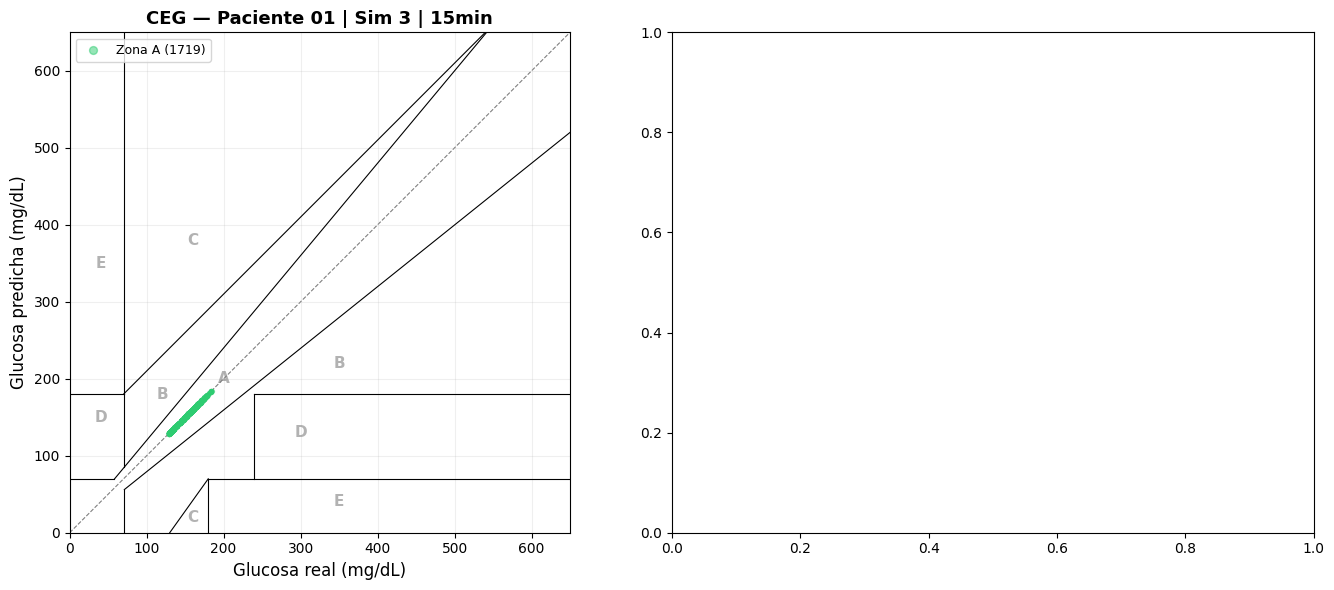

{'df_clarke':        real        pred zona
 0     153.0  152.956757    A
 1     152.0  151.999313    A
 2     151.0  150.992294    A
 3     150.0  149.995010    A
 4     149.0  148.945694    A
 ...     ...         ...  ...
 1714  160.0  160.004379    A
 1715  159.0  159.001358    A
 1716  159.0  158.989288    A
 1717  158.0  157.990204    A
 1718  157.0  156.994202    A
 
 [1719 rows x 3 columns],
 'resumen':   zona     n  porcentaje
 0    A  1719       100.0
 1    B     0         0.0
 2    C     0         0.0
 3    D     0         0.0
 4    E     0         0.0,
 'pct_A': 100.0,
 'pct_AB': 100.0,
 'pct_DE': 0.0}

In [ ]:
r_prueba = RESULTS_DIR / f"xgb_15min_p01_s3.pkl"
with open(r_prueba, "rb") as f:
    pa = pickle.load(f)

pa['predictions']
evaluar_clarke_backtesting(ref_y,pa['predictions'],'15min',1,3)

In [18]:
# ── Paso 4: Unir/Juntar resultados ────────────────────────────────────────
# Combina los resultados de la ejecución del paso anterior.

todos_resultados = []
for ruta in sorted(RESULTS_DIR.glob("xgb_*.pkl")):
    with open(ruta, "rb") as f:
        todos_resultados.append(pickle.load(f))
 
total_esperado = len(HORIZONTES) * N_PATIENTS * N_SIMS
print(f"Checkpoints cargados: {len(todos_resultados)} / {total_esperado}")
if len(todos_resultados) < total_esperado:
    print(f"⚠ Faltan {total_esperado - len(todos_resultados)} casos — resumen parcial")
 
COLS_METRICAS = [
    "modelo", "horizonte", "paciente", "simulacion",
    "MAE", "RMSE", "pct_A", "pct_AB", "pct_DE",
]
results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k in COLS_METRICAS}
    for r in todos_resultados
])
 
print("\n" + "=" * 60)
print("RESUMEN GLOBAL — Media ± Desv. Típica")
print("=" * 60)

print(
    results_df
    .groupby("horizonte")[["MAE", "RMSE", "pct_A", "pct_AB", "pct_DE"]]
    .agg(["mean", "std"]).round(4).to_string()
)
 
print("\n── Por paciente (media sobre simulaciones) ──")
print(
    results_df
    .groupby(["horizonte", "paciente"])[["MAE", "RMSE", "pct_AB", "pct_DE"]]
    .mean().round(4).to_string()
)
 
print("\n── Por simulación (media sobre pacientes) ──")
print(
    results_df
    .groupby(["horizonte", "simulacion"])[["MAE", "RMSE", "pct_AB", "pct_DE"]]
    .mean().round(4).to_string()
)
 
# Guarda los resultados globales en la carpata correspondiente 
results_df.to_csv(RESULTS_DIR / "xgboost_results.csv", index=False)
print(f"\n✓ Tabla guardada en {RESULTS_DIR / 'xgboost_results.csv'}")

Checkpoints cargados: 240 / 240

RESUMEN GLOBAL — Media ± Desv. Típica
              MAE            RMSE          pct_A      pct_AB      pct_DE     
             mean     std    mean     std   mean  std   mean  std   mean  std
horizonte                                                                    
15min      0.1608  0.0735  0.3527  0.1683  100.0  0.0  100.0  0.0    0.0  0.0
30min      0.1742  0.0870  0.4016  0.2429  100.0  0.0  100.0  0.0    0.0  0.0

── Por paciente (media sobre simulaciones) ──
                       MAE    RMSE  pct_AB  pct_DE
horizonte paciente                                
15min     0         0.1126  0.2673   100.0     0.0
          1         0.1124  0.2620   100.0     0.0
          2         0.2828  0.5198   100.0     0.0
          3         0.1945  0.4079   100.0     0.0
          4         0.2237  0.4732   100.0     0.0
          5         0.0719  0.2180   100.0     0.0
          6         0.1247  0.2681   100.0     0.0
          7         0.1200  0.266

#### Visuluación de reusltados (Opcional)

In [19]:
r_prueba = RESULTS_DIR / f"xgb_15min_p03_s3.pkl"
with open(r_prueba, "rb") as f:
    p = pickle.load(f)
print(p.keys())
for i in list(p.keys())[:-3]:
    print(i, ': ', p[i])
display(p['predictions'].head())
display(p['df_clarke'].head())
display(p['resumen_clarke'])
print(p['predictions'].shape)

dict_keys(['modelo', 'horizonte', 'paciente', 'simulacion', 'MAE', 'RMSE', 'pct_A', 'pct_AB', 'pct_DE', 'predictions', 'df_clarke', 'resumen_clarke'])
modelo :  XGBoost
horizonte :  15min
paciente :  3
simulacion :  3
MAE :  0.15830744221295084
RMSE :  0.3355132696625345
pct_A :  100.0
pct_AB :  100.0
pct_DE :  0.0


,fold,pred
2026-01-25 00:50:00,0,200.078171
2026-01-25 00:55:00,0,198.039963
2026-01-25 01:00:00,0,197.000824
2026-01-25 01:05:00,1,195.474167
2026-01-25 01:10:00,1,194.040024


,real,pred,zona
0,200.0,200.078171,A
1,198.0,198.039963,A
2,197.0,197.000824,A
3,195.0,195.474167,A
4,194.0,194.040024,A


,zona,n,porcentaje
0,A,1719,100.0
1,B,0,0.0
2,C,0,0.0
3,D,0,0.0
4,E,0,0.0


(1719, 2)


### ARIMAX

In [20]:
# ═══════════════════════════════════════════════════════════════════
# CONFIGURACIÓN
# ═══════════════════════════════════════════════════════════════════

# Periodo estacional en pasos de 5 min (referencias):
#   Ciclo diario  → s = 288  (24h × 12 lecturas/hora) — computacionalmente elevado
#   Ciclo horario → s = 12   (1h × 12 lecturas/hora)  — manejable como aproximación
SEASONAL_PERIOD = 12   # ciclo de 1 hora
 
# ═══════════════════════════════════════════════════════════════════
# FUNCIONES AUXILIARES ARIMAX
# ═══════════════════════════════════════════════════════════════════

def optimize_arimax(
    y_train: pd.Series,
    exog_train: pd.DataFrame,
    steps: int,
    incluir_estacionalidad: bool = False,
) -> dict:
    """
    Búsqueda de hiperparámetros ARIMAX mediante grid search.
 
    Sin estacionalidad → seasonal_order=(0,0,0,0) fijo, solo se busca (p,d,q).
    Con estacionalidad → además se busca sobre (P,D,Q,s) con s=SEASONAL_PERIOD.
 
    Parámetros
    ----------
    y_train : pd.Series
        Serie de glucosa del dataset de referencia.
    exog_train : pd.DataFrame
        Variables exógenas.
    steps : int
        Horizonte de predicción en pasos de 5 min.
    incluir_estacionalidad : bool
        Si True, incluye órdenes estacionales en el grid search. Por defecto, False.
 
    Retorna
    -------
    dict con los mejores hiperparámetros: order, seasonal_order y mae_busqueda.
    """
    cv_search = TimeSeriesFold(
        steps=steps,
        initial_train_size=int(len(y_train) * TRAIN_RATIO),
        refit=False,
        fixed_train_size=False,
        verbose=False,
    )
 
    orders_base = [
    # AR puro (q=0), sin diferenciación
    (1, 0, 0), (2, 0, 0), (3, 0, 0),
    # AR puro (q=0), con diferenciación
    (1, 1, 0), (2, 1, 0), (3, 1, 0),
    # MA puro (p=0), sin diferenciación
    (0, 0, 1), (0, 0, 2), (0, 0, 3),
    # MA puro (p=0), con diferenciación
    (0, 1, 1), (0, 1, 2), (0, 1, 3),
    # ARMA/ARIMA p=1
    (1, 0, 1), (1, 0, 2), (1, 0, 3),
    (1, 1, 1), (1, 1, 2), (1, 1, 3),
    # ARMA/ARIMA p=2
    (2, 0, 1), (2, 0, 2), (2, 0, 3),
    (2, 1, 1), (2, 1, 2), (2, 1, 3),
    # ARMA/ARIMA p=3
    (3, 0, 1), (3, 0, 2), (3, 0, 3),
    (3, 1, 1), (3, 1, 2), (3, 1, 3),
]
 
    if not incluir_estacionalidad:
        param_grid = {
            "order":          orders_base,
            "seasonal_order": [(0, 0, 0, 0)],
        }
        print(f"    Grid: {len(orders_base)} combinaciones ARIMA")
    else:
        seasonal_orders = [
            (1, 0, 0, SEASONAL_PERIOD),
            (0, 0, 1, SEASONAL_PERIOD),
            (1, 0, 1, SEASONAL_PERIOD),
            (1, 1, 0, SEASONAL_PERIOD),
            (0, 1, 1, SEASONAL_PERIOD),
            (1, 1, 1, SEASONAL_PERIOD),
        ]
        param_grid = {
            "order":          orders_base,
            "seasonal_order": seasonal_orders,
        }
        print(f"    Grid: {len(orders_base) * len(seasonal_orders)} combinaciones ARIMA × SARIMA (s={SEASONAL_PERIOD})")
 
    forecaster = ForecasterStats(
        estimator=Sarimax(order=(1, 1, 1), seasonal_order=(0, 0, 0, 0))
    )
 
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        results = grid_search_stats(
            forecaster=forecaster,
            y=y_train,
            exog=exog_train,
            cv=cv_search,
            param_grid=param_grid,
            metric="mean_absolute_error",
            return_best=True,
            n_jobs= -1,
            show_progress=True,
            suppress_warnings=True,
        )
 
    params = {
        "order":          results.iloc[0]["order"],
        "seasonal_order": results.iloc[0]["seasonal_order"],
        "mae_busqueda":   float(results.iloc[0]["mean_absolute_error"]),
    }

    print(f"  → orden ARIMA    : {params['order']}")
    print(f"  → seasonal_order : {params['seasonal_order']}")
    print(f"  → MAE búsqueda   : {params['mae_busqueda']:.4f} mg/dL")
    
    return params
 
def run_backtesting_arimax(
    y: pd.Series,
    exog: pd.DataFrame,
    steps: int,
    best_params: dict,
    train_ratio: float = TRAIN_RATIO,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Ejecuta el backtesting  para ARIMAX con ventana deslizante.
 
    Usa backtesting_stats (específica para ForecasterStats) con:
      - refit=True + fixed_train_size=True → ventana deslizante
      - freeze_params=True → orden (p,d,q) fijo, coeficientes AR/MA
        se reutilizan en cada fold sobre la nueva ventana de datos
      - seasonal_order=(0,0,0,0) siempre — sin componente estacional
 
    Parámetros
    ----------
    y : pd.Series
        Serie completa de glucosa.
    exog : pd.DataFrame
        Exógenas completas.
    steps : int
        Horizonte de predicción en pasos de 5 min.
    best_params : dict
        Parámetros ARIMA: {'order': (p,d,q)}. seasonal_order se fija
        internamente a (0,0,0,0).
    train_ratio : float
        Fracción de datos usada como ventana de entrenamiento inicial.
 
    Retorna
    -------
    metrics : pd.DataFrame
        MAE, MSE y RMSE del backtesting.
    predictions : pd.DataFrame
        Predicciones alineadas con el índice de y.
    """

    # División
    initial_train = int(len(y) * train_ratio)
 
    # Creación del predicotr
    forecaster = ForecasterStats(
        estimator=Sarimax(
            order=best_params["order"],
            seasonal_order=(0,0,0,0),
        )
    )
 
    # Preparación de validación cruzada
    cv = TimeSeriesFold(
        steps=steps,
        initial_train_size=initial_train,
        refit=True,
        fixed_train_size=True,
        allow_incomplete_fold=True,
        verbose=False,
    )
 
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        metrics, predictions = backtesting_stats(
            forecaster=forecaster,
            y=y,
            exog=exog,
            cv=cv,
            metric=["mean_absolute_error", "mean_squared_error"],
            freeze_params=True,
            show_progress= True,
            suppress_warnings=True,
            n_jobs= -1,
            verbose=False,
        )
 
    metrics["RMSE"] = np.sqrt(metrics["mean_squared_error"])
    return metrics, predictions

In [21]:
# ═══════════════════════════════════════════════════════════════════
# EJECUCIONES
# ═══════════════════════════════════════════════════════════════════
# ── Paso 1: Cargar y preparar todos los datos ───────────────────────────
# Hecho arriba en las celdas anteriores 

# ── Dataset de referencia ────────────────────────────────────────────
ref_df = datos[REFERENCE_SIM][f'p_{REFERENCE_PATIENT}']
ref_y, ref_exog = crear_features(ref_df)
 
ref_train_size = int(len(ref_y) * TRAIN_RATIO)
ref_y_train    = ref_y.iloc[:ref_train_size]
ref_exog_train = ref_exog.iloc[:ref_train_size]
 
 
# ── Paso 2: Optimización de hiperparámetros ───────────────────────────
 
print("\n" + "=" * 60)
print("OPTIMIZACIÓN DE HIPERPARÁMETROS sin estacionalidad")
print("=" * 60)
 
best_params = {}
for horizon_name, steps in HORIZONTES.items():
    print(f"\n── Horizonte: {horizon_name} ({steps} pasos) ──")
 
    print("\nSin estacionalidad")
    best_params[horizon_name] = optimize_arimax(
        y_train=ref_y_train,
        exog_train=ref_exog_train,
        steps=steps,
        incluir_estacionalidad=False,
    ) 
print("\nMejores órdenes ARIMA por horizonte:")
for horizon_name, params in best_params.items():
    print(f"  {horizon_name}: ARIMA{params['order']} | MAE búsqueda: {params['mae_busqueda']:.4f} mg/dL")

# Sobreescribe el pickle siempre — si se vuelve a ejecutar esta
# sección, los hiperparámetros anteriores quedan reemplazados
with open(BEST_PARAMS_A_PATH, "wb") as f:
    pickle.dump(best_params, f, protocol=pickle.HIGHEST_PROTOCOL)
 
print(f"✓ Hiperparámetros guardados en {BEST_PARAMS_A_PATH}")


OPTIMIZACIÓN DE HIPERPARÁMETROS sin estacionalidad

── Horizonte: 15min (3 pasos) ──

Sin estacionalidad
    Grid: 30 combinaciones ARIMA


params grid:   0%|          | 0/30 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [22]:
# ── Paso 3: Backtesting en los 120 datasets ──────────────────────────────

# ── PARÁMETRO A CAMBIAR EN CADA EJECUCIÓN ────────────────────────────
SIM_ID_ACTUAL_A = 1   # ← Cambiar a 1, 2, 3, 4, 5 o 6
 
# Cargar hiperparámetros desde disco
with open(BEST_PARAMS_A_PATH, "rb") as f:
    best_params = pickle.load(f)
print(f"✓ Hiperparámetros cargados desde {BEST_PARAMS_A_PATH}")
 
print("\n" + "=" * 60)
print("BACKTESTING ARIMAX")
print("=" * 60)
 
ya_hechos = [
    (h, p)
    for h in HORIZONTES
    for p in range(N_PATIENTS)
    if (RESULTS_DIR_A / f"arima_{h}_p{p:02d}_s{SIM_ID_ACTUAL_A}.pkl").exists()
]

pendientes = len(HORIZONTES) * N_PATIENTS - len(ya_hechos)
print(f"Simulación {SIM_ID_ACTUAL_A}: {len(ya_hechos)} ya procesados | {pendientes} pendientes\n")

for horizon_name, steps in HORIZONTES.items():
    print(f"── Horizonte: {horizon_name} — ARIMA{best_params[horizon_name]['order']} ──")
    params = best_params[horizon_name]
 
    for patient_id in range(N_PATIENTS):
 
        ruta_pkl = RESULTS_DIR_A / f"arima_{horizon_name}_p{patient_id:02d}_s{SIM_ID_ACTUAL_A}.pkl"
 
        # Saltar si ya está procesado
        if ruta_pkl.exists():
            print(f"  [SKIP] Paciente {patient_id:02d} — ya procesado")
            continue
 
        print(f"  [RUN]  Paciente {patient_id:02d}...", end=" ", flush=True)
 
        try:
            df      = datos[SIM_ID_ACTUAL_A][f'p_{patient_id}']
            y, exog = crear_features(df)
 
            metrics, predictions = run_backtesting_arimax(
                y=y, exog=exog, steps=steps, best_params=params,train_ratio=TRAIN_RATIO
            )
 
            mae  = metrics["mean_absolute_error"].values[0]
            rmse = metrics["RMSE"].values[0]
 
            y_test    = y.loc[predictions.index]
            df_clarke = clarke_error_grid(y_test.values, predictions["pred"].values)
            resumen   = resumen_clarke(df_clarke)
 
            pct_A  = float(resumen.loc[resumen["zona"] == "A",          "porcentaje"].values[0])
            pct_AB = float(resumen.loc[resumen["zona"].isin(["A","B"]), "porcentaje"].sum())
            pct_DE = float(resumen.loc[resumen["zona"].isin(["D","E"]), "porcentaje"].sum())
 
            resultado = {
                "modelo":         "ARIMAX",
                "horizonte":      horizon_name,
                "paciente":       patient_id,
                "simulacion":     SIM_ID_ACTUAL_A,
                "MAE":            mae,
                "RMSE":           rmse,
                "pct_A":          pct_A,
                "pct_AB":         pct_AB,
                "pct_DE":         pct_DE,
                "predictions":    predictions,
                "df_clarke":      df_clarke,
                "resumen_clarke": resumen,
            }
 
            ruta_tmp = ruta_pkl.with_suffix(".tmp")
            with open(ruta_tmp, "wb") as f:
                pickle.dump(resultado, f, protocol=pickle.HIGHEST_PROTOCOL)
            ruta_tmp.rename(ruta_pkl)
 
            print(
                f"MAE={mae:.4f} mg/dL | RMSE={rmse:.4f} mg/dL | "
                f"A={pct_A:.1f}% | A+B={pct_AB:.1f}% | D+E={pct_DE:.1f}%"
            )
 
        except Exception as e:
            print(f"ERROR: {e}")
            warnings.warn(f"Fallo en p{patient_id:02d}_s{SIM_ID_ACTUAL_A}_{horizon_name}: {e}")
 
print(f"\n✓ Simulación {SIM_ID_ACTUAL_A} completada")

✓ Hiperparámetros cargados desde Resultados\ARIMA_resultados\best_params.pkl

BACKTESTING ARIMAX
Simulación 1: 40 ya procesados | 0 pendientes

── Horizonte: 15min — ARIMA(2, 0, 3) ──
  [SKIP] Paciente 00 — ya procesado
  [SKIP] Paciente 01 — ya procesado
  [SKIP] Paciente 02 — ya procesado
  [SKIP] Paciente 03 — ya procesado
  [SKIP] Paciente 04 — ya procesado
  [SKIP] Paciente 05 — ya procesado
  [SKIP] Paciente 06 — ya procesado
  [SKIP] Paciente 07 — ya procesado
  [SKIP] Paciente 08 — ya procesado
  [SKIP] Paciente 09 — ya procesado
  [SKIP] Paciente 10 — ya procesado
  [SKIP] Paciente 11 — ya procesado
  [SKIP] Paciente 12 — ya procesado
  [SKIP] Paciente 13 — ya procesado
  [SKIP] Paciente 14 — ya procesado
  [SKIP] Paciente 15 — ya procesado
  [SKIP] Paciente 16 — ya procesado
  [SKIP] Paciente 17 — ya procesado
  [SKIP] Paciente 18 — ya procesado
  [SKIP] Paciente 19 — ya procesado
── Horizonte: 30min — ARIMA(2, 0, 3) ──
  [SKIP] Paciente 00 — ya procesado
  [SKIP] Paciente 01

In [23]:
# ── Paso 4: Unión de resultados ──────────────────────────────
todos_resultados = []
for ruta in sorted(RESULTS_DIR_A.glob("arima_*.pkl")):
    with open(ruta, "rb") as f:
        todos_resultados.append(pickle.load(f))
 
total_esperado = len(HORIZONTES) * N_PATIENTS * N_SIMS
print(f"Checkpoints cargados: {len(todos_resultados)} / {total_esperado}")
if len(todos_resultados) < total_esperado:
    print(f"⚠ Faltan {total_esperado - len(todos_resultados)} casos — resumen parcial")
 
COLS_METRICAS = [
    "modelo", "horizonte", "paciente", "simulacion",
    "MAE", "RMSE", "pct_A", "pct_AB", "pct_DE",
]
results_ar_df = pd.DataFrame([
    {k: v for k, v in r.items() if k in COLS_METRICAS}
    for r in todos_resultados
])
 
print("\n" + "=" * 60)
print("RESUMEN GLOBAL — Media ± Desv. Típica")
print("=" * 60)
print(
    results_ar_df
    .groupby("horizonte")[["MAE", "RMSE", "pct_A", "pct_AB", "pct_DE"]]
    .agg(["mean", "std"]).round(4).to_string()
)
 
print("\n── Por paciente (media sobre simulaciones) ──")
print(
    results_ar_df
    .groupby(["horizonte", "paciente"])[["MAE", "RMSE", "pct_AB", "pct_DE"]]
    .mean().round(4).to_string()
)
 
print("\n── Por simulación (media sobre pacientes) ──")
print(
    results_ar_df
    .groupby(["horizonte", "simulacion"])[["MAE", "RMSE", "pct_AB", "pct_DE"]]
    .mean().round(4).to_string()
)
 
results_ar_df.to_csv(RESULTS_DIR_A / "arimax_results.csv", index=False)
print(f"\n✓ Tabla guardada en {RESULTS_DIR_A / 'arimax_results.csv'}")


Checkpoints cargados: 240 / 240

RESUMEN GLOBAL — Media ± Desv. Típica
              MAE            RMSE          pct_A      pct_AB      pct_DE     
             mean     std    mean     std   mean  std   mean  std   mean  std
horizonte                                                                    
15min      0.2493  0.0053  0.2942  0.0377  100.0  0.0  100.0  0.0    0.0  0.0
30min      0.2501  0.0062  0.2950  0.0506  100.0  0.0  100.0  0.0    0.0  0.0

── Por paciente (media sobre simulaciones) ──
                       MAE    RMSE  pct_AB  pct_DE
horizonte paciente                                
15min     0         0.2446  0.2862   100.0     0.0
          1         0.2492  0.3038   100.0     0.0
          2         0.2516  0.2903   100.0     0.0
          3         0.2478  0.2880   100.0     0.0
          4         0.2505  0.2943   100.0     0.0
          5         0.2456  0.2885   100.0     0.0
          6         0.2490  0.2882   100.0     0.0
          7         0.2521  0.291

#### Visuluación de resultados (Opcional)

In [24]:
r_prueba = RESULTS_DIR_A / f"arima_15min_p03_s3.pkl"
with open(r_prueba, "rb") as f:
    p = pickle.load(f)
print(p.keys())
for i in list(p.keys())[:-3]:
    print(i, ': ', p[i])
display(p['predictions'].head())
display(p['df_clarke'].head())
display(p['resumen_clarke'])
print(p['predictions'].shape)

dict_keys(['modelo', 'horizonte', 'paciente', 'simulacion', 'MAE', 'RMSE', 'pct_A', 'pct_AB', 'pct_DE', 'predictions', 'df_clarke', 'resumen_clarke'])
modelo :  ARIMAX
horizonte :  15min
paciente :  3
simulacion :  3
MAE :  0.24451790746797036
RMSE :  0.28551234661885144
pct_A :  100.0
pct_AB :  100.0
pct_DE :  0.0


,fold,pred
2026-01-25 00:50:00,0,199.658054
2026-01-25 00:55:00,0,198.194721
2026-01-25 01:00:00,0,196.730244
2026-01-25 01:05:00,1,195.373940
2026-01-25 01:10:00,1,193.969451


,real,pred,zona
0,200.0,199.658054,A
1,198.0,198.194721,A
2,197.0,196.730244,A
3,195.0,195.373940,A
4,194.0,193.969451,A


,zona,n,porcentaje
0,A,1719,100.0
1,B,0,0.0
2,C,0,0.0
3,D,0,0.0
4,E,0,0.0


(1719, 2)


## Evaluación de resultados

### Unión y comparativa de resultados
Comparativa inicial

In [9]:
# ── Comparativa ARIMAX vs XGBoost ──────────────────────
xgboost_df = pd.read_csv(RESULTS_DIR / "xgboost_results.csv")
arima_df = pd.read_csv(RESULTS_DIR_A / 'arimax_results.csv')
resultados = pd.concat([arima_df, xgboost_df])
display(resultados.head(3))
display(resultados.groupby(["modelo", "horizonte"])[["MAE", "RMSE"]].agg(["mean", "std"]).round(4))

,modelo,horizonte,paciente,simulacion,MAE,RMSE,pct_A,pct_AB,pct_DE
0,ARIMAX,15min,0,1,0.240970,0.282878,100.0,100.0,0.0
1,ARIMAX,15min,0,2,0.257226,0.297543,100.0,100.0,0.0
2,ARIMAX,15min,0,3,0.238049,0.279518,100.0,100.0,0.0


MAE            RMSE        
                     mean     std    mean     std
modelo  horizonte                                
ARIMAX  15min      0.2493  0.0053  0.2942  0.0377
        30min      0.2501  0.0062  0.2950  0.0506
XGBoost 15min      0.1608  0.0735  0.3527  0.1683
        30min      0.1742  0.0870  0.4016  0.2429

In [10]:
resultados.to_csv("Resultados/resultados_modelos.csv", index=False)

### Estadísticas TIR
#### Obtención del tiempo en rango de cada paciente para posterior análisis.

In [11]:
# Ejemplo de funcionamiento sobre datos de un paciente.
estadisticas_rango(datos[1]['p_2'])

{'TIR': [28.33], 'TAR': [71.67], 'TBR': [0.0]}

#### Dataframe con rangos de todas las simulaciones y pacientes

In [12]:
estadisticas = pd.DataFrame(columns=['Simulacion','Paciente', 'TBR', 'TIR', 'TAR'])
for simu in range(1,7):
    for p in range(20):
        est_l = estadisticas_rango(datos[simu][f'p_{p}'])
        est_l.update({'Simulacion': [simu], 'Paciente': [p]})
        df_l = pd.DataFrame(est_l)
        estadisticas = pd.concat([estadisticas, df_l])
display(estadisticas.head(20))

# Guardado en csv para futuros usos
estadisticas.to_csv('Resultados/TIR.csv',index=False)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_19016\4137982581.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  estadisticas = pd.concat([estadisticas, df_l])


,Simulacion,Paciente,TBR,TIR,TAR
0,1,0,0.0,83.88,16.12
0,1,1,0.0,98.84,1.16
0,1,2,0.0,28.33,71.67
0,1,3,0.0,25.56,74.44
0,1,4,0.0,1.65,98.35
0,1,5,0.0,100.00,0.00
0,1,6,0.0,92.22,7.78
0,1,7,0.0,99.97,0.03
0,1,8,0.0,3.47,96.53
0,1,9,0.0,1.96,98.04


#### Tablas rangos por paciente

In [13]:
for i in range(20):
    display(estadisticas[estadisticas['Paciente']==i])

,Simulacion,Paciente,TBR,TIR,TAR
0,1,0,0.0,83.88,16.12
0,2,0,0.0,82.73,17.27
0,3,0,0.0,95.68,4.32
0,4,0,0.0,79.37,20.63
0,5,0,0.0,84.69,15.31
0,6,0,0.0,87.12,12.88


,Simulacion,Paciente,TBR,TIR,TAR
0,1,1,0.0,98.84,1.16
0,2,1,0.0,98.43,1.57
0,3,1,0.0,99.57,0.43
0,4,1,0.0,93.59,6.41
0,5,1,0.0,98.18,1.82
0,6,1,0.0,98.09,1.91


,Simulacion,Paciente,TBR,TIR,TAR
0,1,2,0.0,28.33,71.67
0,2,2,0.0,29.02,70.98
0,3,2,0.0,29.51,70.49
0,4,2,0.0,30.20,69.80
0,5,2,0.0,27.14,72.86
0,6,2,0.0,29.59,70.41


,Simulacion,Paciente,TBR,TIR,TAR
0,1,3,0.0,25.56,74.44
0,2,3,0.0,22.05,77.95
0,3,3,0.0,30.53,69.47
0,4,3,0.0,14.76,85.24
0,5,3,0.0,17.79,82.21
0,6,3,0.0,24.51,75.49


,Simulacion,Paciente,TBR,TIR,TAR
0,1,4,0.0,1.65,98.35
0,2,4,0.0,2.25,97.75
0,3,4,0.0,2.19,97.81
0,4,4,0.0,6.80,93.20
0,5,4,0.0,4.71,95.29
0,6,4,0.0,4.96,95.04


...

,Simulacion,Paciente,TBR,TIR,TAR
0,1,15,0.0,2.05,97.95
0,2,15,0.0,2.56,97.44
0,3,15,0.0,2.45,97.55
0,4,15,0.0,3.62,96.38
0,5,15,0.0,3.17,96.83
0,6,15,0.0,3.78,96.22


,Simulacion,Paciente,TBR,TIR,TAR
0,1,16,0.0,11.27,88.73
0,2,16,0.0,11.58,88.42
0,3,16,0.0,16.62,83.38
0,4,16,0.0,11.80,88.20
0,5,16,0.0,10.99,89.01
0,6,16,0.0,13.34,86.66


,Simulacion,Paciente,TBR,TIR,TAR
0,1,17,0.0,75.86,24.14
0,2,17,0.0,73.75,26.25
0,3,17,0.0,77.31,22.69
0,4,17,0.0,68.90,31.10
0,5,17,0.0,71.57,28.43
0,6,17,0.0,74.70,25.30


,Simulacion,Paciente,TBR,TIR,TAR
0,1,18,0.0,92.34,7.66
0,2,18,0.0,91.11,8.89
0,3,18,0.0,92.88,7.12
0,4,18,0.0,90.17,9.83
0,5,18,0.0,89.26,10.74
0,6,18,0.0,89.80,10.20


,Simulacion,Paciente,TBR,TIR,TAR
0,1,19,0.0,22.82,77.18
0,2,19,0.0,22.88,77.12
0,3,19,0.0,39.58,60.42
0,4,19,0.0,25.87,74.13
0,5,19,0.0,24.04,75.96
0,6,19,0.0,35.04,64.96


#### Creación de gráficas de barras apiladas por simulación

In [14]:
FIGS_DIR = Path("Resultados/figs/TIR")
FIGS_DIR.mkdir(parents=True, exist_ok=True)

for s in range(1, N_SIMS+1):
    # 1. Selección de datos
    rang_sim = estadisticas[estadisticas['Simulacion']==s]
    ax = rang_sim.set_index('Paciente')[['TBR', 'TIR', 'TAR']].sort_index().plot(kind='bar', 
                                                    figsize=(14, 7),
                                                    stacked=True, 
                                                    width=.7, 
                                                    color=["#ff0000", "#0bbb01", "#df7300"])

    # 2. Personalización estética
    plt.title(f'Tiempo en rango - Simulación {s}', fontsize=16, fontweight='bold')
    plt.xlabel('ID de Paciente', fontsize=12)
    plt.ylabel('Porcentaje (%)', fontsize=12)
    plt.xticks(rotation=0)
    plt.yticks(np.arange(0,101,10))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title='',bbox_to_anchor=(1.0, 1), loc='upper left')

    # 3. Guardado
    plt.savefig(FIGS_DIR / f'rangos_s{s}.png', dpi=130, bbox_inches='tight')
    plt.close()

### Test de Normalidad
Comprobación de la normalidad de los datos, para la realización test estadísticos.

**Normalidad TIR**
No sigue distribución normal

In [13]:
for s in range(1,N_SIMS+1):
    normalidad(s=s,datos = estadisticas[estadisticas['Simulacion']==s]['TIR'], nombre='TIR')

Simulación 1: test:0.84  p_valor:0.004
	 H0 rechazada: TIR NO es normal
Simulación 2: test:0.85  p_valor:0.0055
	 H0 rechazada: TIR NO es normal
Simulación 3: test:0.85  p_valor:0.0052
	 H0 rechazada: TIR NO es normal
Simulación 4: test:0.87  p_valor:0.0116
	 H0 rechazada: TIR NO es normal
Simulación 5: test:0.86  p_valor:0.0069
	 H0 rechazada: TIR NO es normal
Simulación 6: test:0.86  p_valor:0.0079
	 H0 rechazada: TIR NO es normal


**Normalidad MAE**
No todos las errores para las simulaciones son normales

In [14]:
for s in range(1,N_SIMS+1):
    normalidad(s=s,datos= arima_df[(arima_df['simulacion'] ==s) &  (arima_df['horizonte']=='15min')]['MAE'],nombre='MAE arimax 15 min')
print('')
for s in range(1,N_SIMS+1):
    normalidad(s=s,datos= arima_df[(arima_df['simulacion'] ==s) &  (arima_df['horizonte']=='30min')]['MAE'],nombre='MAE arimax 30 min')
print('')
for s in range(1,N_SIMS+1):
    normalidad(s=s,datos= xgboost_df[(xgboost_df['simulacion'] ==s) &  (xgboost_df['horizonte']=='15min')]['MAE'],nombre='MAE xgboost 15 min')
print('')
for s in range(1,N_SIMS+1):
    normalidad(s=s,datos= xgboost_df[(xgboost_df['simulacion'] == s) &  (xgboost_df['horizonte']=='30min')]['MAE'],nombre='MAE xgboost 30 min')

Simulación 1: test:0.96  p_valor:0.6021
	 H0 aceptada: MAE arimax 15 min SÍ es normal
Simulación 2: test:0.97  p_valor:0.7883
	 H0 aceptada: MAE arimax 15 min SÍ es normal
Simulación 3: test:0.97  p_valor:0.8363
	 H0 aceptada: MAE arimax 15 min SÍ es normal
Simulación 4: test:0.96  p_valor:0.5835
	 H0 aceptada: MAE arimax 15 min SÍ es normal
Simulación 5: test:0.81  p_valor:0.001
	 H0 rechazada: MAE arimax 15 min NO es normal
Simulación 6: test:0.95  p_valor:0.3282
	 H0 aceptada: MAE arimax 15 min SÍ es normal

Simulación 1: test:0.94  p_valor:0.2084
	 H0 aceptada: MAE arimax 30 min SÍ es normal
Simulación 2: test:0.97  p_valor:0.6923
	 H0 aceptada: MAE arimax 30 min SÍ es normal
Simulación 3: test:0.99  p_valor:0.9967
	 H0 aceptada: MAE arimax 30 min SÍ es normal
Simulación 4: test:0.95  p_valor:0.4331
	 H0 aceptada: MAE arimax 30 min SÍ es normal
Simulación 5: test:0.6  p_valor:0.0
	 H0 rechazada: MAE arimax 30 min NO es normal
Simulación 6: test:0.94  p_valor:0.2948
	 H0 aceptada: M

**Normalidad RMSE**
No todos las errores para las simulaciones son normales

In [15]:
for s in range(1,N_SIMS+1):
    normalidad(s=s,datos= arima_df[(arima_df['simulacion'] ==s) &  (arima_df['horizonte']=='15min')]['RMSE'],nombre='RMSE arimax 15 min')
print('')
for s in range(1,N_SIMS+1):
    normalidad(s=s,datos= arima_df[(arima_df['simulacion'] ==s) &  (arima_df['horizonte']=='30min')]['RMSE'],nombre='RMSE arimax 30 min')
print('')
for s in range(1,N_SIMS+1):
    normalidad(s=s,datos= xgboost_df[(xgboost_df['simulacion'] ==s) &  (xgboost_df['horizonte']=='15min')]['RMSE'],nombre='RMSE xgboost 15 min')
print('')
for s in range(1,N_SIMS+1):
    normalidad(s=s,datos= xgboost_df[(xgboost_df['simulacion'] == s) &  (xgboost_df['horizonte']=='30min')]['RMSE'],nombre='RMSE xgboost 30 min')


Simulación 1: test:0.68  p_valor:0.0
	 H0 rechazada: RMSE arimax 15 min NO es normal
Simulación 2: test:0.97  p_valor:0.7102
	 H0 aceptada: RMSE arimax 15 min SÍ es normal
Simulación 3: test:0.43  p_valor:0.0
	 H0 rechazada: RMSE arimax 15 min NO es normal
Simulación 4: test:0.95  p_valor:0.4169
	 H0 aceptada: RMSE arimax 15 min SÍ es normal
Simulación 5: test:0.28  p_valor:0.0
	 H0 rechazada: RMSE arimax 15 min NO es normal
Simulación 6: test:0.6  p_valor:0.0
	 H0 rechazada: RMSE arimax 15 min NO es normal

Simulación 1: test:0.9  p_valor:0.043
	 H0 rechazada: RMSE arimax 30 min NO es normal
Simulación 2: test:0.96  p_valor:0.5898
	 H0 aceptada: RMSE arimax 30 min SÍ es normal
Simulación 3: test:0.32  p_valor:0.0
	 H0 rechazada: RMSE arimax 30 min NO es normal
Simulación 4: test:0.95  p_valor:0.3047
	 H0 aceptada: RMSE arimax 30 min SÍ es normal
Simulación 5: test:0.26  p_valor:0.0
	 H0 rechazada: RMSE arimax 30 min NO es normal
Simulación 6: test:0.56  p_valor:0.0
	 H0 rechazada: RMS

### Gráficas

In [ ]:
"""
Visualización de resultados: XGBoost vs ARIMAX — predicción de glucosa
Versión 2 — etiquetas de simulación corregidas

Simulaciones:
    E1: HC poco variables · Sin ejercicio · 0% error insulina
    E2: HC variables      · Sin ejercicio · 0% error insulina
    E3: HC poco variables · Con ejercicio · 0% error insulina
    E4: HC poco variables · Sin ejercicio · 10% error insulina
    E5: HC variables      · Sin ejercicio · 10% error insulina
    E6: HC poco variables · Con ejercicio · 10% error insulina

Comparaciones factoriales:
    Efecto HC:       E1 vs E2  |  E4 vs E5
    Efecto ejercicio: E1 vs E3  |  E4 vs E6
    Efecto error:    E1 vs E4  |  E2 vs E5  |  E3 vs E6

DataFrames de entrada:
    df_res — columnas: modelo, horizonte, paciente, simulacion, MAE, RMSE, pct_A, pct_AB, pct_DE
    df_tir — columnas: Simulacion, Paciente, TBR, TIR, TAR
"""

# ── Configuración  ──────────────────────────────────────────────────────

plt.rcParams.update({
    "font.family":      "sans-serif",
    "font.size":        10,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "grid.linestyle":   "--",
    "figure.dpi":       200,
})

Todas las gráficas generadas.


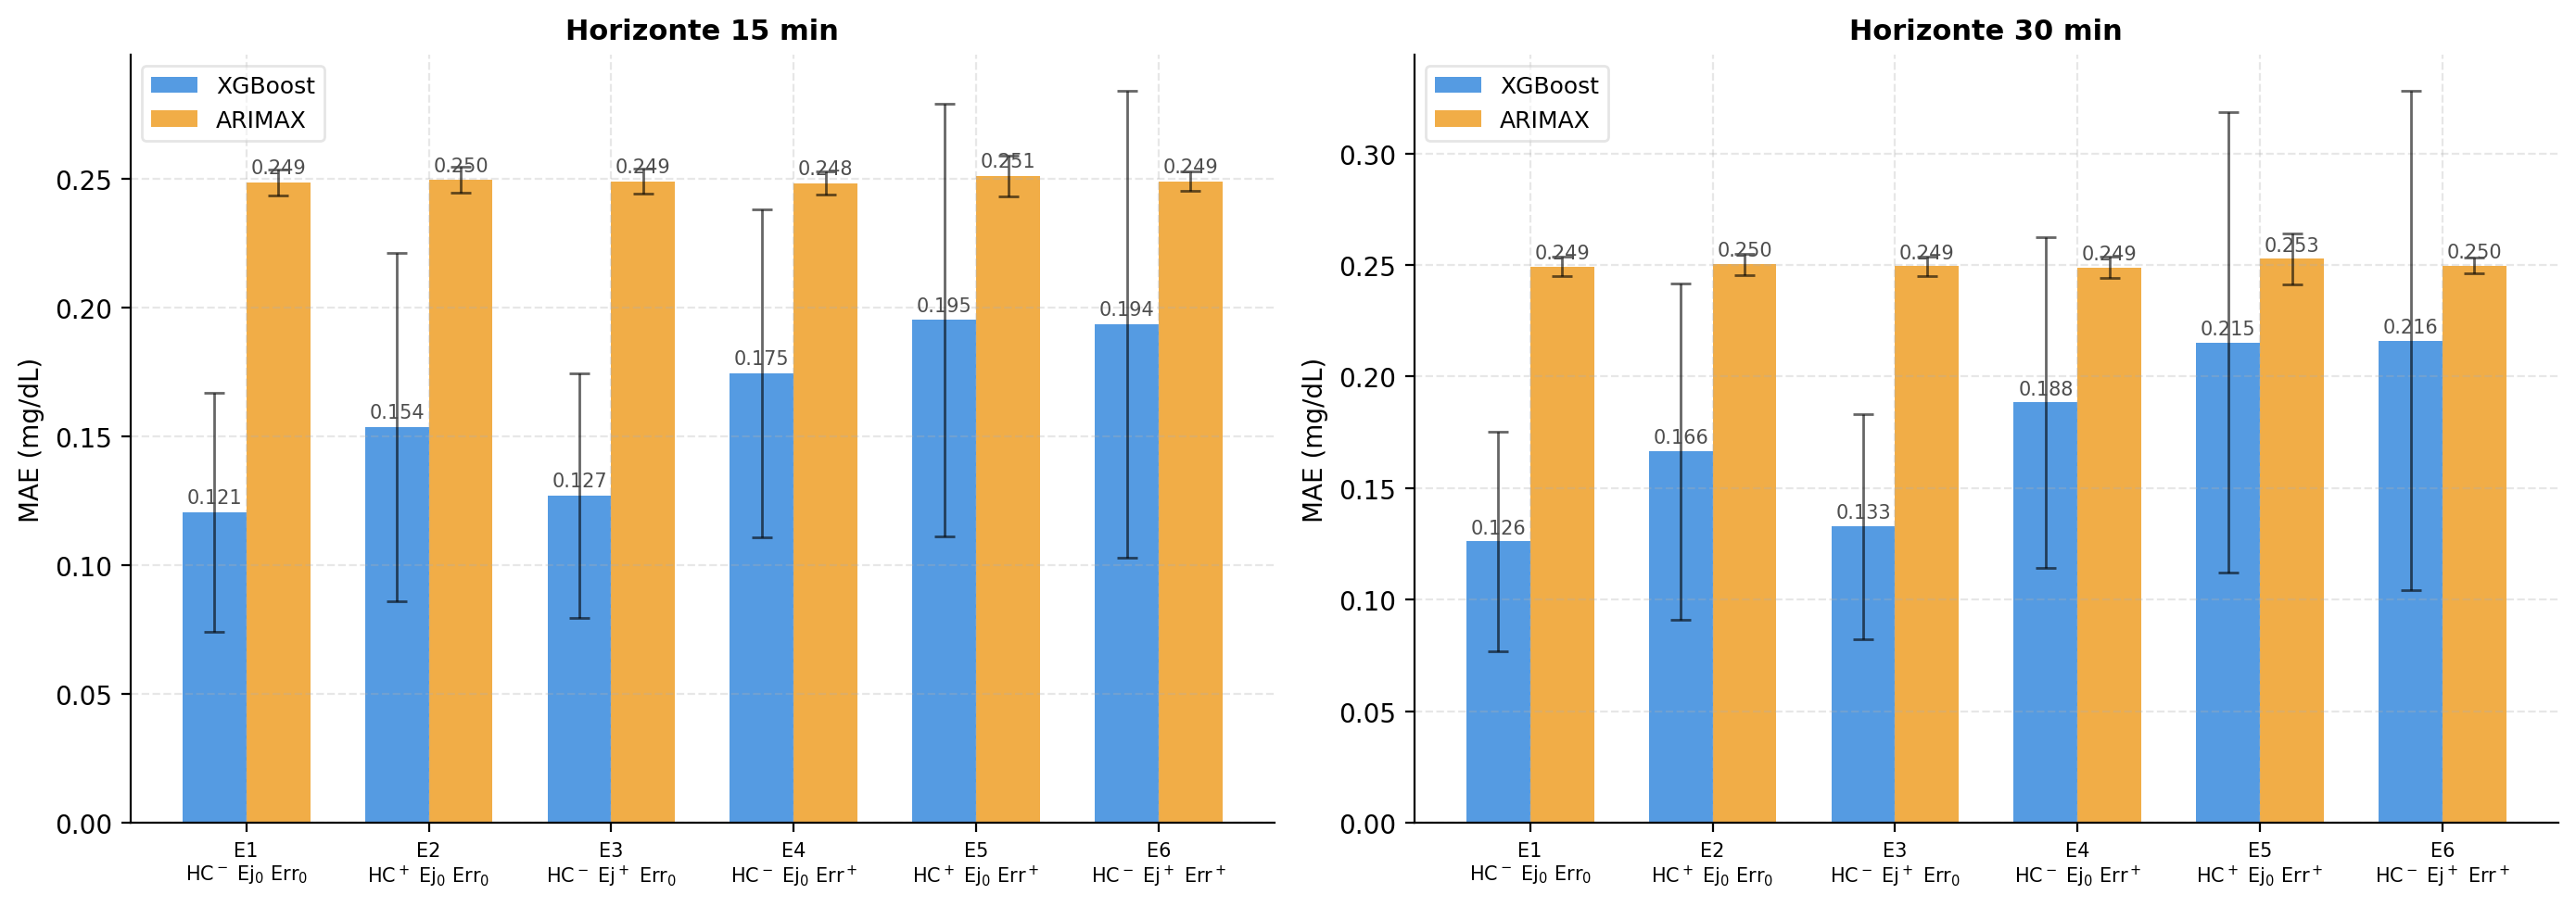

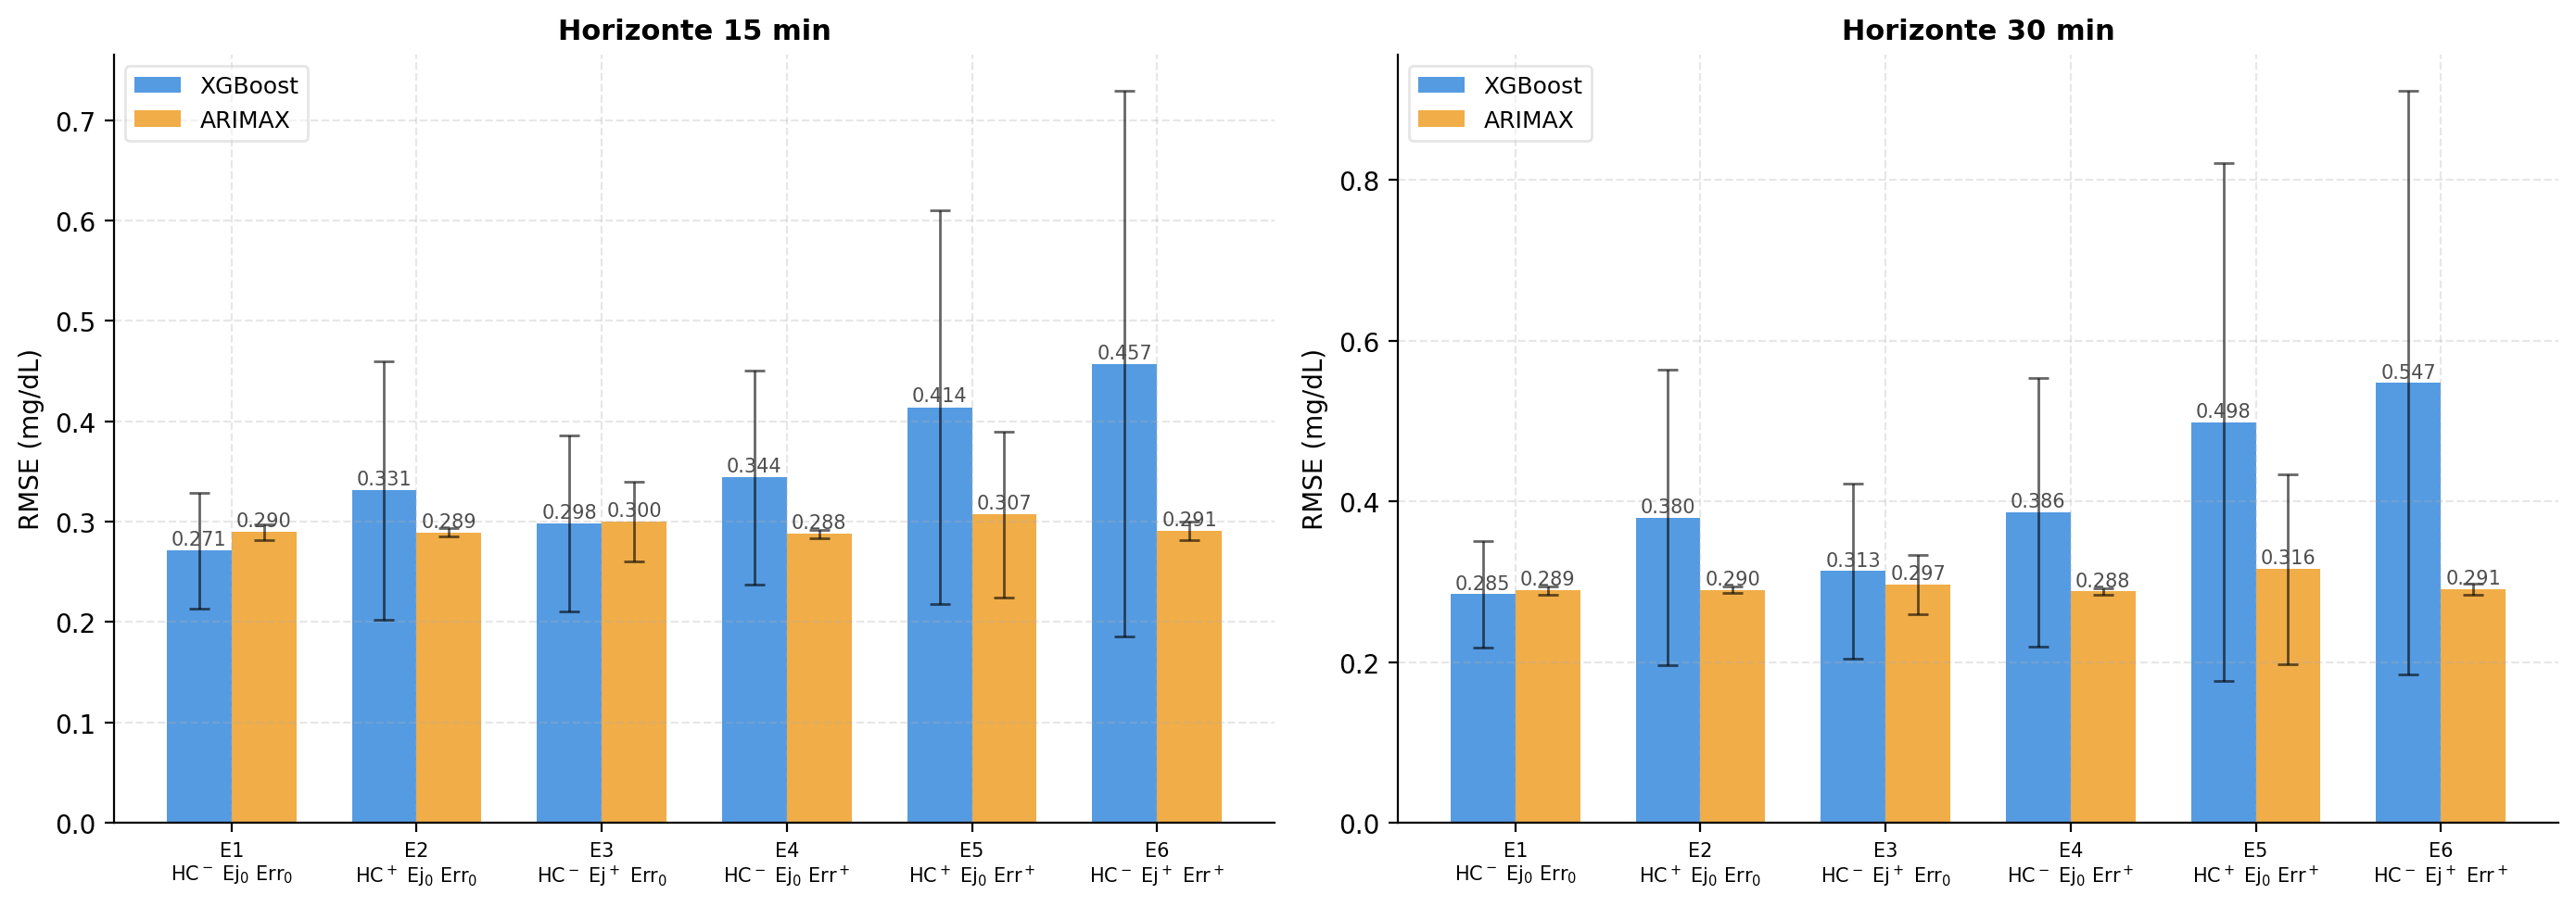

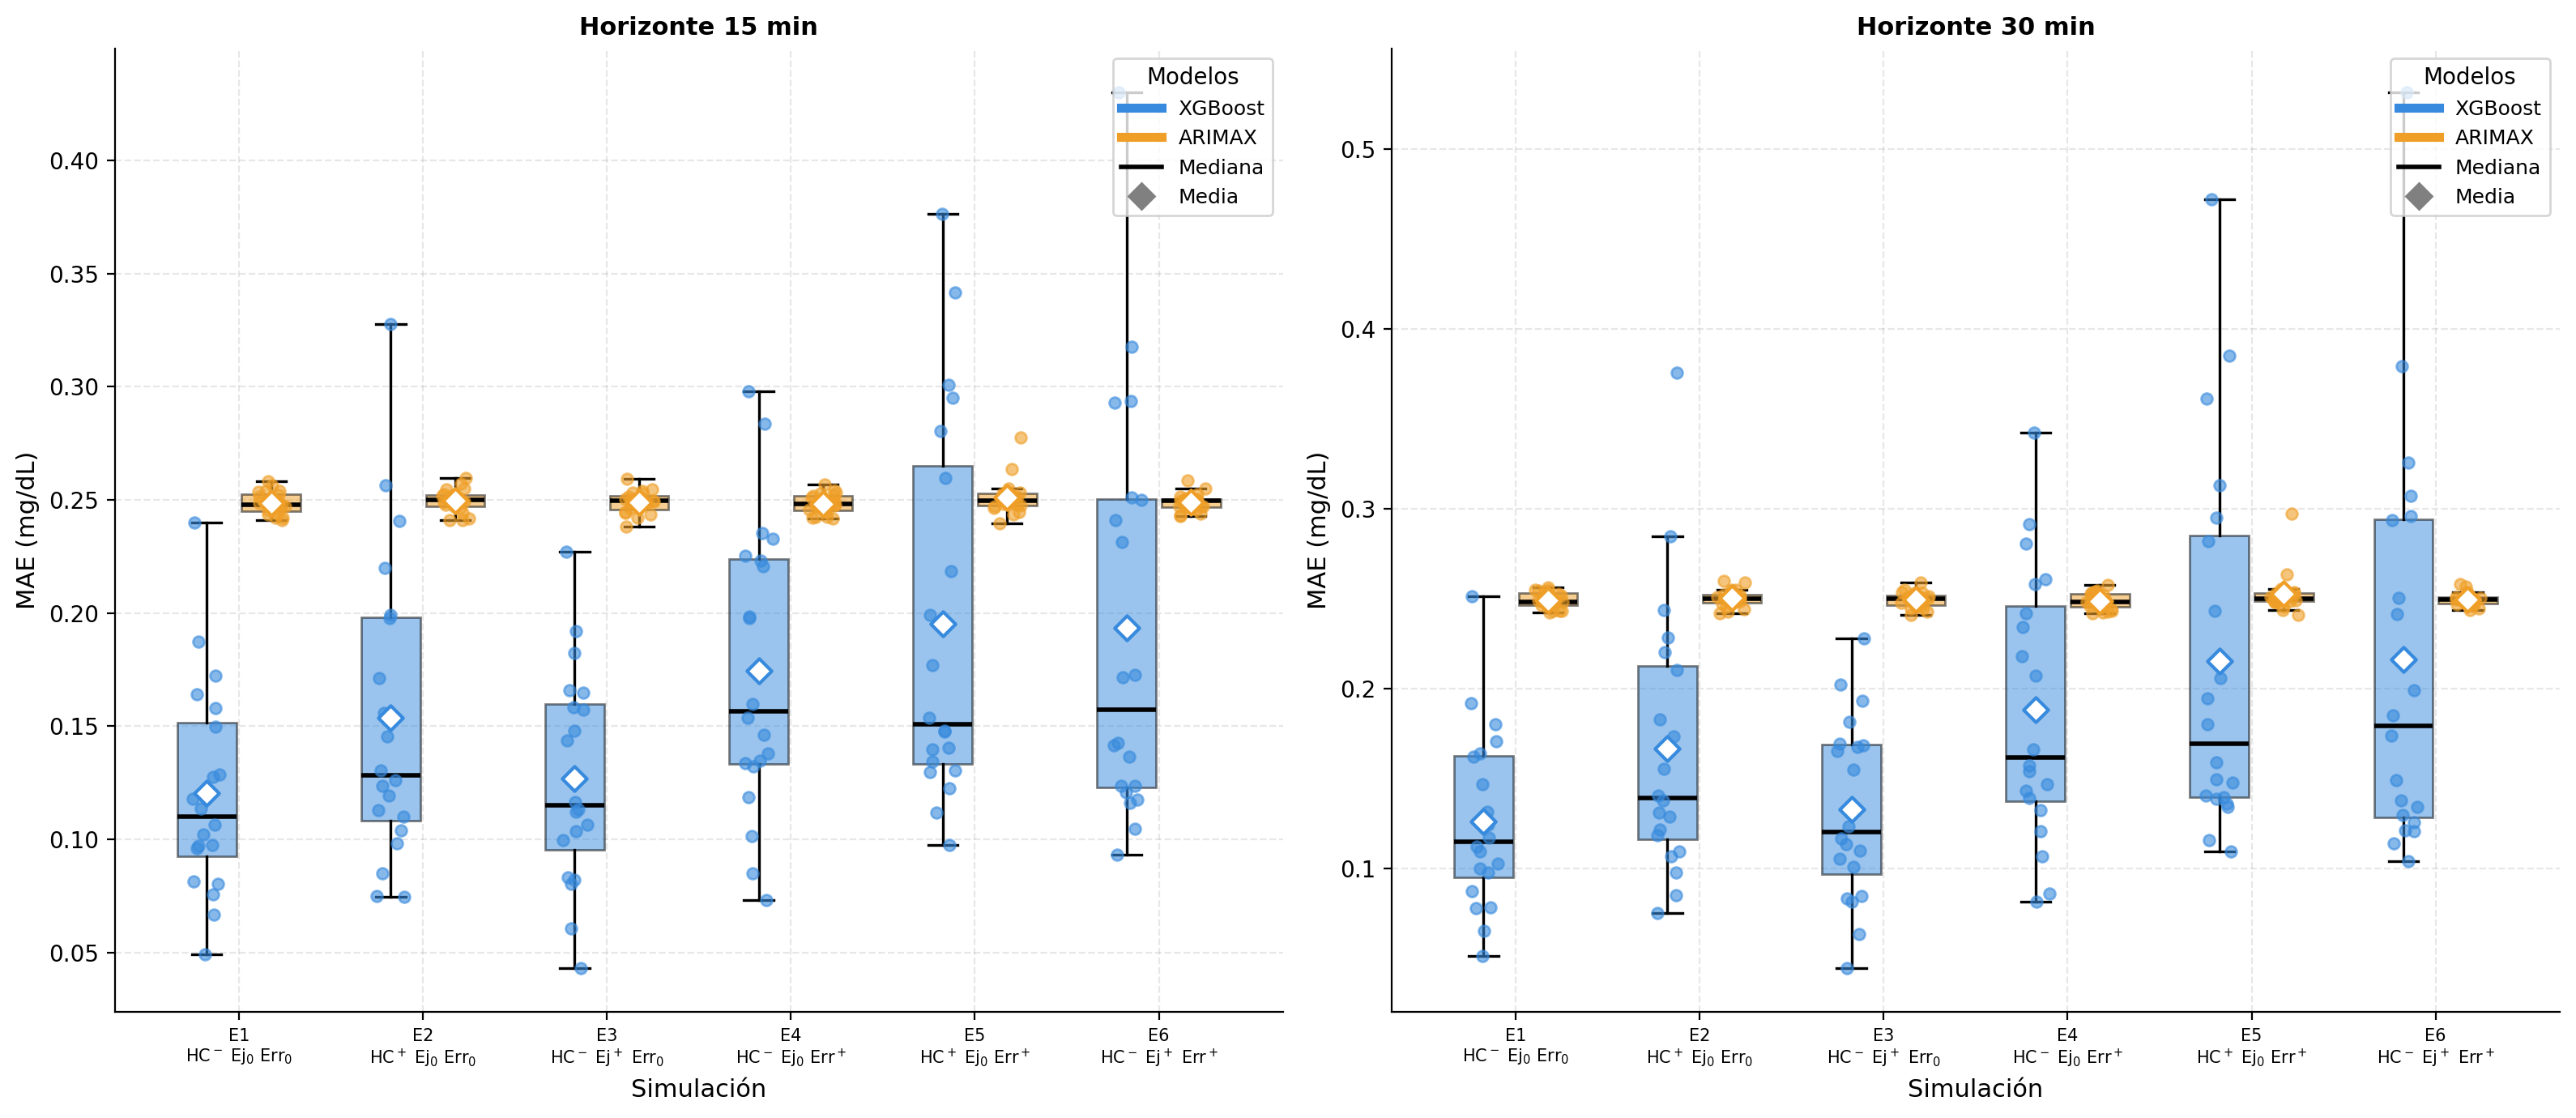

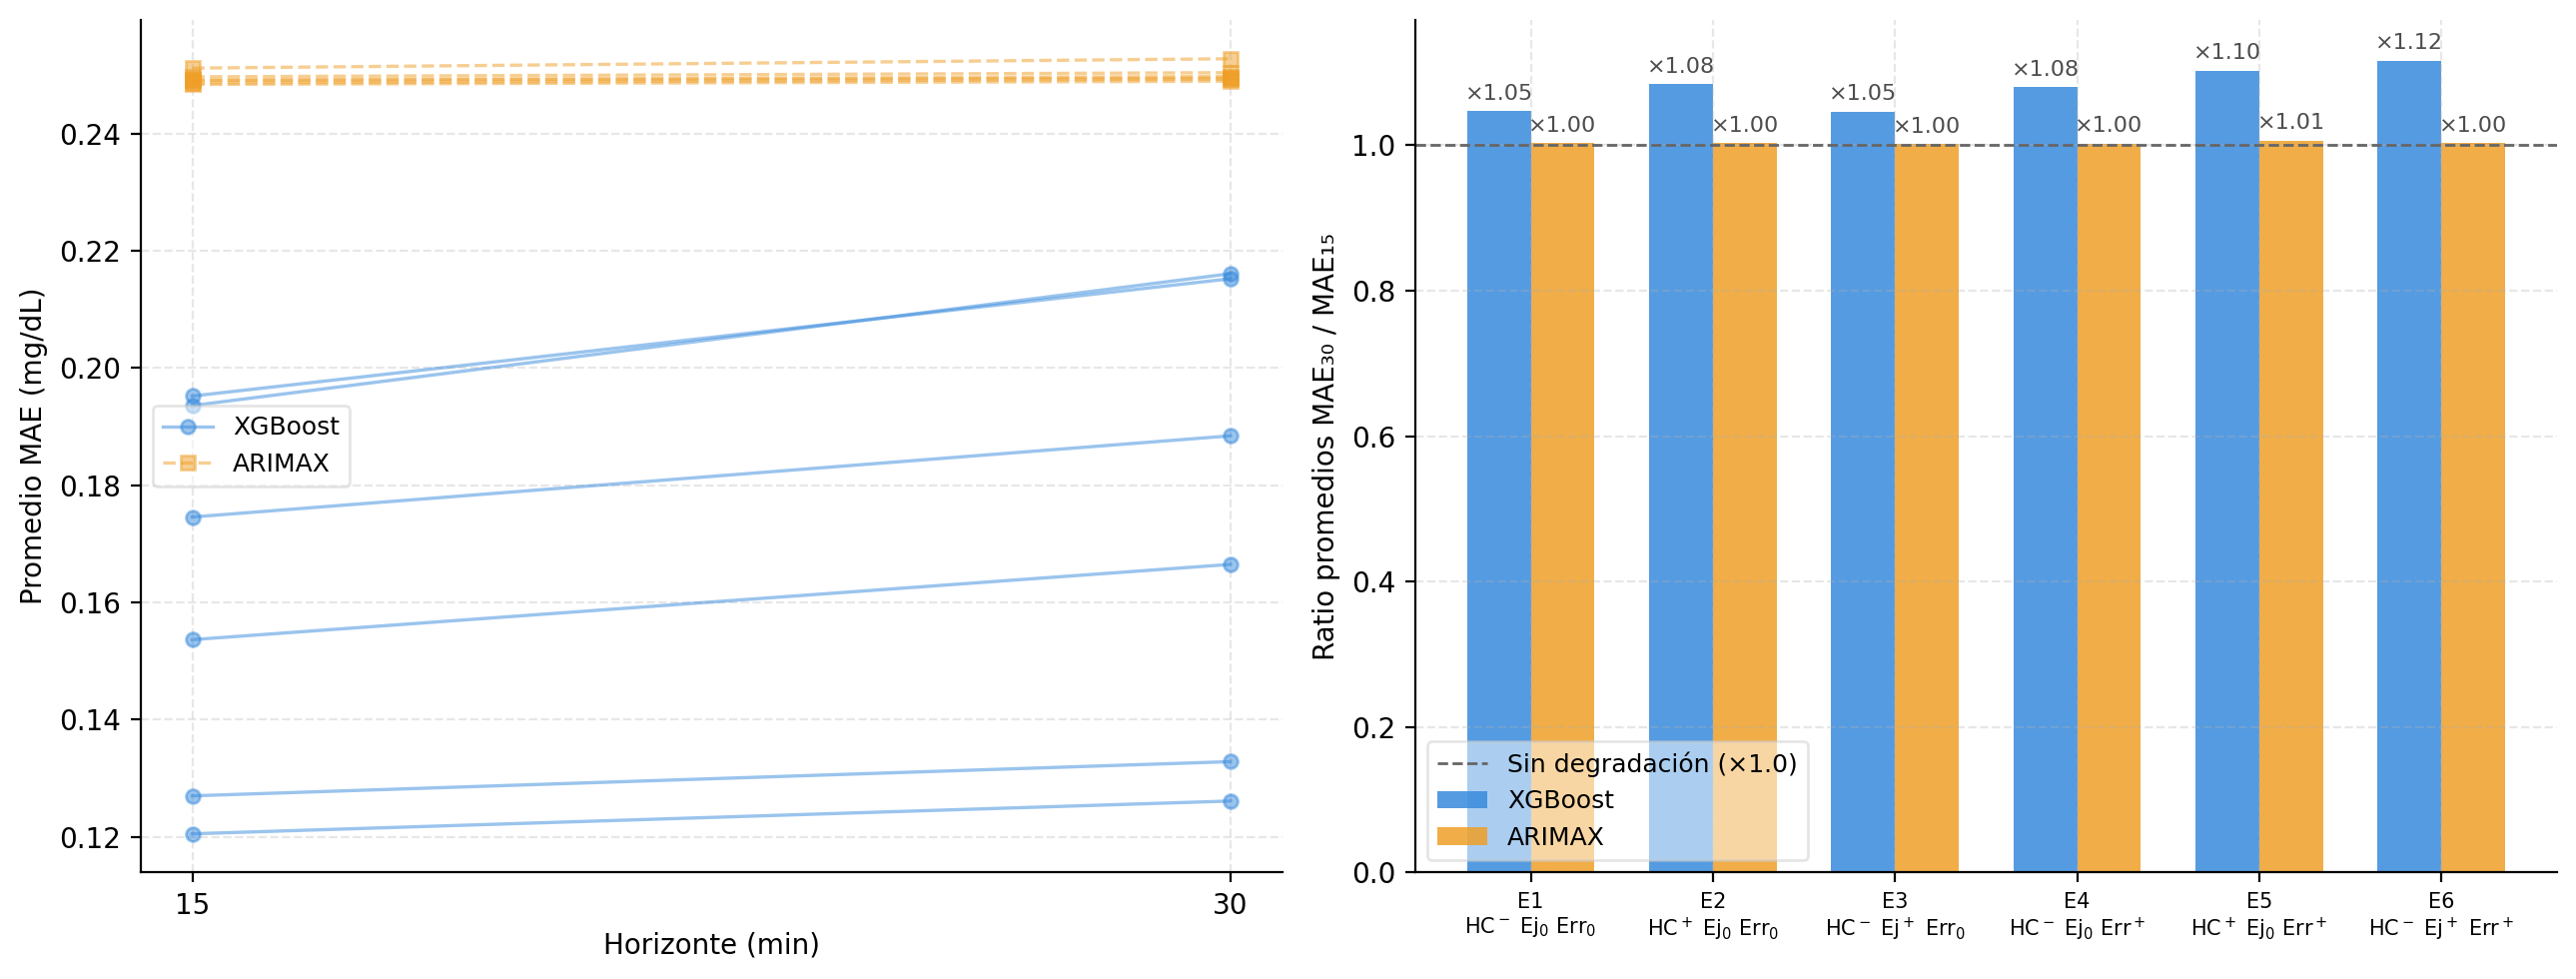

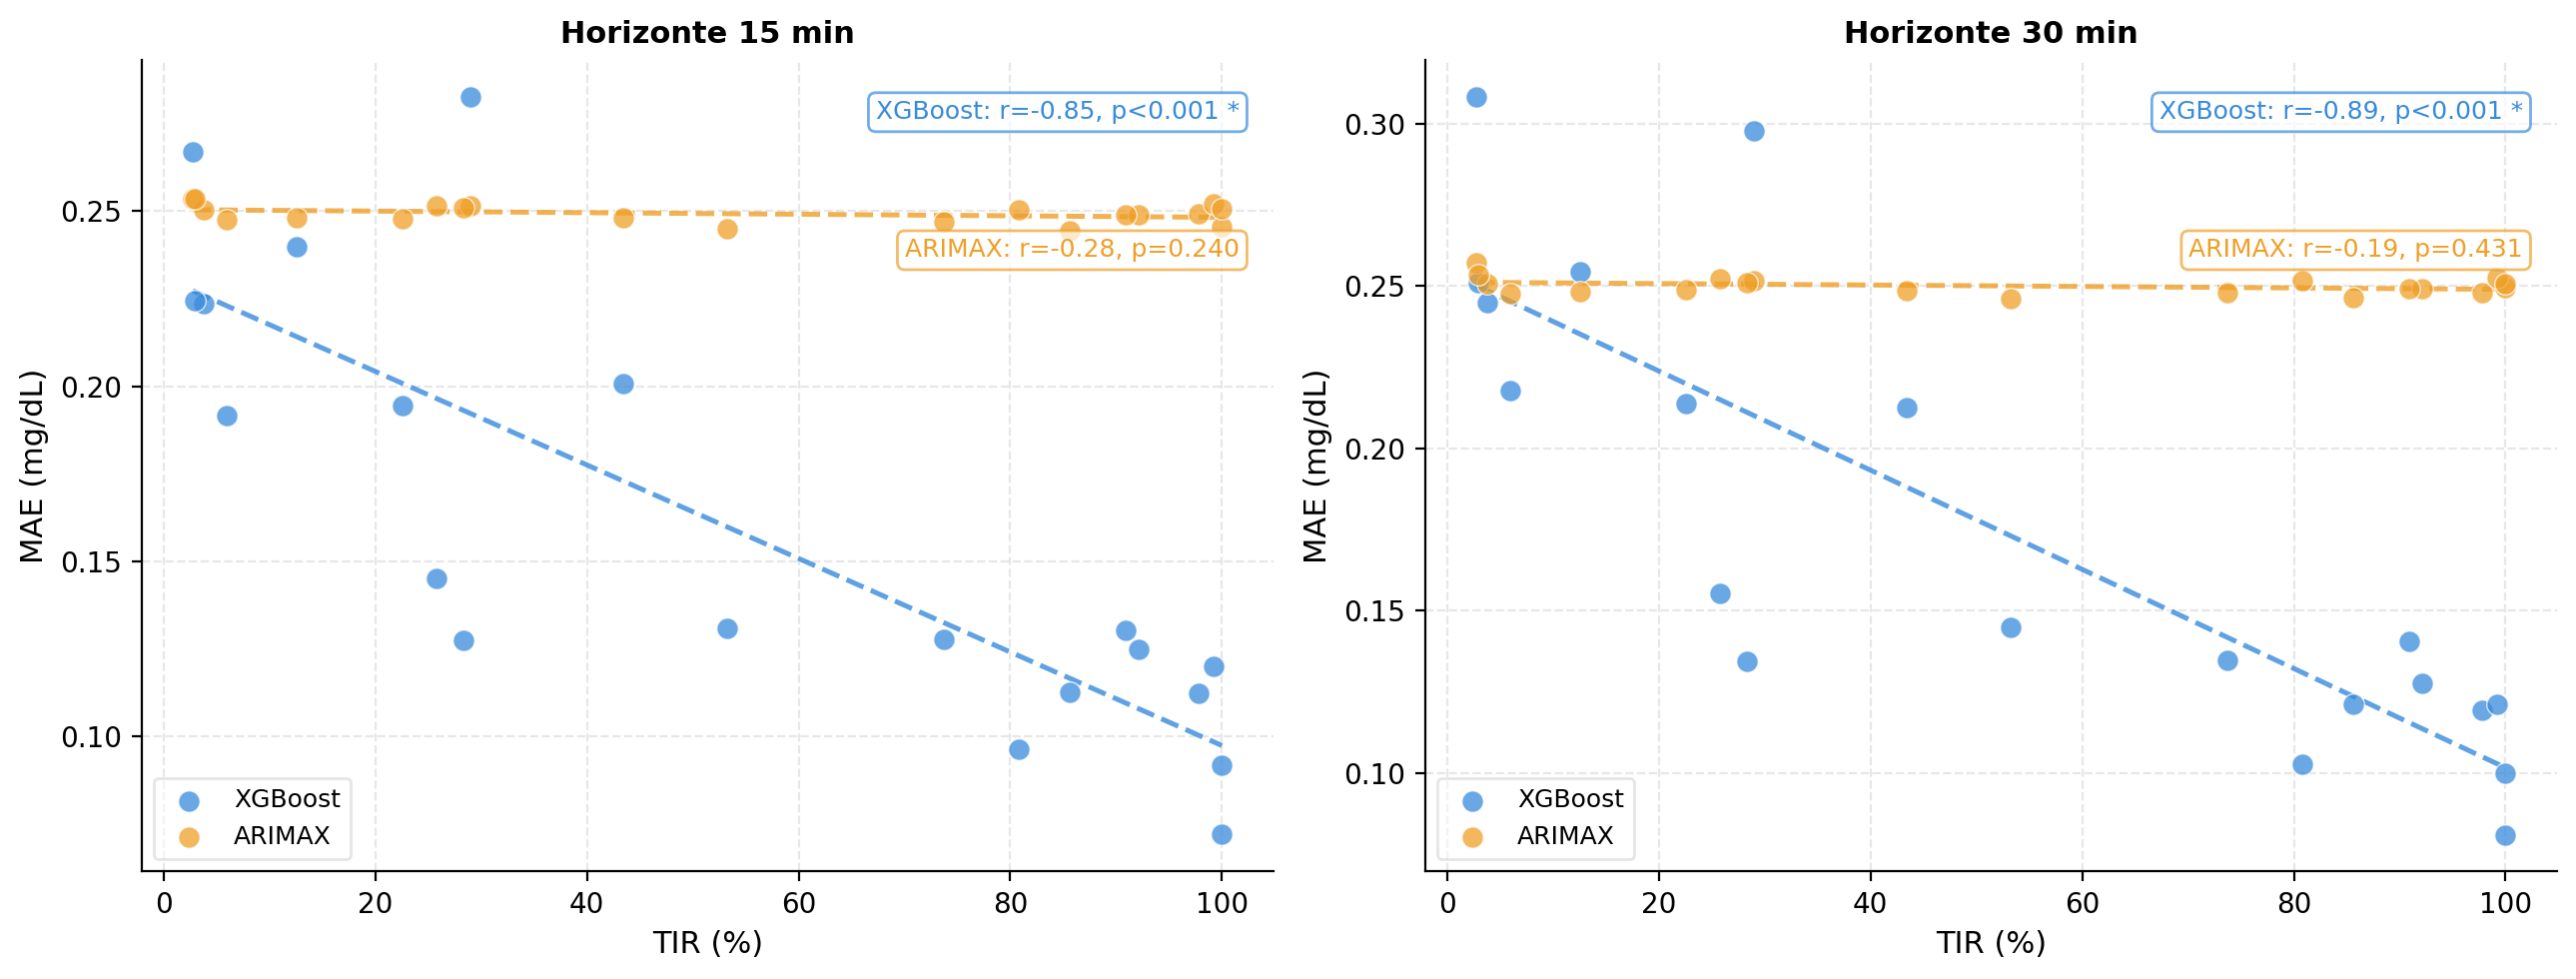

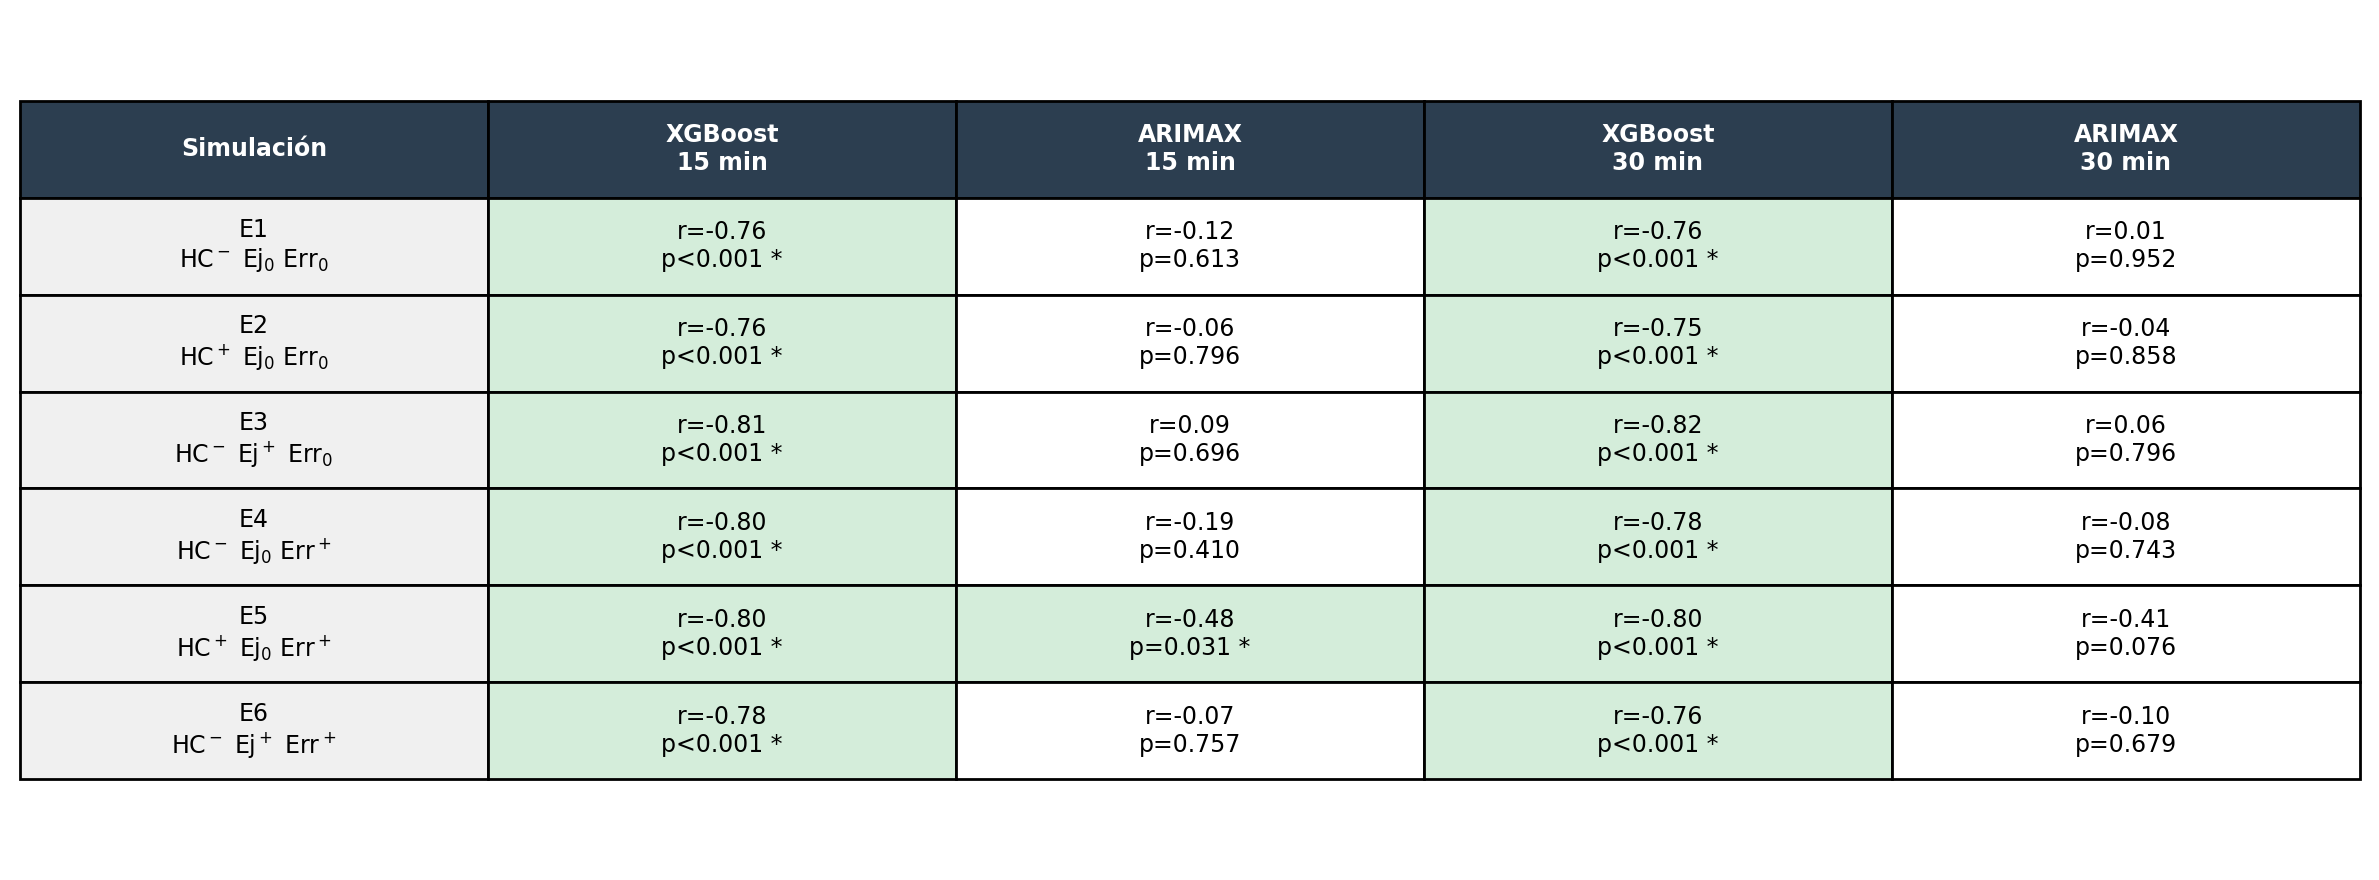

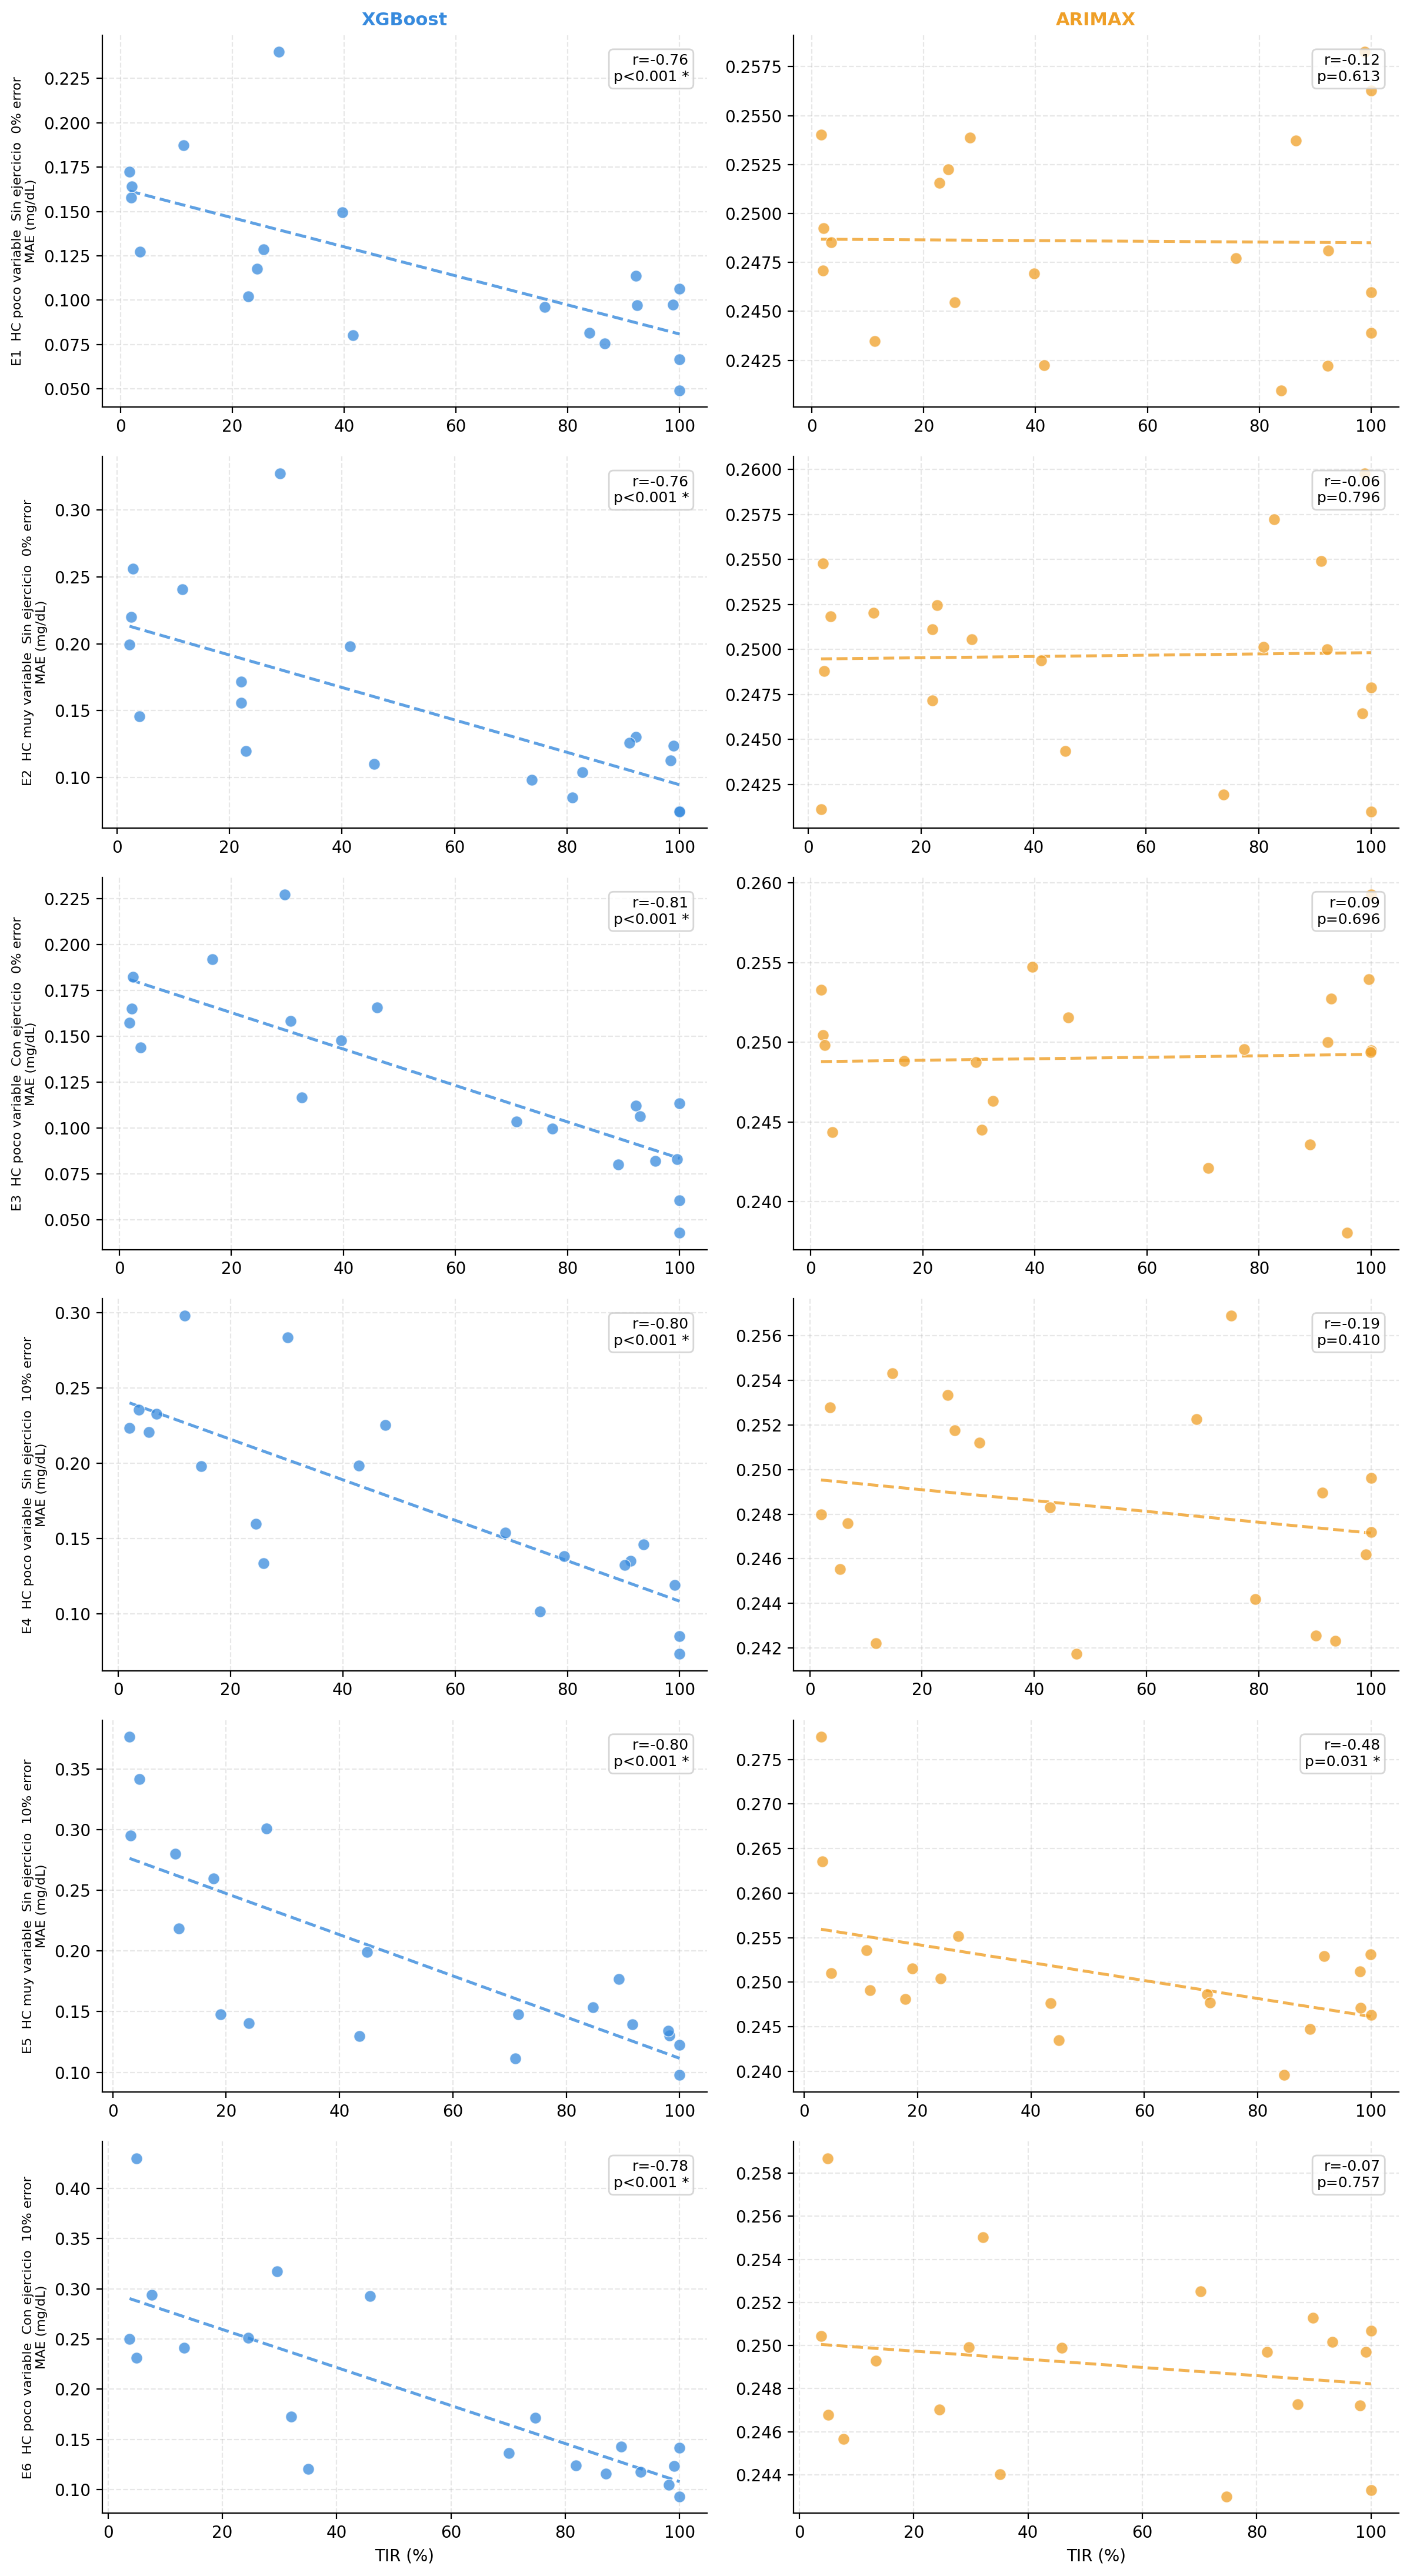

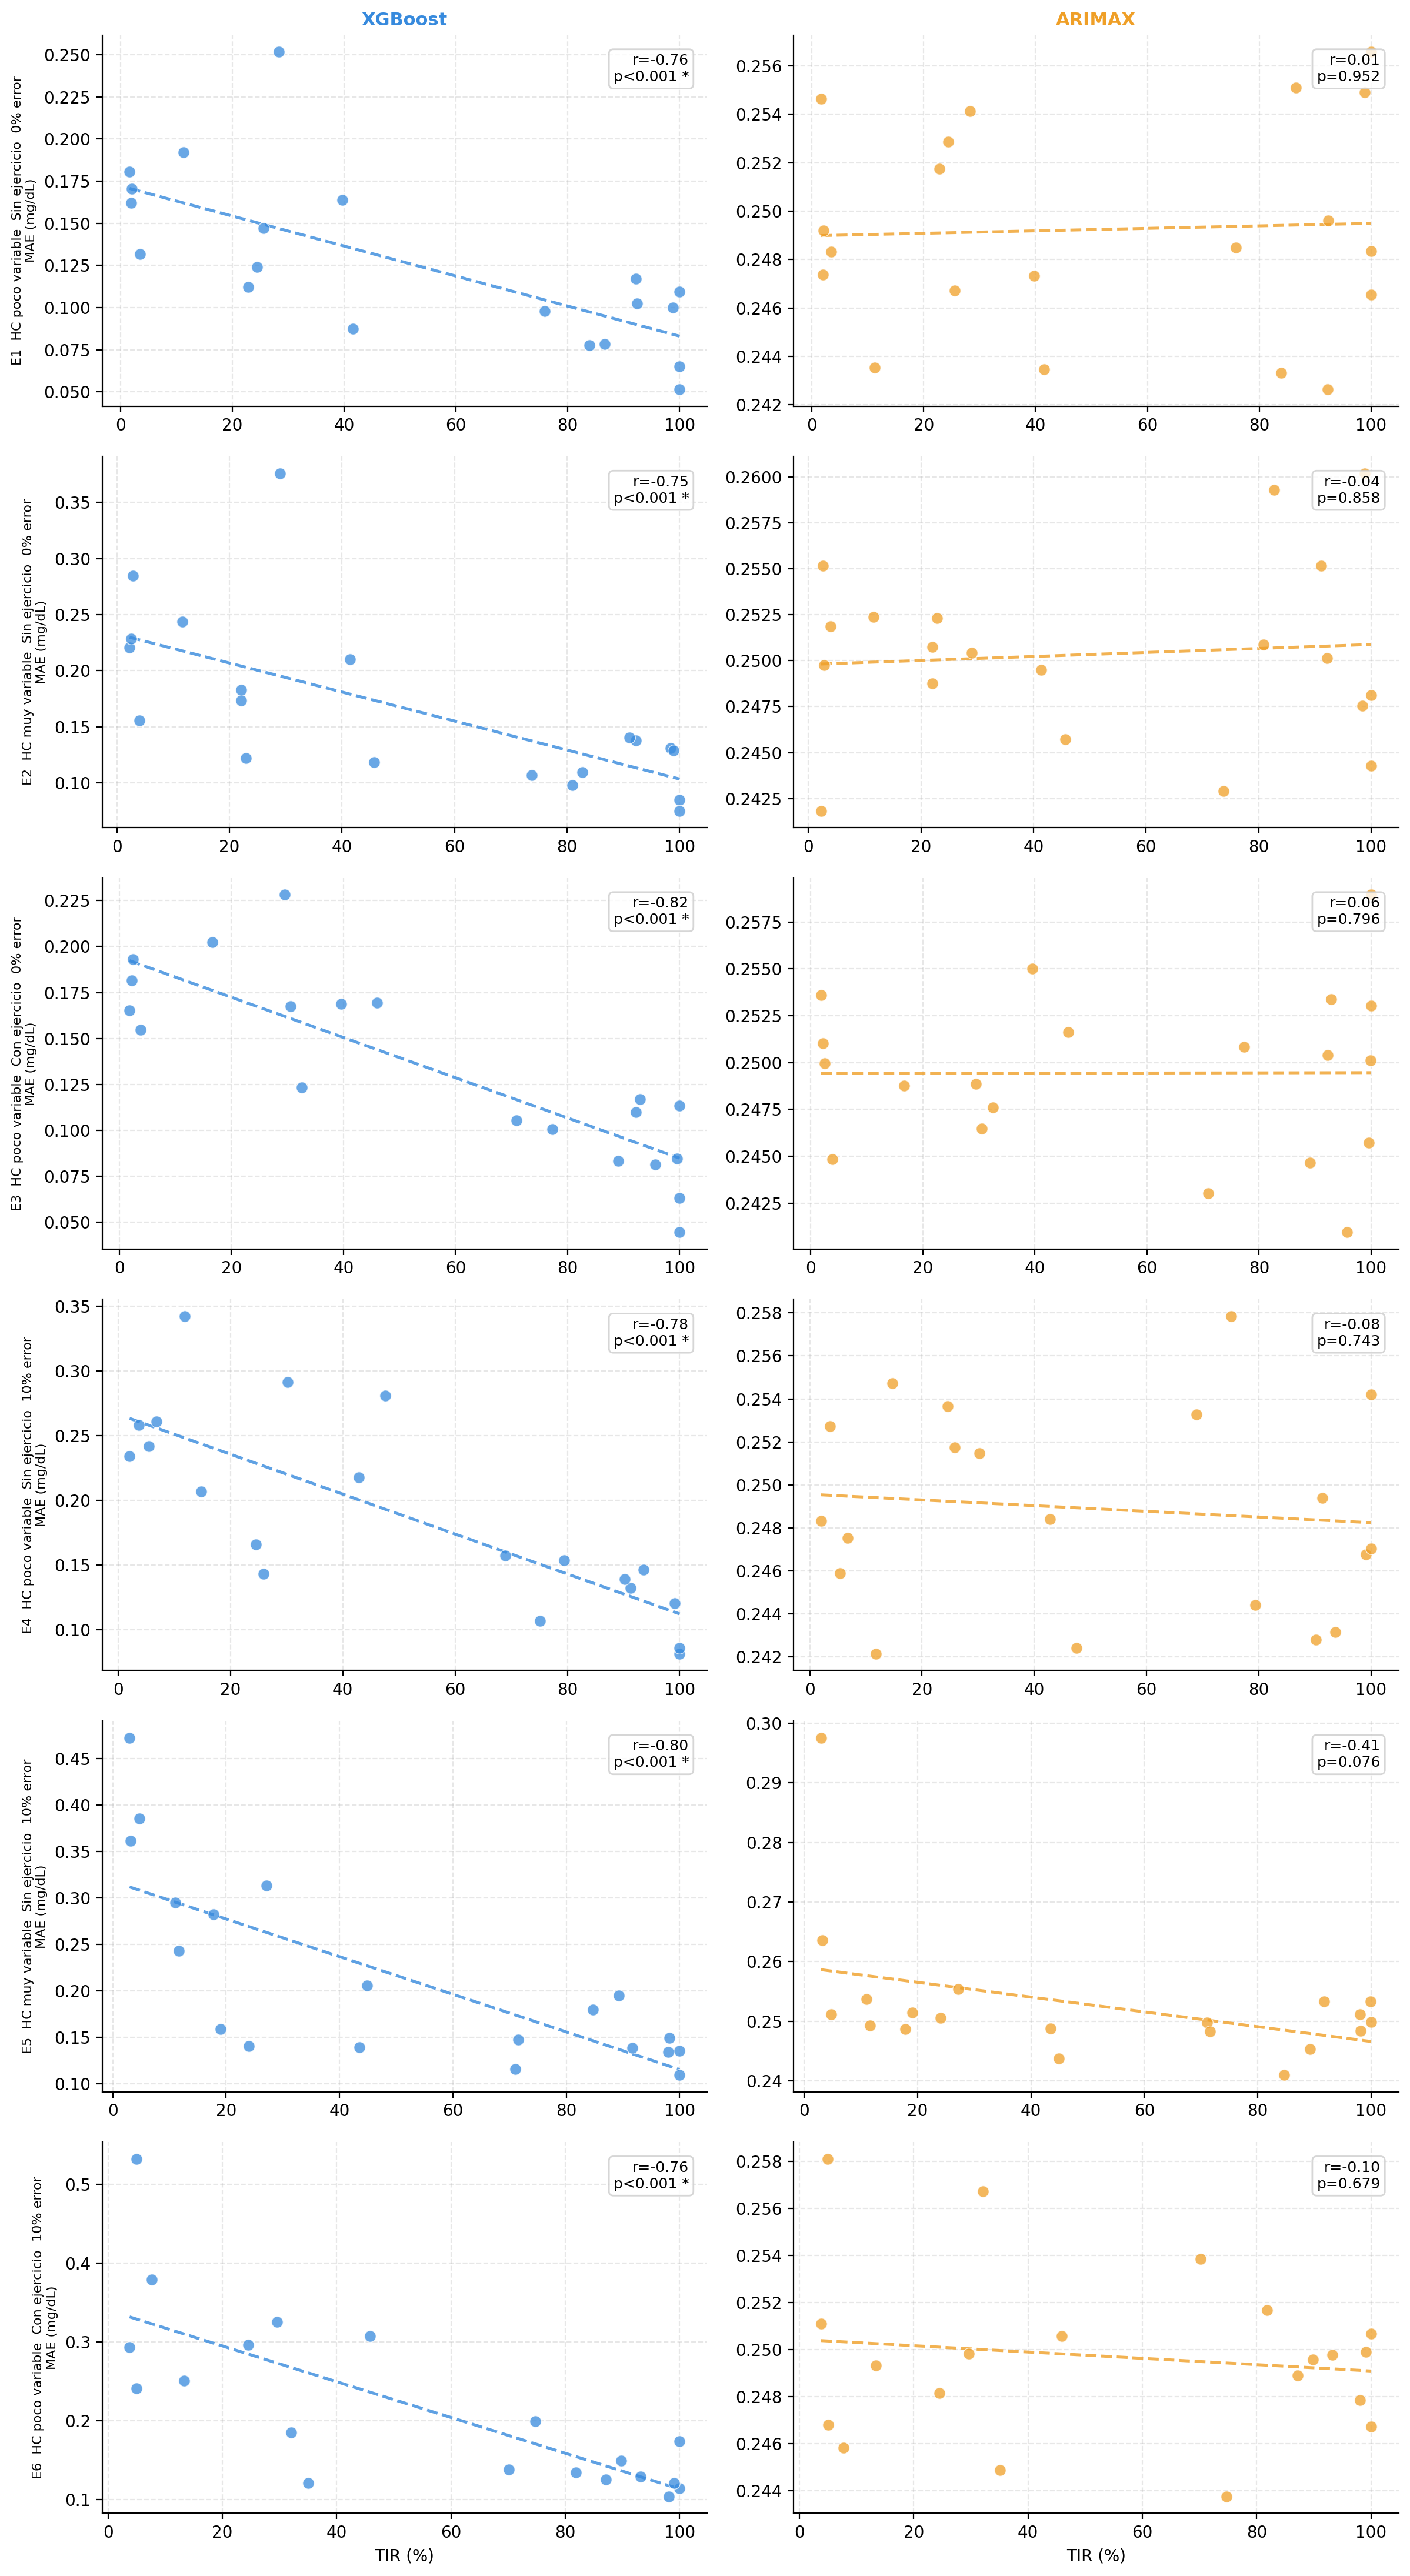

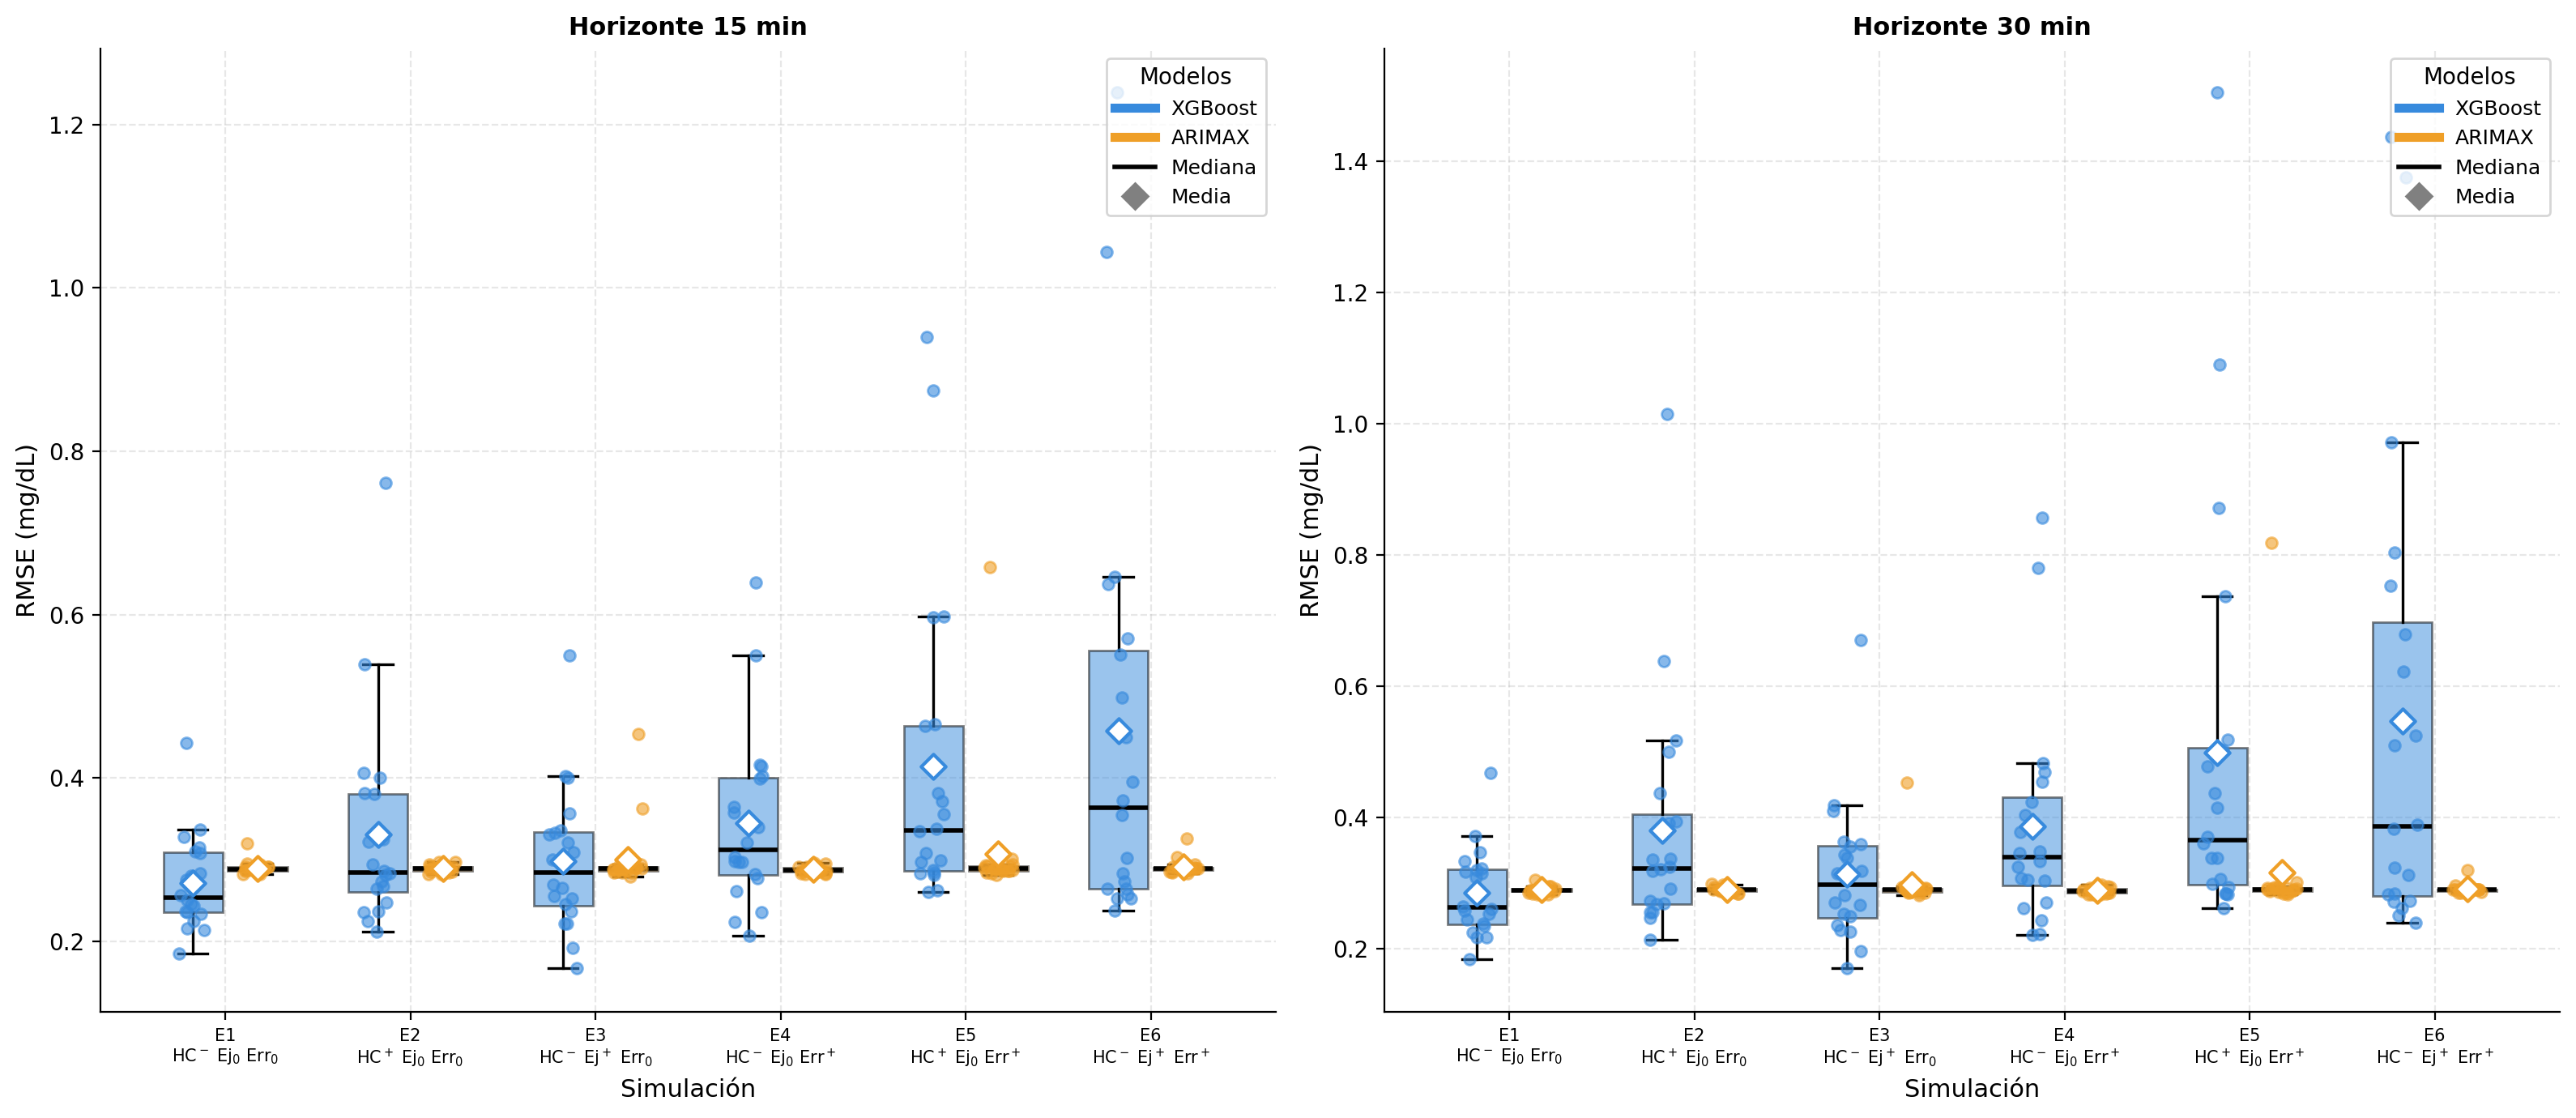

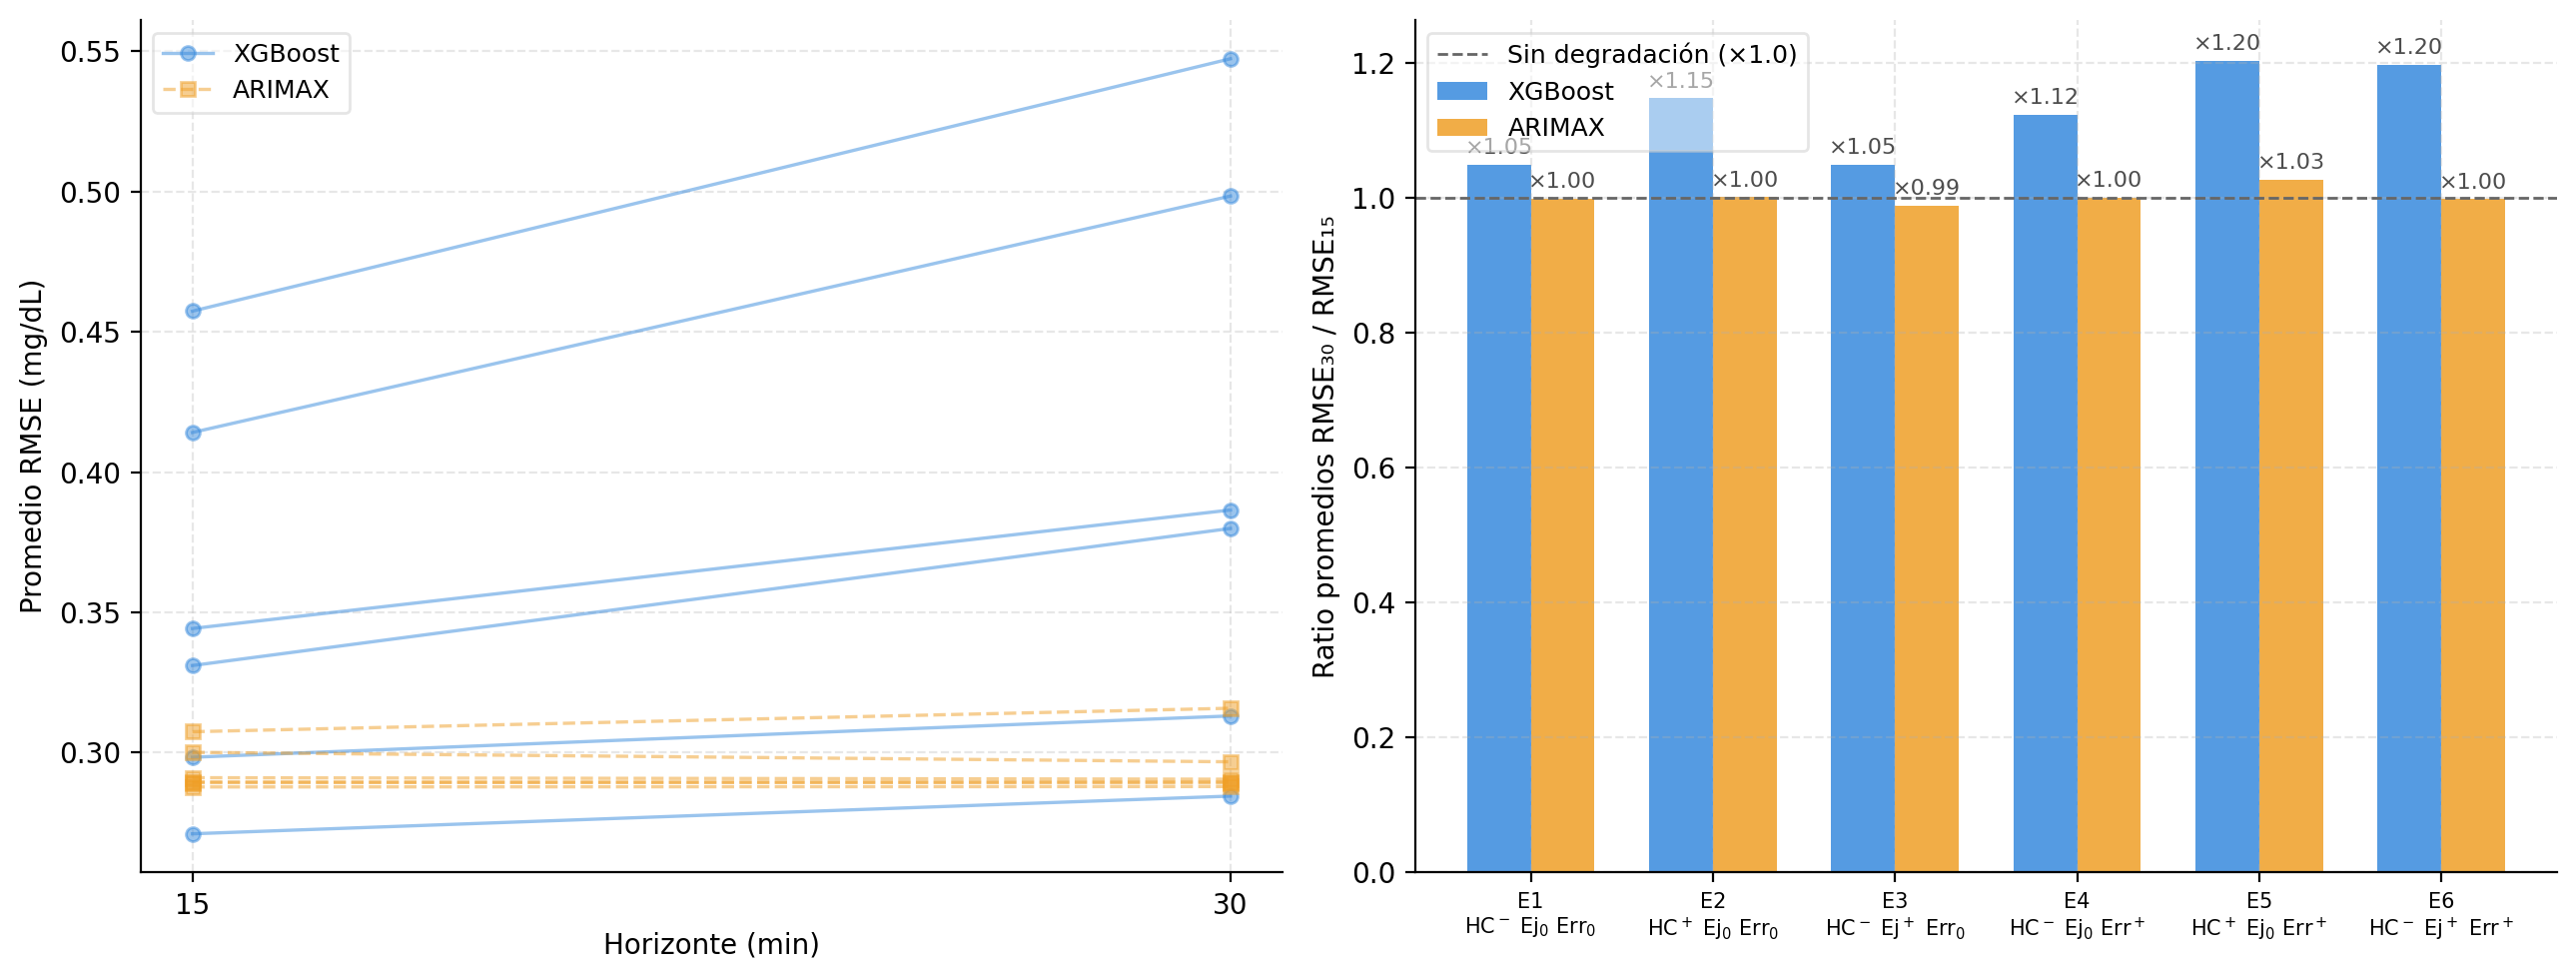

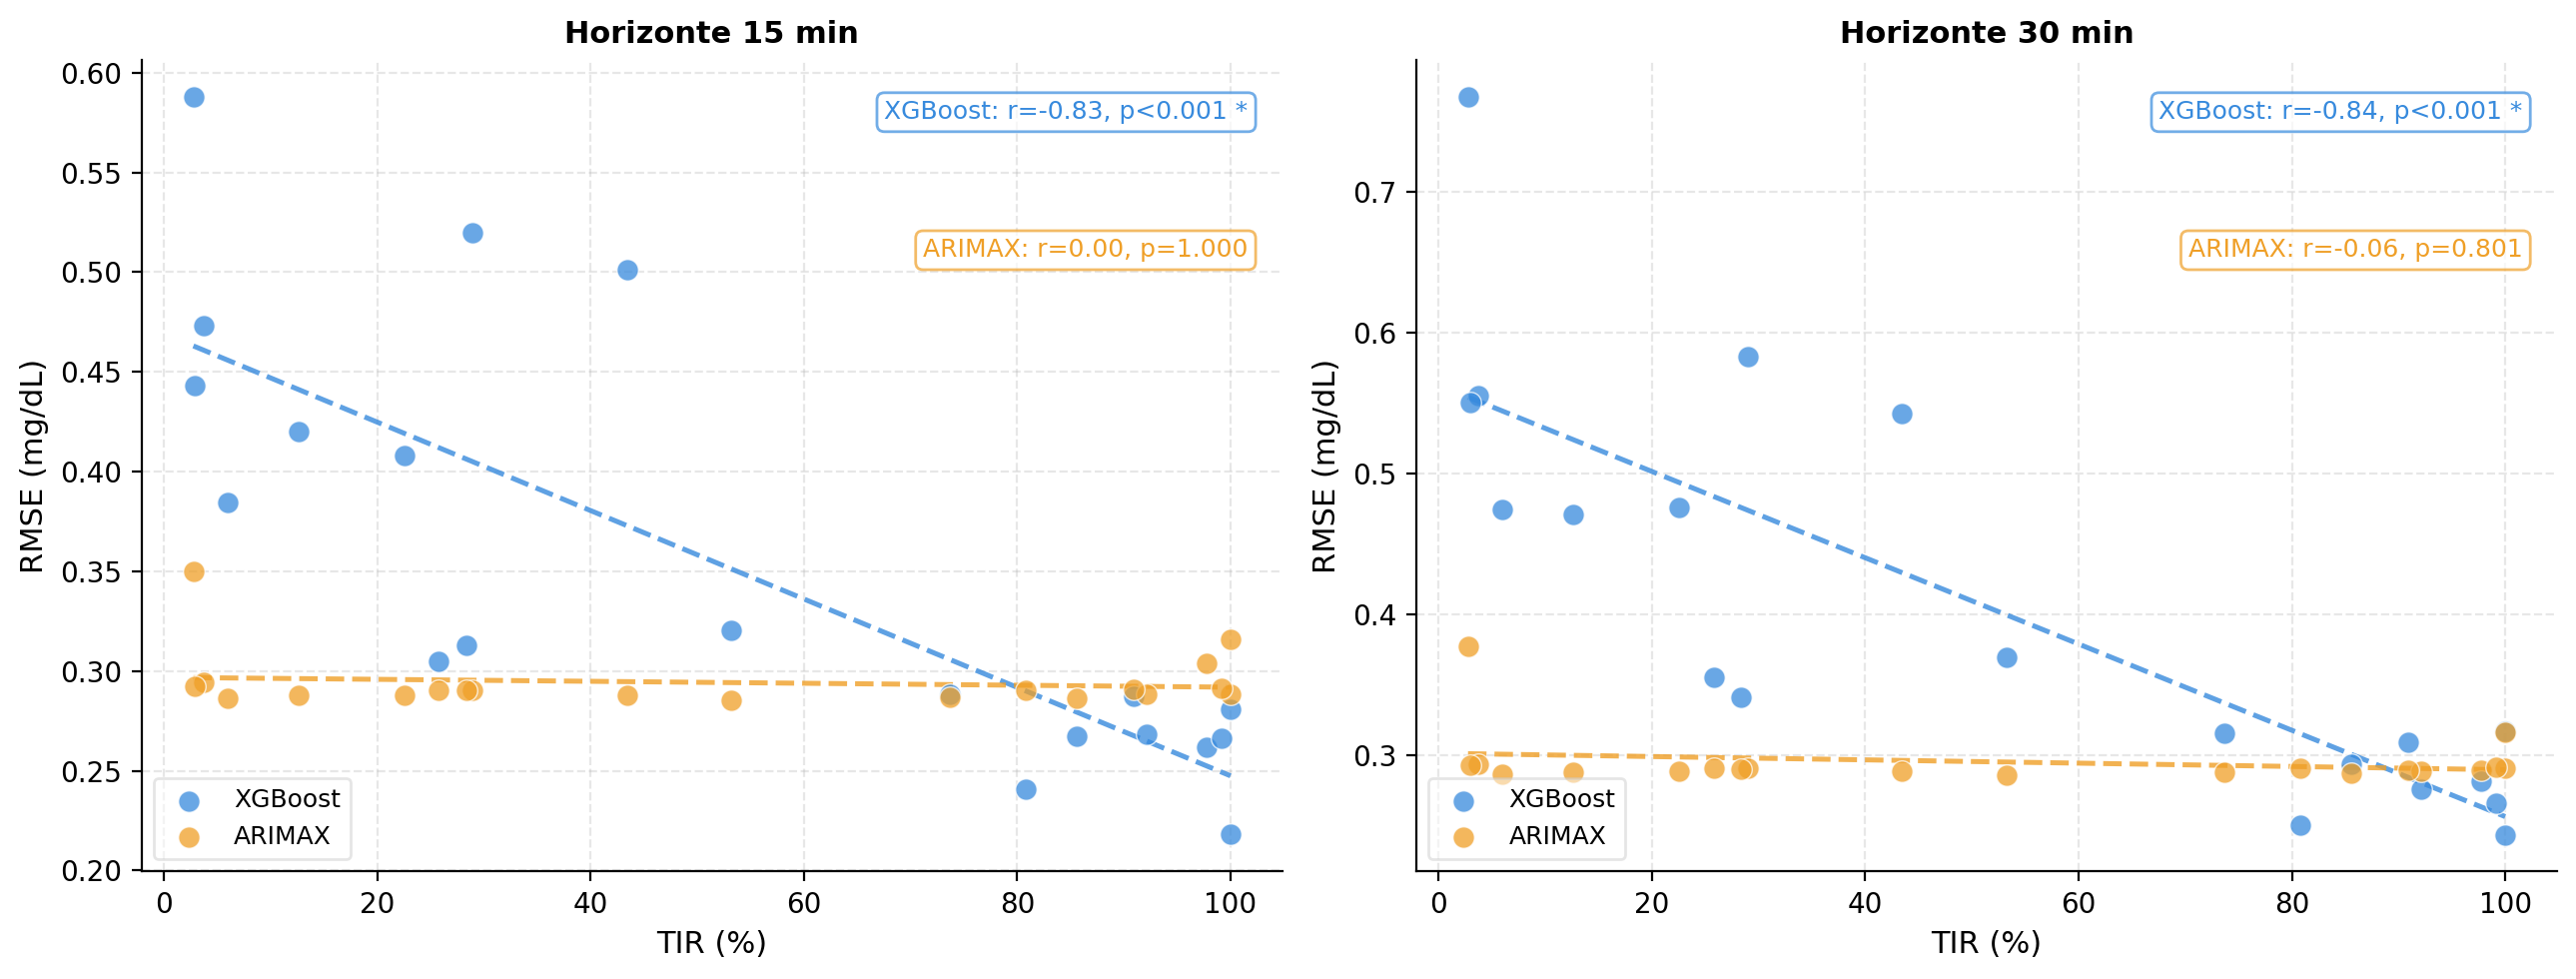

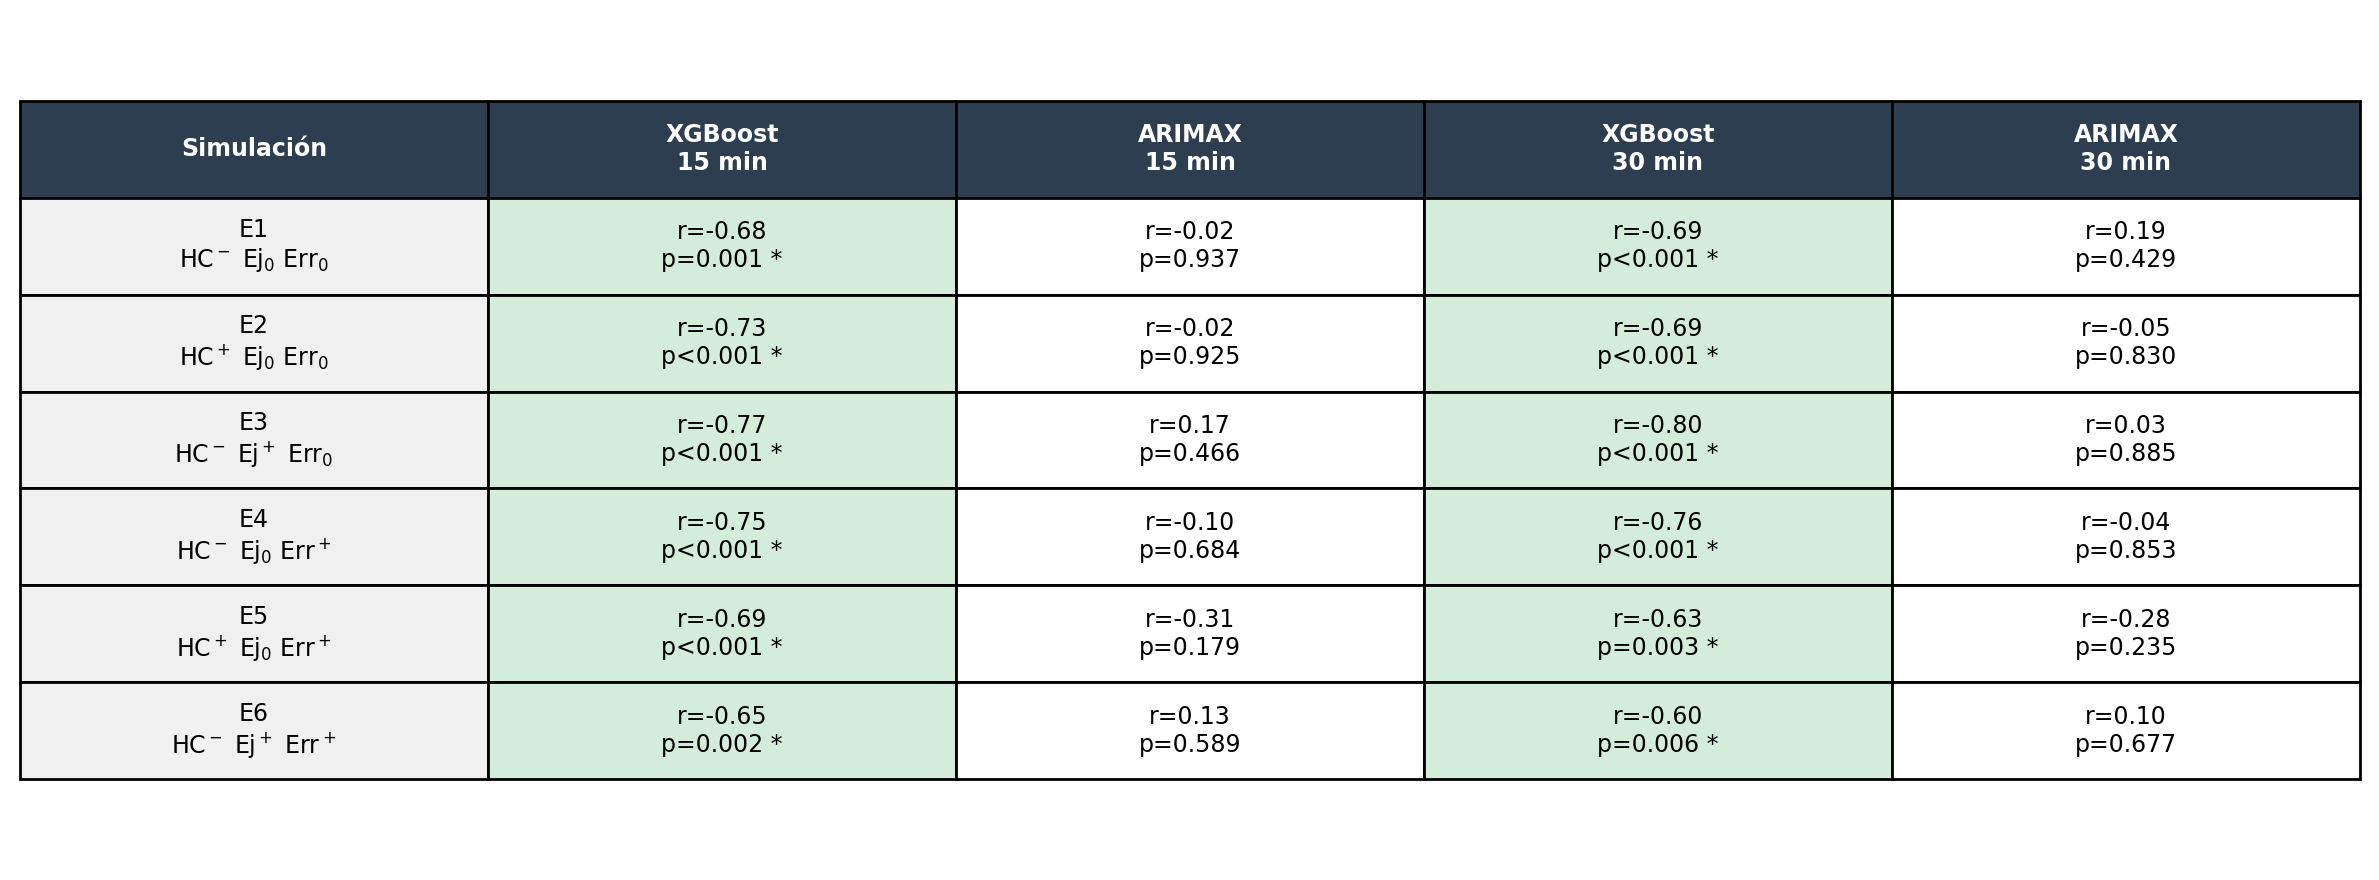

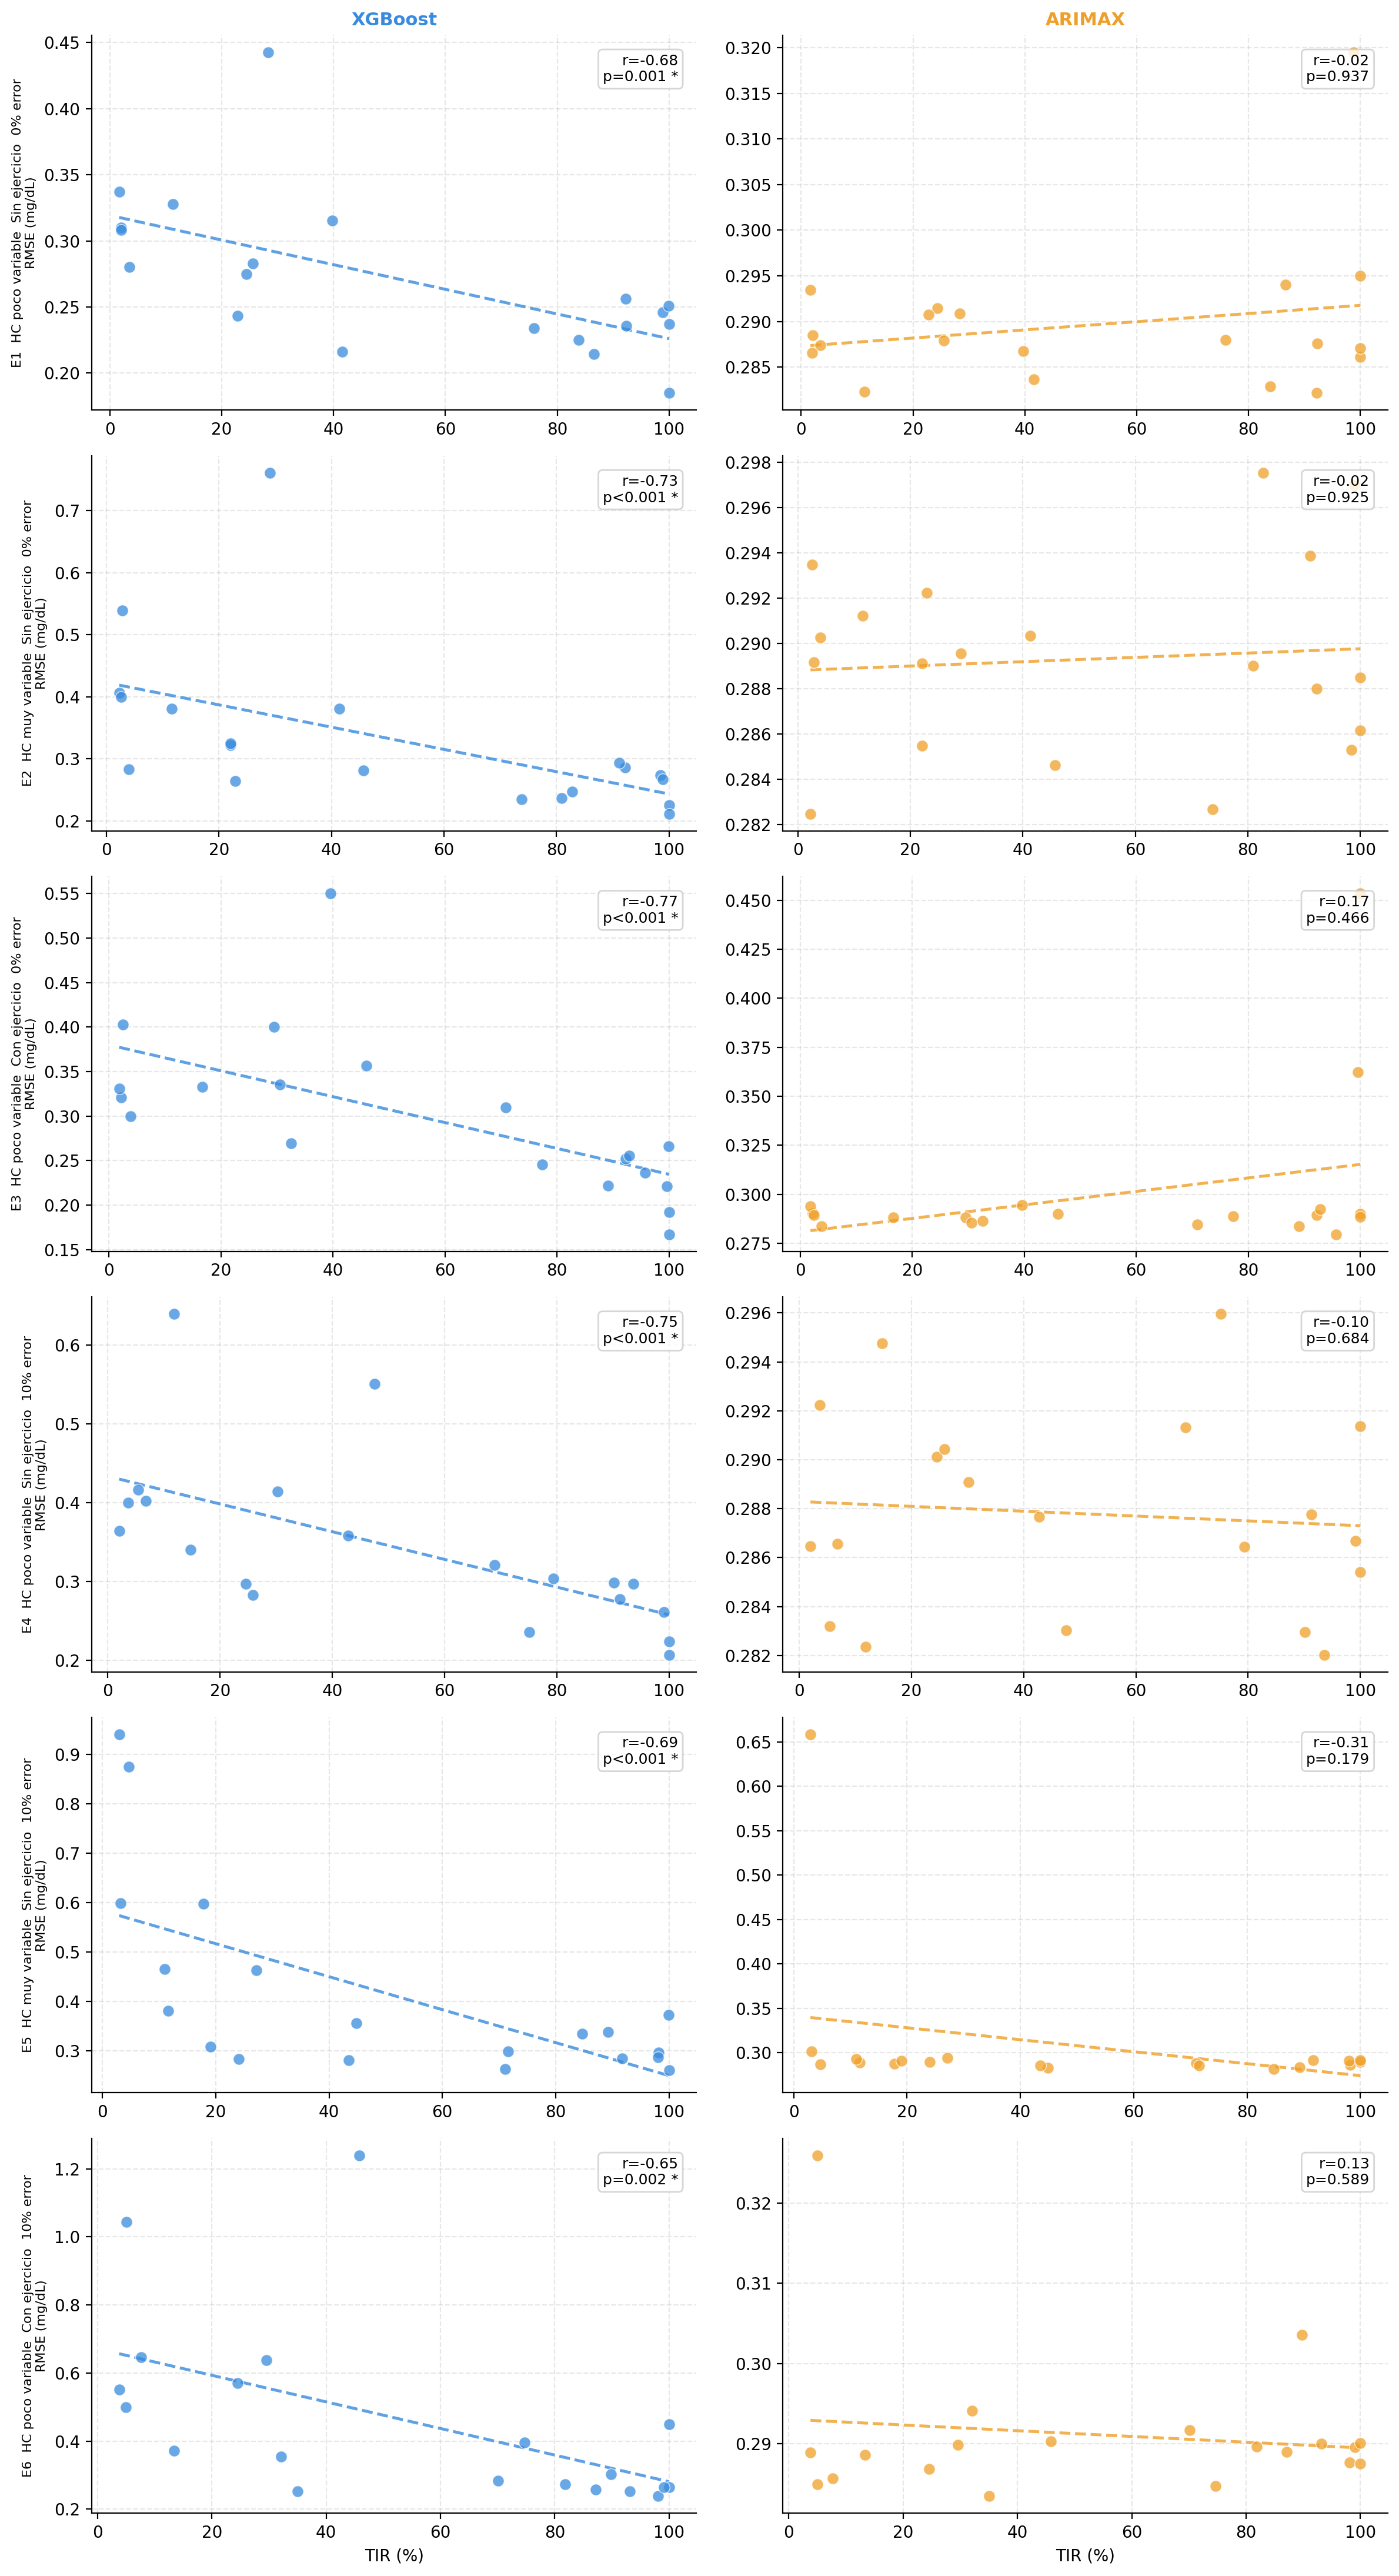

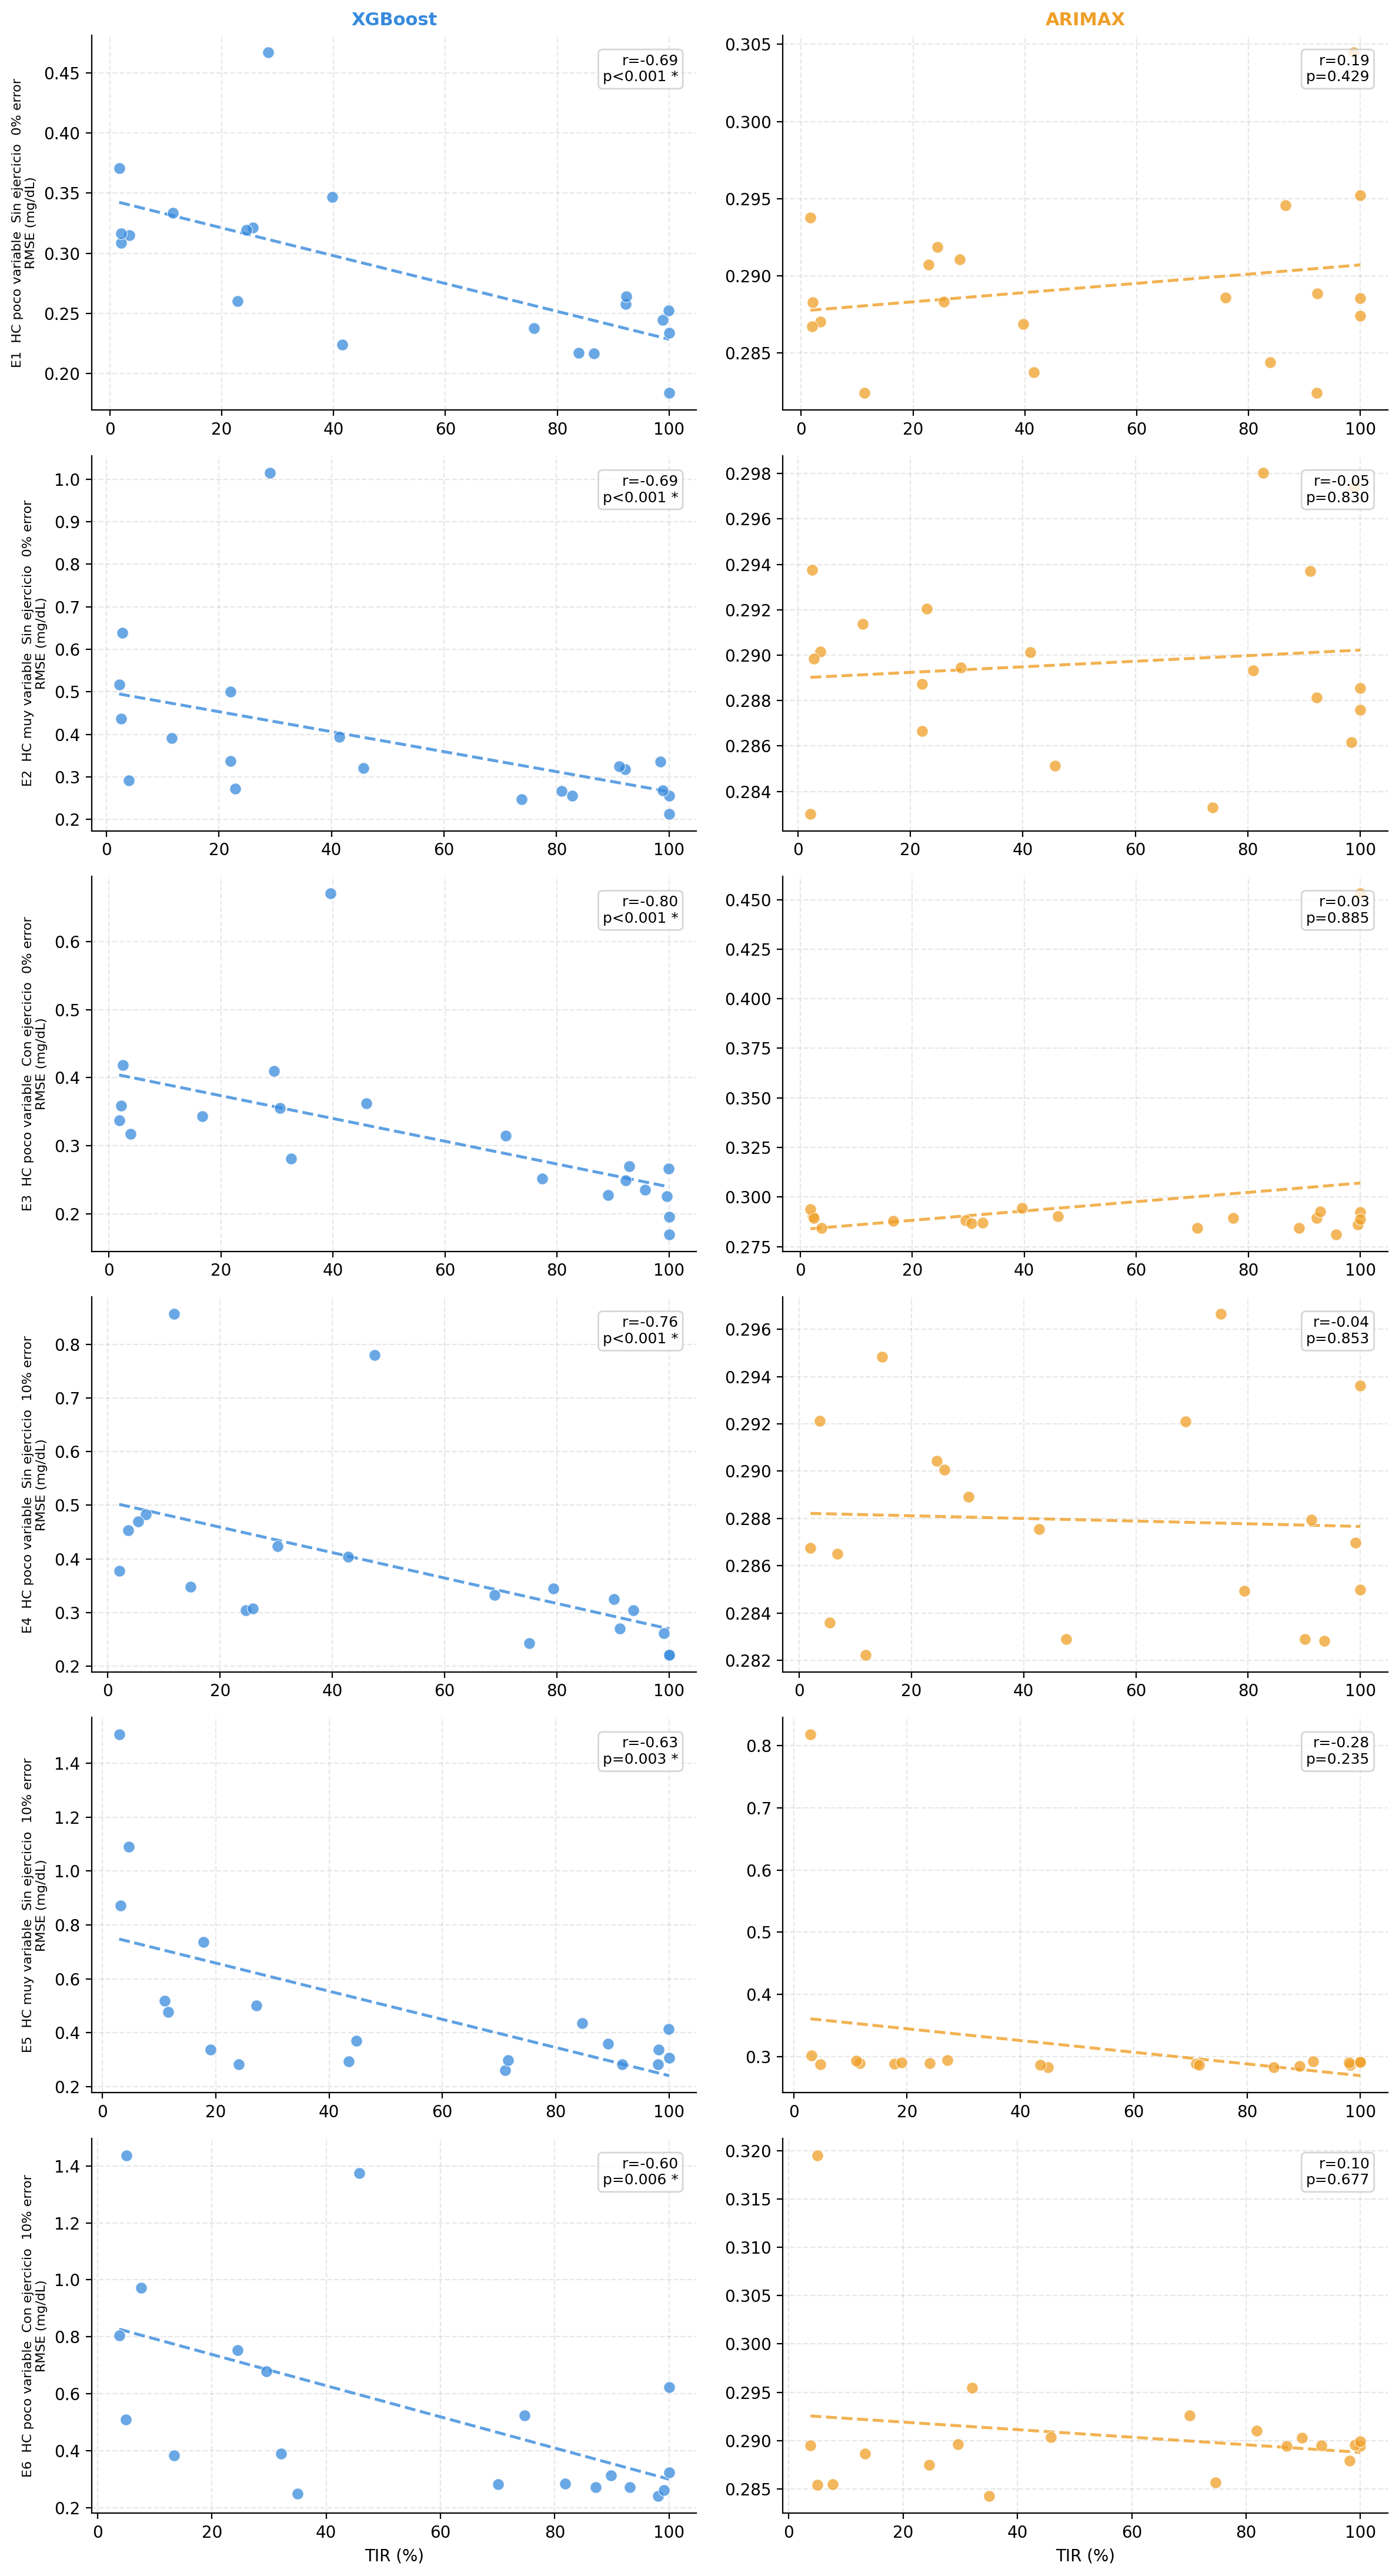

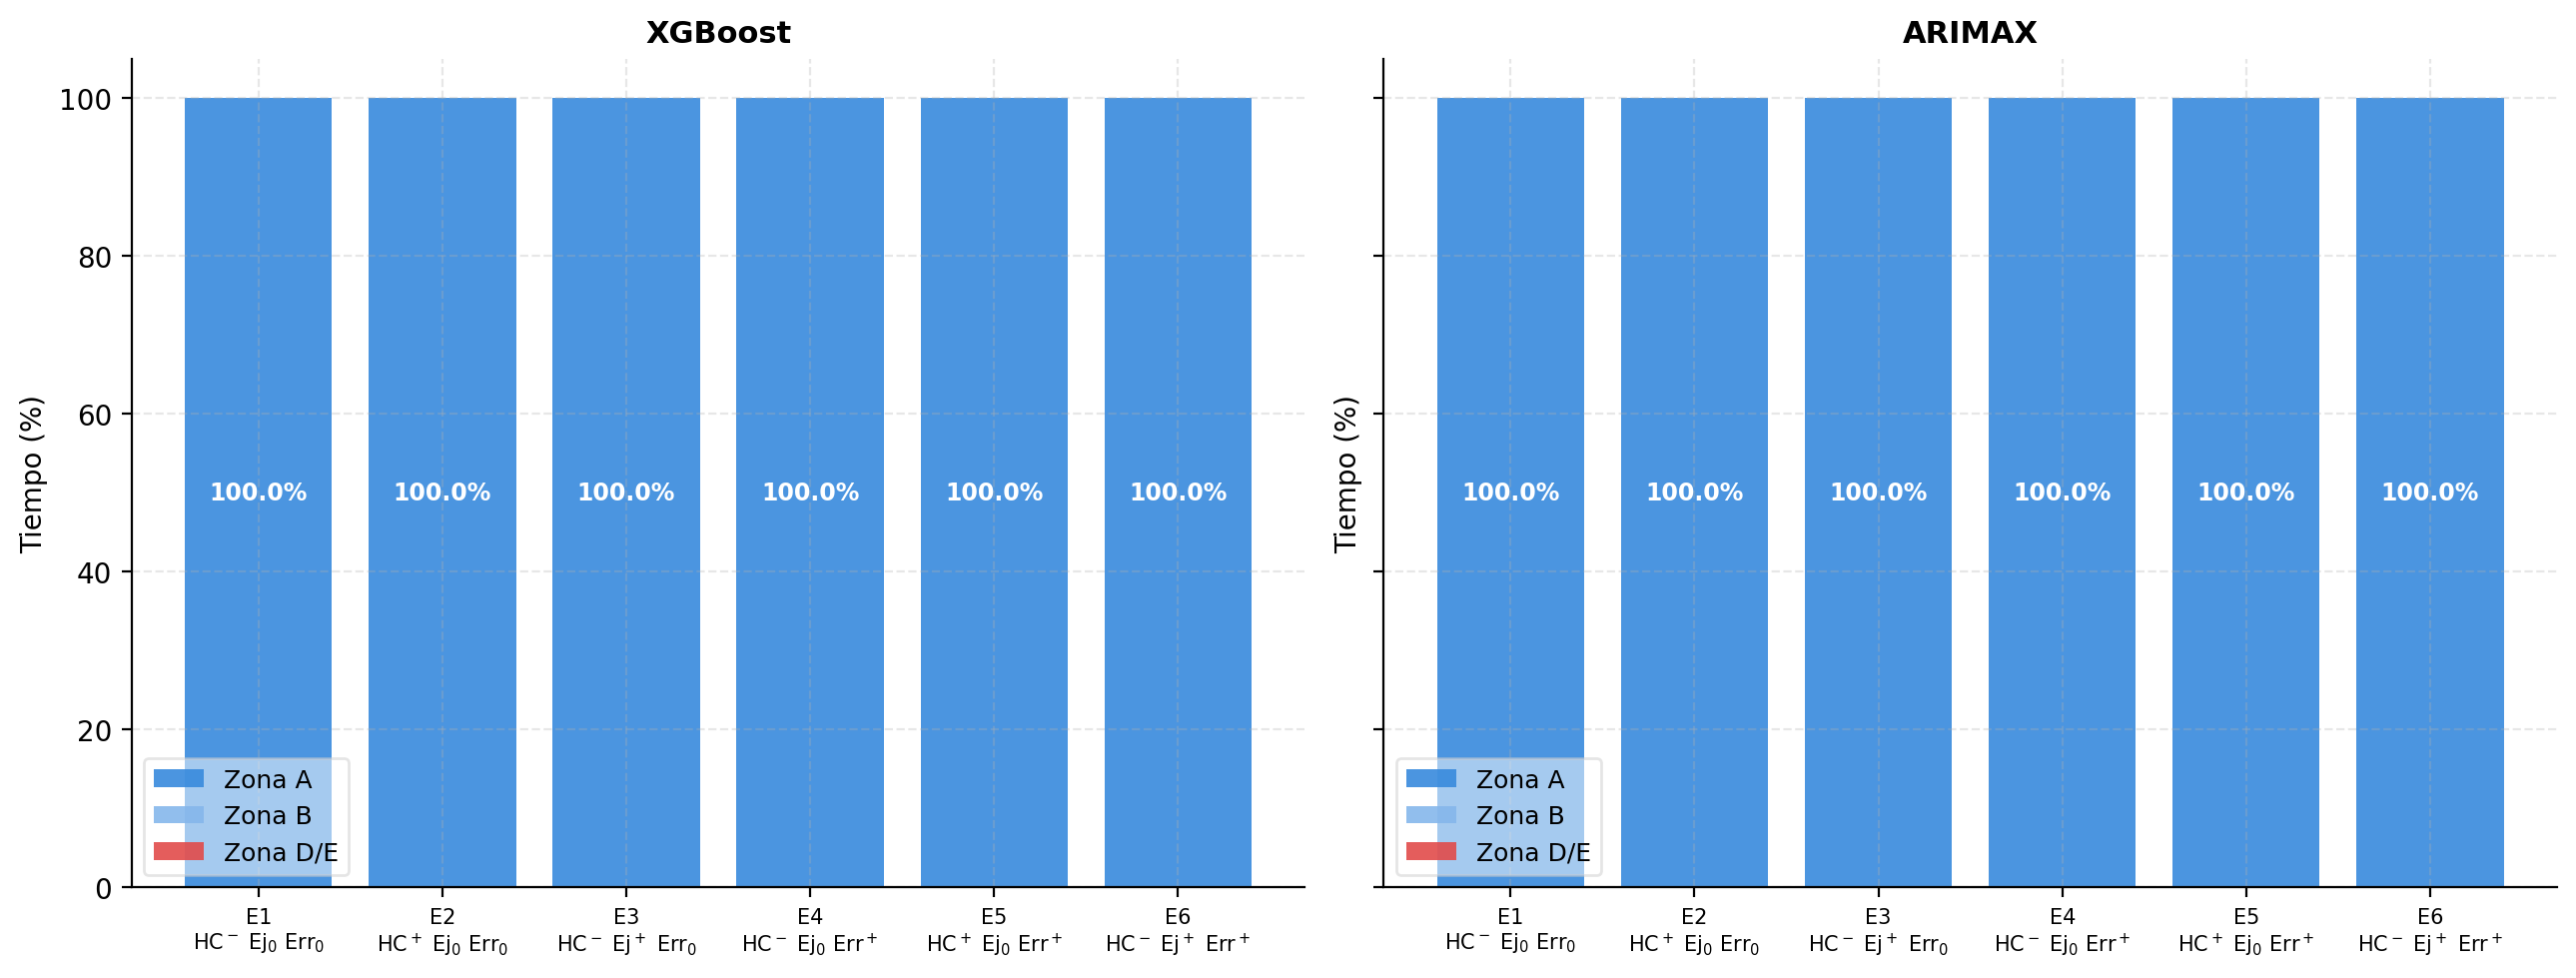

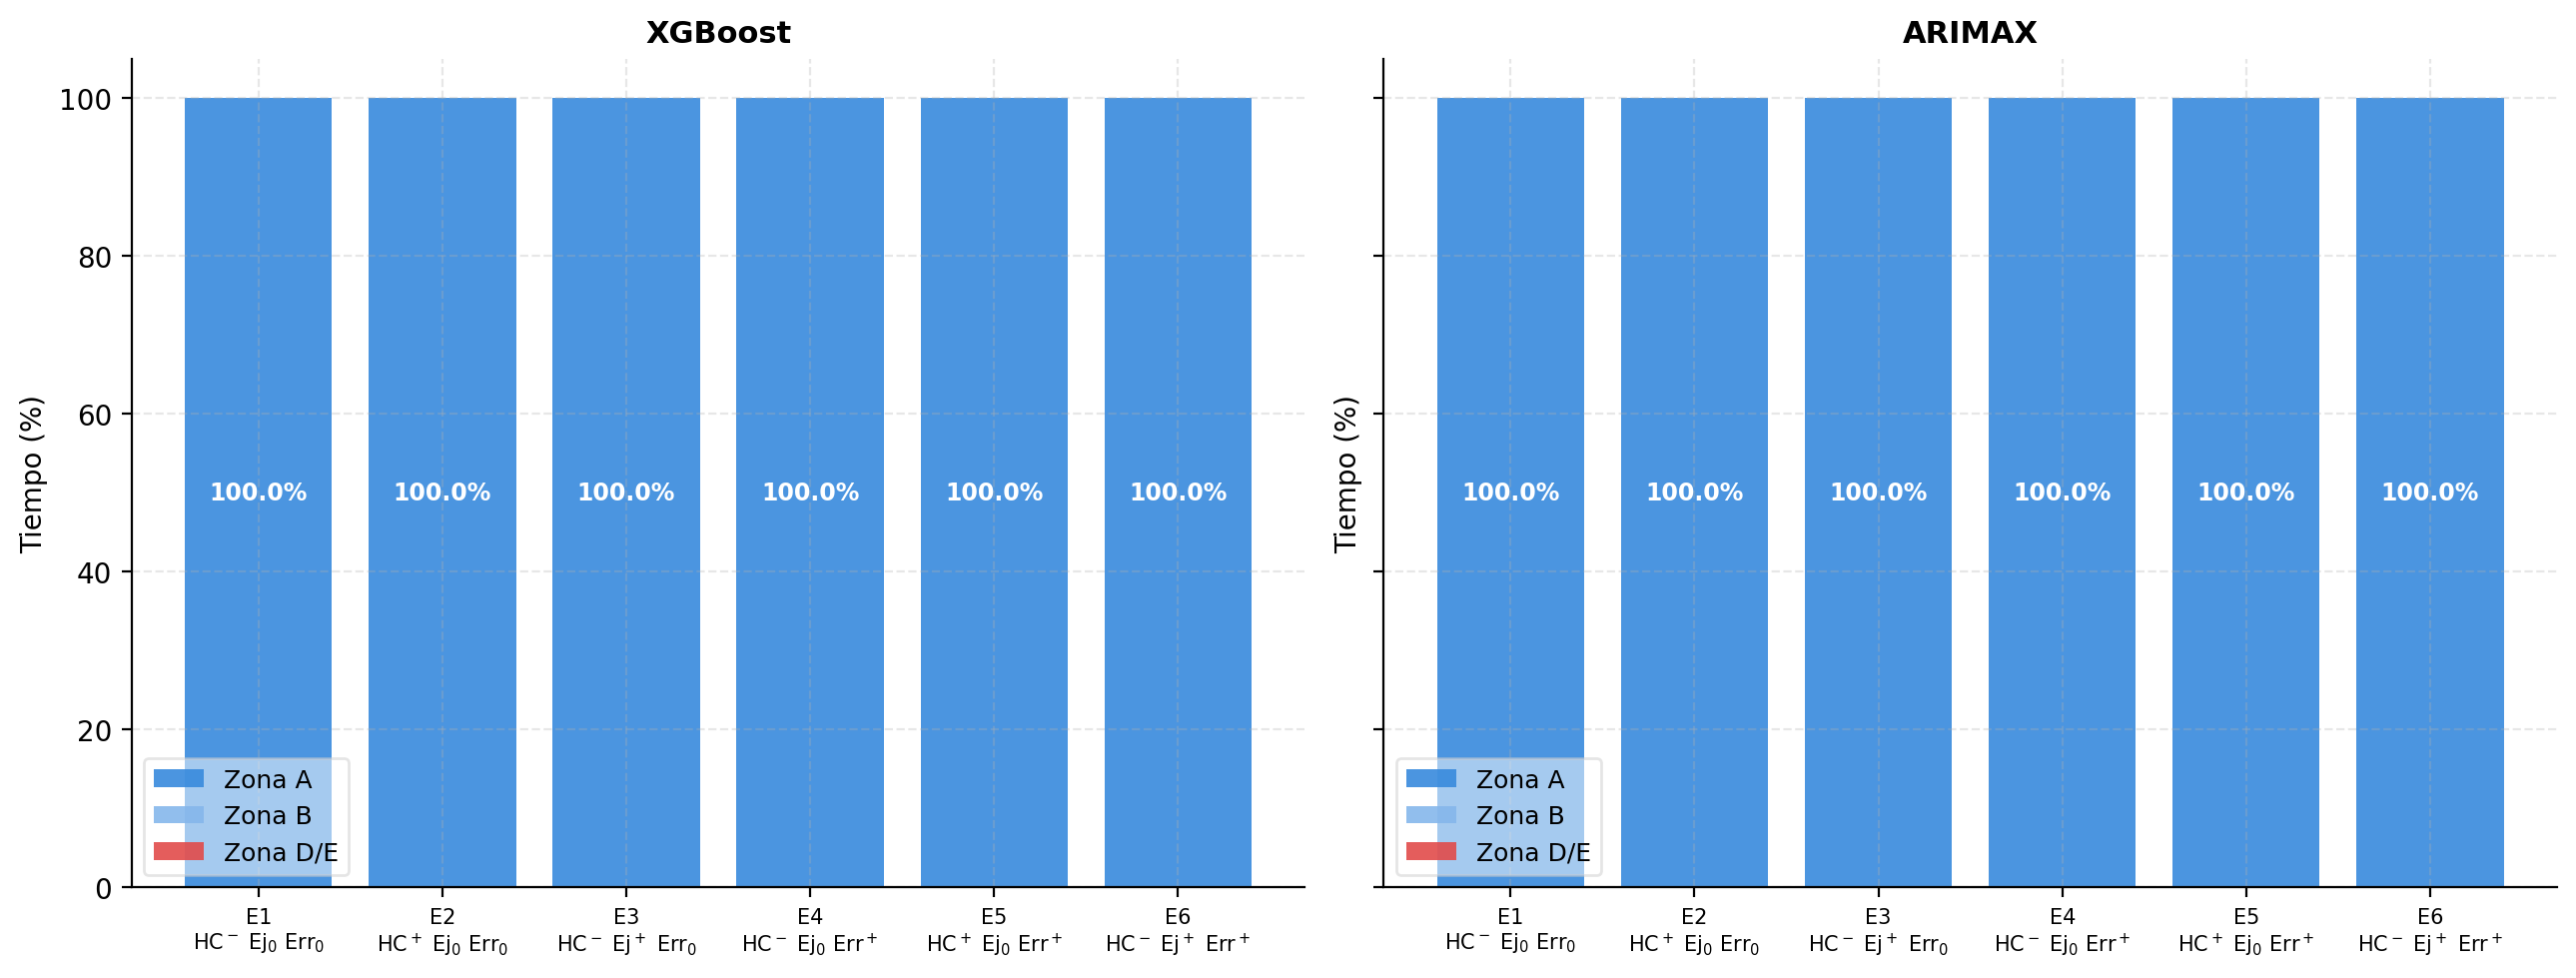

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# EJECUCIÓN
# ══════════════════════════════════════════════════════════════════════════════
# --- Cargar datos ---
df_res = pd.read_csv('Resultados/resultados_modelos.csv')
df_tir = pd.read_csv('Resultados/TIR.csv')
df = preparar_datos(df_res, df_tir)

# --- Generar todas las gráficas ---
grafica_barras_mae(df,    guardar=True)
grafica_barras_rmse(df,   guardar=True)

for metrica in ['MAE', 'RMSE']:
    grafica_boxplot(df,          metrica=metrica, guardar=True)
    grafica_degradacion(df,      metrica=metrica, guardar=True)
    grafica_scatter_tir_agregado(df, metrica=metrica, guardar=True)
    grafica_tabla_spearman(df,   metrica=metrica, guardar=True)
    for h in [15, 30]:
        grafica_scatter_tir(df, metrica=metrica, horizonte=h, guardar=True)

for h in [15, 30]:
    grafica_clarke(df, horizonte=h, guardar=True)

print("Todas las gráficas generadas.")

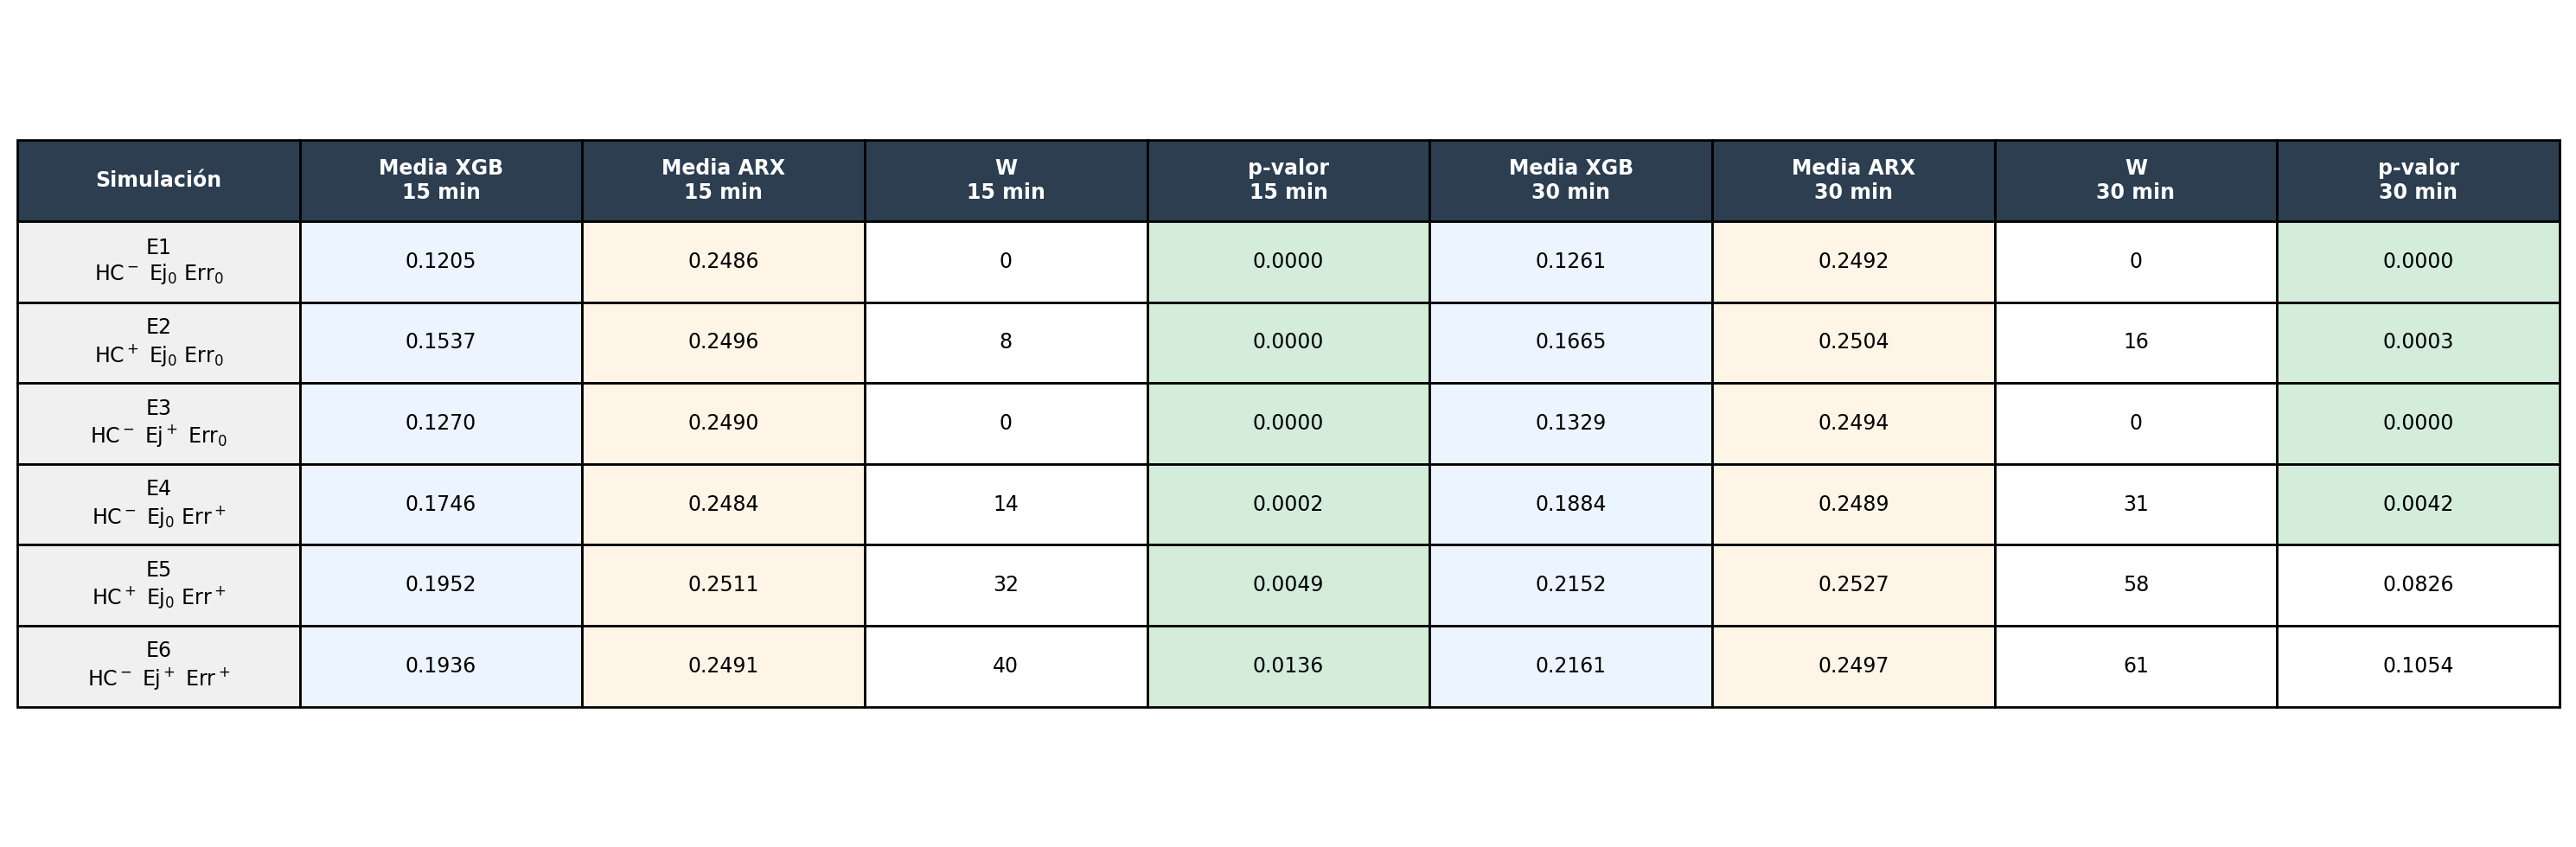

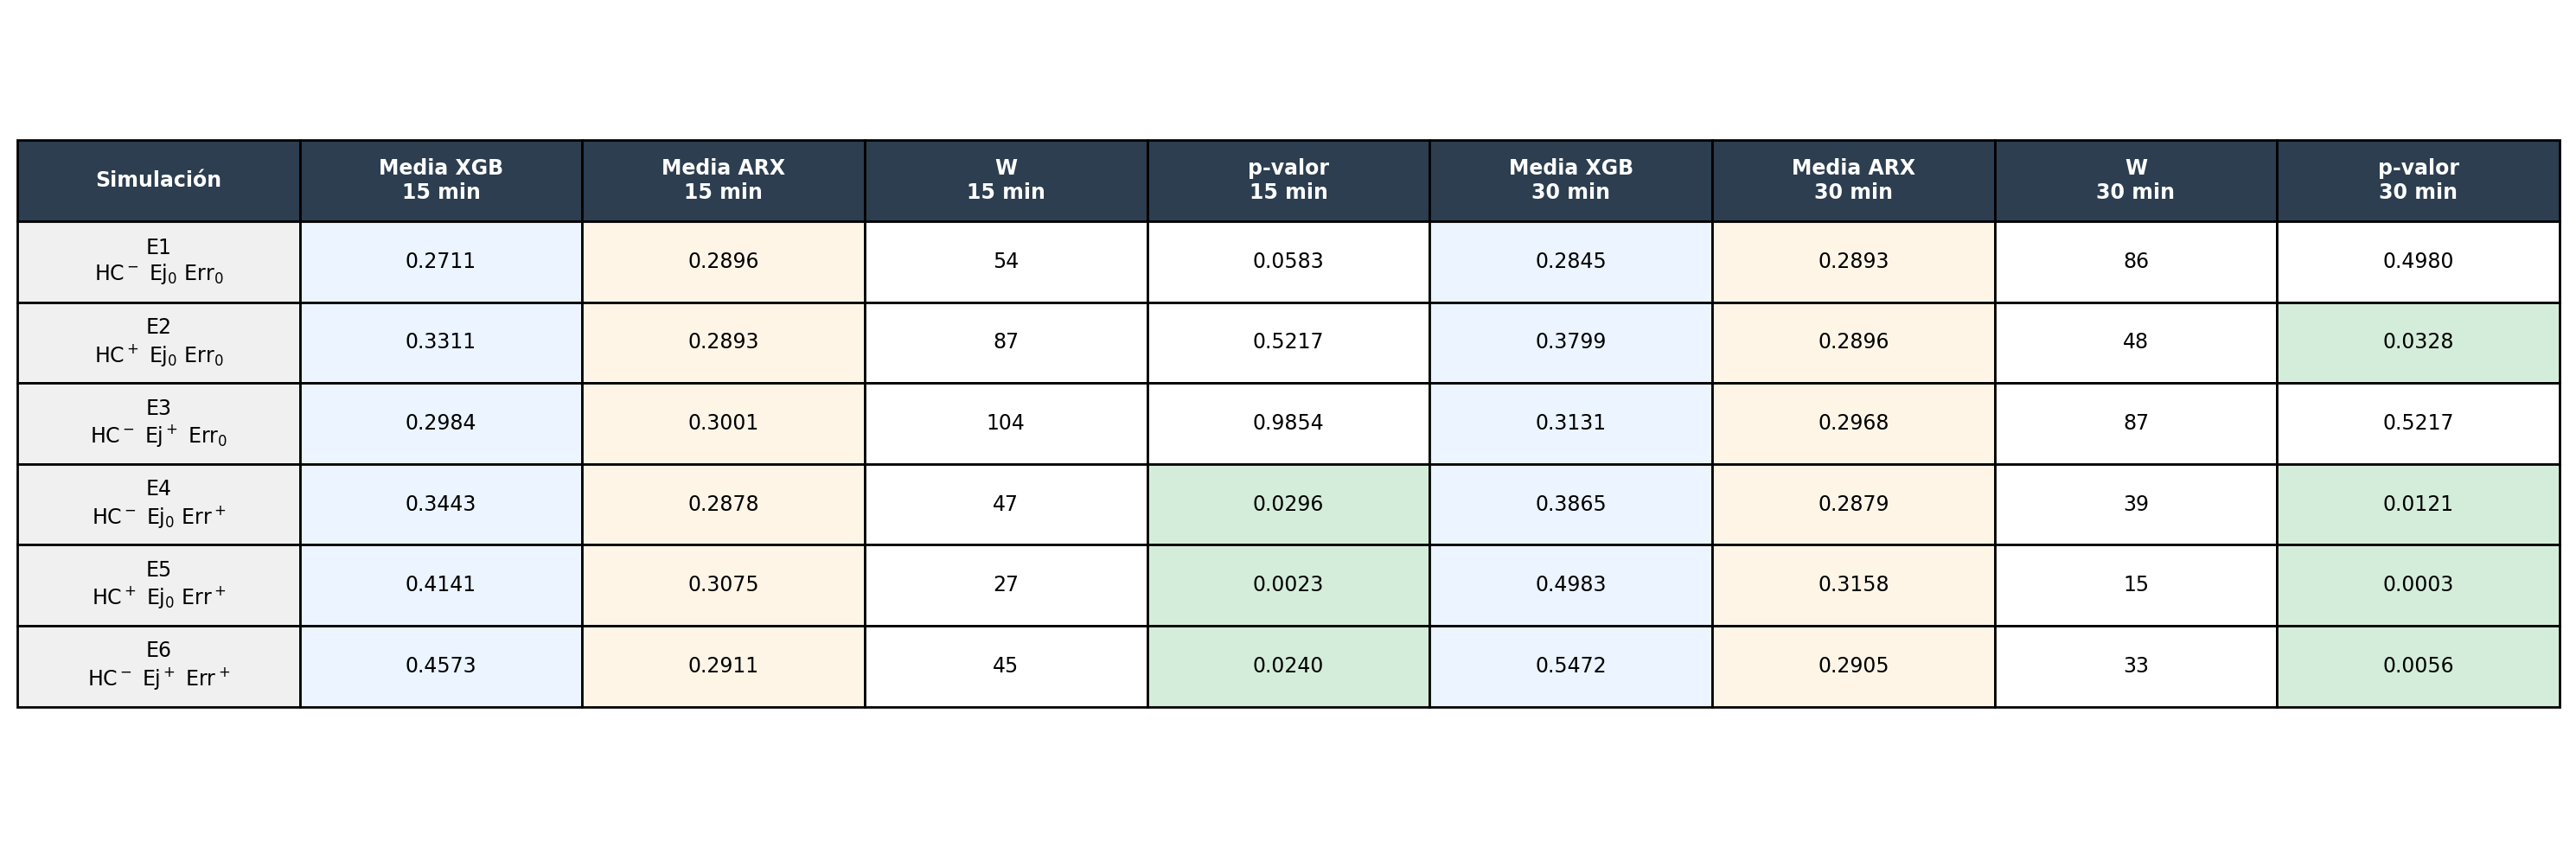

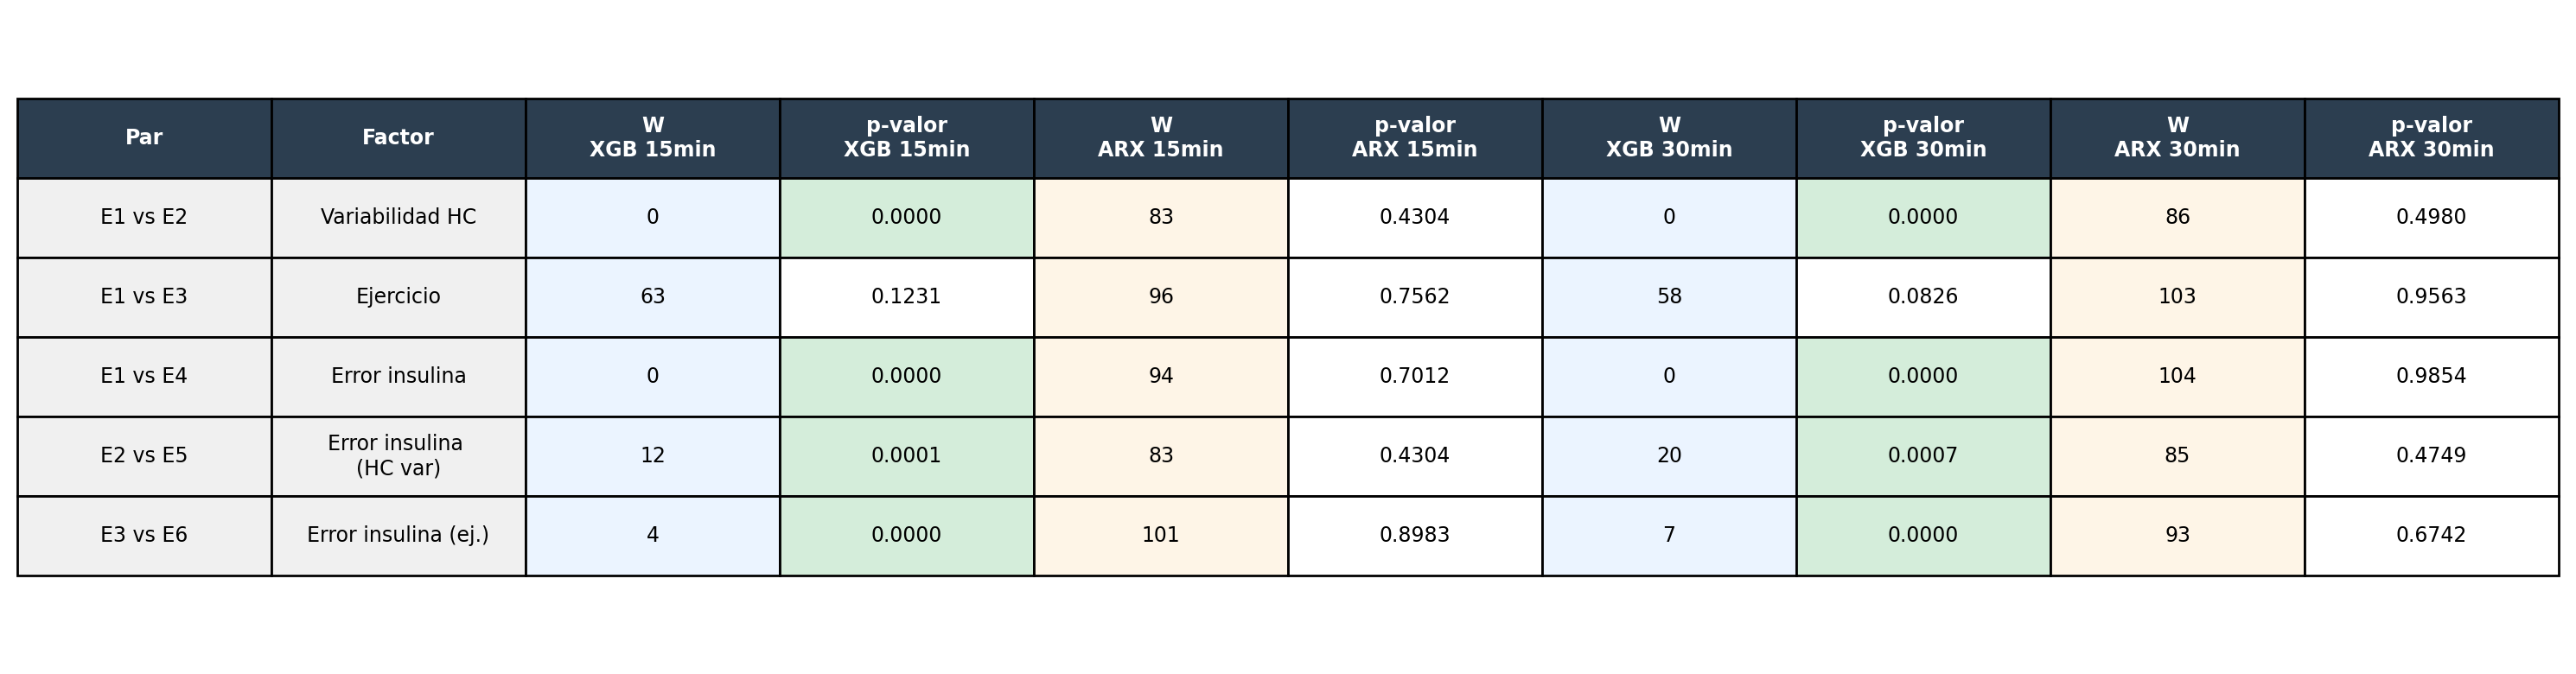

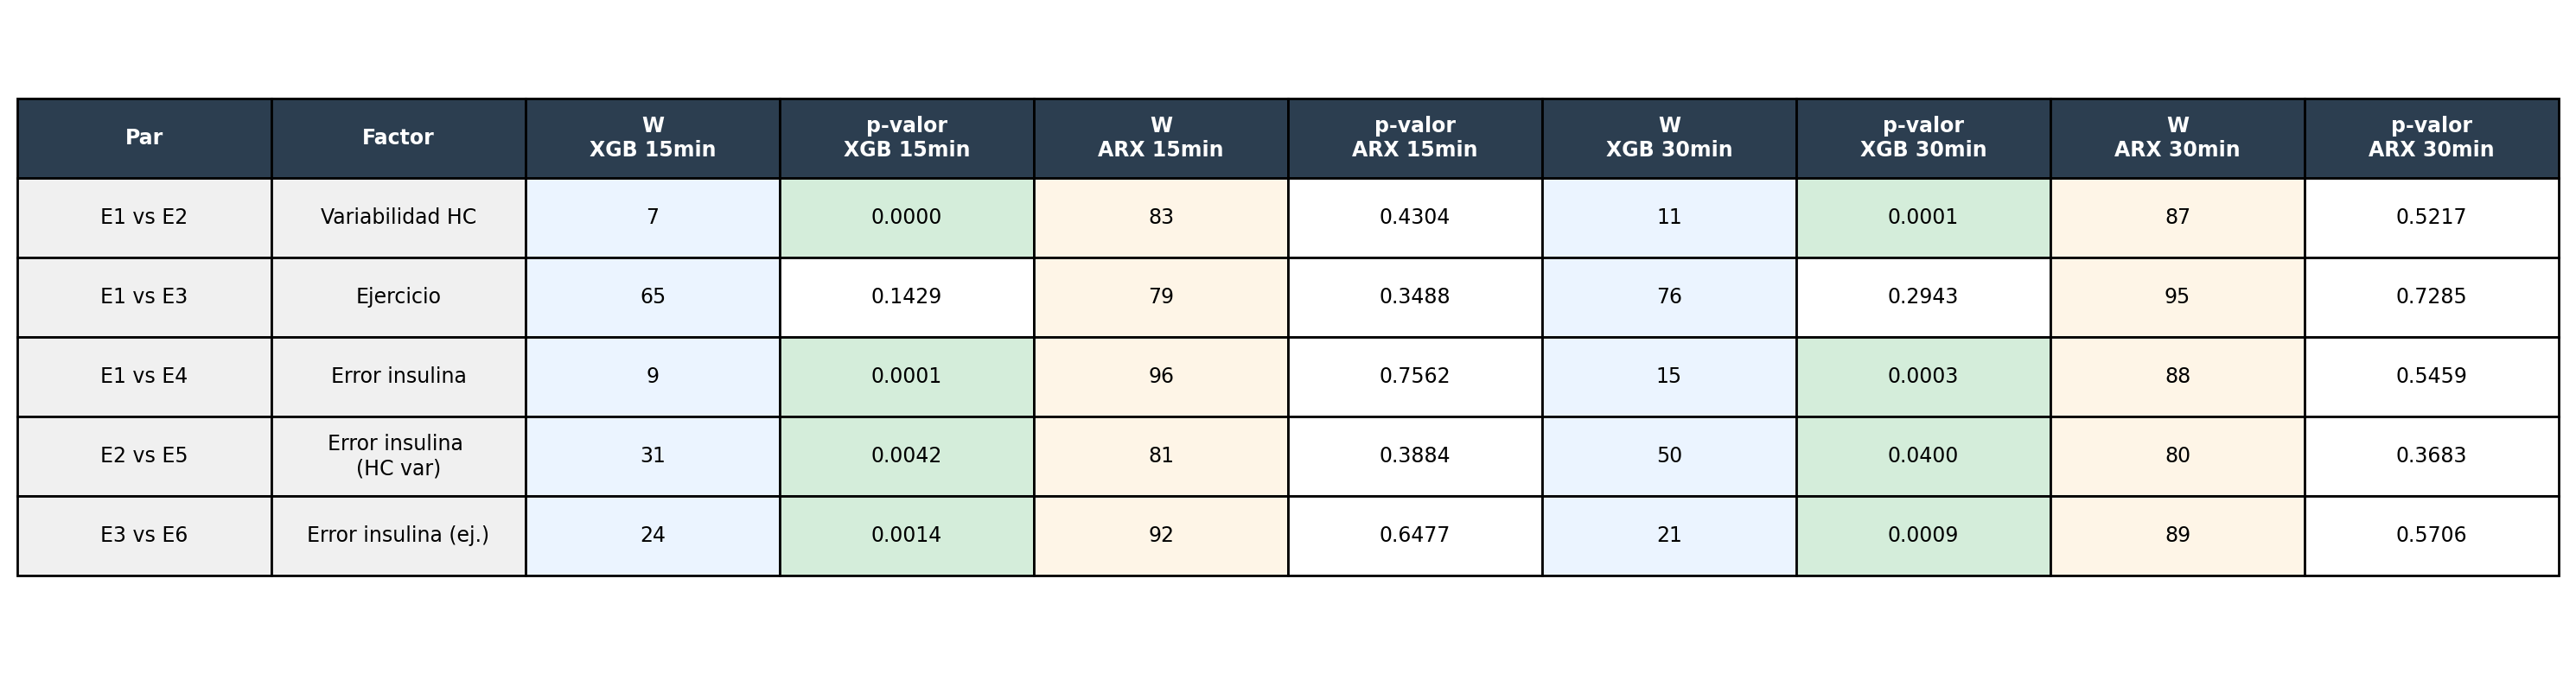

In [16]:
df_wA = calcular_wilcoxon_intermodelo(df)
tabla_wilcoxon_intermodelo(df_wA, metrica='MAE',  guardar=True)
tabla_wilcoxon_intermodelo(df_wA, metrica='RMSE', guardar=True)
df_wB = calcular_wilcoxon_intersimulacion(df)
tabla_wilcoxon_intersimulacion(df_wB, metrica='MAE',  guardar=True)
tabla_wilcoxon_intersimulacion(df_wB, metrica='RMSE', guardar=True)

In [38]:
display(df_wA)
display(df_wB)

,Métrica,horizonte_num,sim_num,W,p,significativo,XGB_media,ARX_media
0,MAE,15,1,0.0,0.0000,True,0.1205,0.2486
1,MAE,15,2,8.0,0.0000,True,0.1537,0.2496
2,MAE,15,3,0.0,0.0000,True,0.1270,0.2490
3,MAE,15,4,14.0,0.0002,True,0.1746,0.2484
4,MAE,15,5,32.0,0.0049,True,0.1952,0.2511
5,MAE,15,6,40.0,0.0136,True,0.1936,0.2491
6,MAE,30,1,0.0,0.0000,True,0.1261,0.2492
7,MAE,30,2,16.0,0.0003,True,0.1665,0.2504
8,MAE,30,3,0.0,0.0000,True,0.1329,0.2494
9,MAE,30,4,31.0,0.0042,True,0.1884,0.2489


,Métrica,horizonte_num,Par,Factor,Modelo,W,p,significativo,media_s1,media_s2,delta
0,MAE,15,E1 vs E2,Variabilidad HC,XGBoost,0.0,0.0000,True,0.1205,0.1537,0.0331
1,MAE,15,E1 vs E2,Variabilidad HC,ARIMAX,83.0,0.4304,False,0.2486,0.2496,0.0011
2,MAE,15,E1 vs E3,Ejercicio,XGBoost,63.0,0.1231,False,0.1205,0.1270,0.0065
3,MAE,15,E1 vs E3,Ejercicio,ARIMAX,96.0,0.7562,False,0.2486,0.2490,0.0004
4,MAE,15,E1 vs E4,Error insulina,XGBoost,0.0,0.0000,True,0.1205,0.1746,0.0540
5,MAE,15,E1 vs E4,Error insulina,ARIMAX,94.0,0.7012,False,0.2486,0.2484,-0.0002
6,MAE,15,E2 vs E5,Error insulina \n(HC var),XGBoost,12.0,0.0001,True,0.1537,0.1952,0.0415
7,MAE,15,E2 vs E5,Error insulina \n(HC var),ARIMAX,83.0,0.4304,False,0.2496,0.2511,0.0015
8,MAE,15,E3 vs E6,Error insulina (ej.),XGBoost,4.0,0.0000,True,0.1270,0.1936,0.0666
9,MAE,15,E3 vs E6,Error insulina (ej.),ARIMAX,101.0,0.8983,False,0.2490,0.2491,0.0000
